# 1. Fixed income and yield curve construction

In this project we will implement

- building yield curve from par yields for US and japan data with 4 different methods and comparison
- creating a rolling synthetic bond issuance
- analysis and pricing of a bond portfolio
- risk and sensitivity measures of bonds 
- hedging and targeting risk for a bond portfolio

## 1. Bonds, Coupons, Treasuries, and Par Yields

In this notebook, we use Treasury par yields as the raw market input, then build continuous discount and zero-rate curves from those observed maturities.

### 1.1 Fixed-coupon bond cashflows
A standard coupon bond is defined by:
- notional $N$ (principal. the money that you get back)
- annual coupon rate $c$ (the interest rate of the bond)
- maturity $T$ (the time that bond ends and you get back principal and interest)
- coupon frequency $f$ (the amount of payments per year)

A fixed-coupon bond promises a sequence of coupon payments and principal repayment. For a bond with notional $N$, annual coupon rate $c$, maturity $T$, and coupon frequency $f$, the coupon paid each period is

$$
\frac{c}{f}N.
$$

If the bond pays coupons at times

$$
t_i = \frac{i}{f}, \qquad i=1,2,\dots,n,
$$

where $n=fT$, then the cash flows are

$$
CF_i = \frac{c}{f}N, \qquad i=1,\dots,n-1,
$$

and the final cash flow includes principal:

$$
CF_n = \frac{c}{f}N + N.
$$

To price the bond today, every future cash flow must be discounted back to the valuation date. If $D(t)$ is the discount factor for maturity $t$, then the bond price is

$$
P = \sum_{i=1}^{n} CF_i D(t_i).
$$

A Treasury par yield is the coupon rate that makes a standard bond trade at par. If the notional is normalized to $N=1$, par means

$$
P = 1.
$$

Therefore, the observed par-yield curve is not itself a zero-rate curve or a discount-factor curve. It is a set of market coupon rates that needs to be transformed into discount factors before we can consistently price other bonds, compute present values, or measure interest-rate risk.

**you can download the data used in this notebook here [(treasury par yields from 1990 to 2026)][]**

[(treasury par yields from 1990 to 2026)]: https://home.treasury.gov/resource-center/data-chart-center/interest-rates/daily-treasury-rate-archives

---

### 1.2 Year fraction from dates
Given dates $d_0$ and $d_1$, a day-count year fraction is

$$\tau(d_0,d_1)=\dfrac{\text{days}(d_0,d_1)}{365}$$

---

### 1.3 Tenor mapping
Tenor labels map to maturities:
- $k$ M → $T=k/12$
- $k$ Y → $T=k$

Collect maturities into a numeric vector:
$\mathbf{T}=(T_1,T_2,\dots,T_m)$  
Observed market par yields:
$\mathbf{y}=(y_1,y_2,\dots,y_m)$ with $y_j=y(T_j)$

---

## Imports and plotting style and loading data


In [1]:
import math
import warnings
import copy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cycler import cycler

warnings.filterwarnings("ignore")


colors = ["#069AF3","#FE420F", "#00008B", "#008080" , "#CC79A7",
          "#9614fa", "#DC143C", "#7BC8F6", "#0072B2","#04D8B2", "#800080", "#FF8072"]
plt.rcParams["axes.prop_cycle"] = cycler(color=colors)
plt.rcParams.update({
    "figure.figsize": (6, 3),
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.grid": True,
    "grid.alpha": 0.20,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 7})


df = pd.read_csv(r"..\data\par-yield-curve-rates-1990-2026.csv")

col_map = {"date": "Date","1 mo": "1M","2 mo": "2M","3 mo": "3M","4 mo": "4M","6 mo": "6M","1 yr": "1Y","2 yr": "2Y","3 yr": "3Y","5 yr": "5Y","7 yr": "7Y","10 yr": "10Y","20 yr": "20Y","30 yr": "30Y"}

df = df.rename(columns={k.lower(): v for k, v in col_map.items()})
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date"], ).set_index("Date").sort_index()

df

,1M,2M,3M,4M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
Date,,,,,,,,,,,,,
1990-01-02,NaN,NaN,7.83,NaN,7.89,7.81,7.87,7.90,7.87,7.98,7.94,NaN,8.00
1990-01-03,NaN,NaN,7.89,NaN,7.94,7.85,7.94,7.96,7.92,8.04,7.99,NaN,8.04
1990-01-04,NaN,NaN,7.84,NaN,7.90,7.82,7.92,7.93,7.91,8.02,7.98,NaN,8.04
1990-01-05,NaN,NaN,7.79,NaN,7.85,7.79,7.90,7.94,7.92,8.03,7.99,NaN,8.06
1990-01-08,NaN,NaN,7.79,NaN,7.88,7.81,7.90,7.95,7.92,8.05,8.02,NaN,8.09
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-22,3.79,3.72,3.71,3.67,3.61,3.53,3.61,3.68,3.85,4.05,4.26,4.79,4.84
2026-01-23,3.78,3.72,3.70,3.67,3.61,3.53,3.60,3.67,3.84,4.03,4.24,4.78,4.82
2026-01-26,3.77,3.70,3.67,3.67,3.62,3.52,3.56,3.66,3.82,4.02,4.22,4.75,4.80



Data shape: (9024, 13)
Date range: 1990-01-02 to 2026-01-28


,count,mean,std,min,25%,50%,75%,max
1M,6124.0,1.669061,1.834318,0.00,0.08,0.98,2.700,6.02
2M,1819.0,2.731045,2.092637,0.00,0.14,2.43,4.635,5.61
3M,9020.0,2.793844,2.279473,0.00,0.23,2.74,5.010,8.26
4M,817.0,4.826524,0.600693,3.58,4.35,4.77,5.440,5.64
6M,9023.0,2.908257,2.296244,0.02,0.41,3.00,5.100,8.49
1Y,9023.0,3.004545,2.274365,0.04,0.56,3.12,5.025,8.64
2Y,9023.0,3.243374,2.267325,0.09,0.94,3.35,4.990,9.05
3Y,9023.0,3.422187,2.212582,0.10,1.37,3.55,5.050,9.11
5Y,9023.0,3.761102,2.107014,0.19,1.81,3.73,5.380,9.10
7Y,9023.0,4.037397,2.028457,0.36,2.22,3.93,5.600,9.12


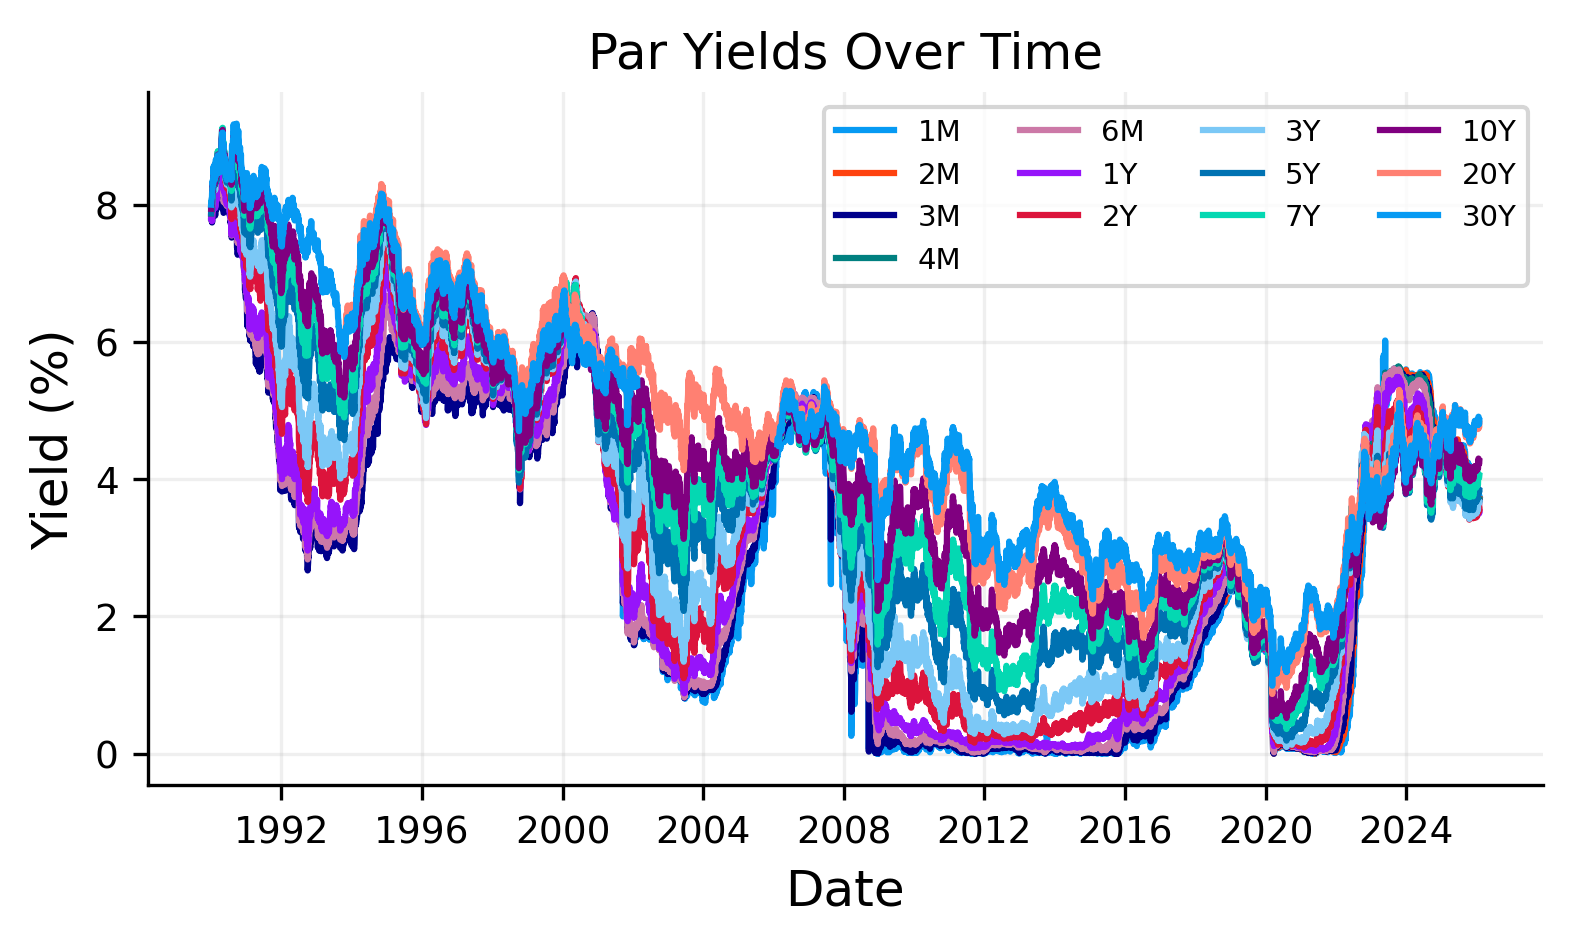

First available date per tenor:


,tenor,first_valid_date
2,3M,1990-01-02
4,6M,1990-01-02
5,1Y,1990-01-02
6,2Y,1990-01-02
7,3Y,1990-01-02
8,5Y,1990-01-02
9,7Y,1990-01-02
10,10Y,1990-01-02
12,30Y,1990-01-02
11,20Y,1993-10-01


In [2]:
tenor_cols = ["1M","2M","3M","4M","6M","1Y","2Y","3Y","5Y","7Y","10Y","20Y","30Y"]
for c in tenor_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

first_valid = df[tenor_cols].apply(lambda s: s.first_valid_index())
availability = pd.DataFrame({
    "tenor": tenor_cols,
    "first_valid_date": [first_valid[t] for t in tenor_cols],
})
availability["first_valid_date"] = pd.to_datetime(availability["first_valid_date"])
availability = availability.sort_values("first_valid_date")



print("\nData shape:", df.shape)
print("Date range:", df.index.min().date(), "to", df.index.max().date())
display(df[tenor_cols].describe().T)


plt.figure()
for c in df.columns:
    plt.plot(df.index, df[c], label=c)
plt.title("Par Yields Over Time")
plt.ylabel("Yield (%)")
plt.xlabel("Date")
plt.legend(ncol= 4)
plt.show()


print("First available date per tenor:")
display(availability)


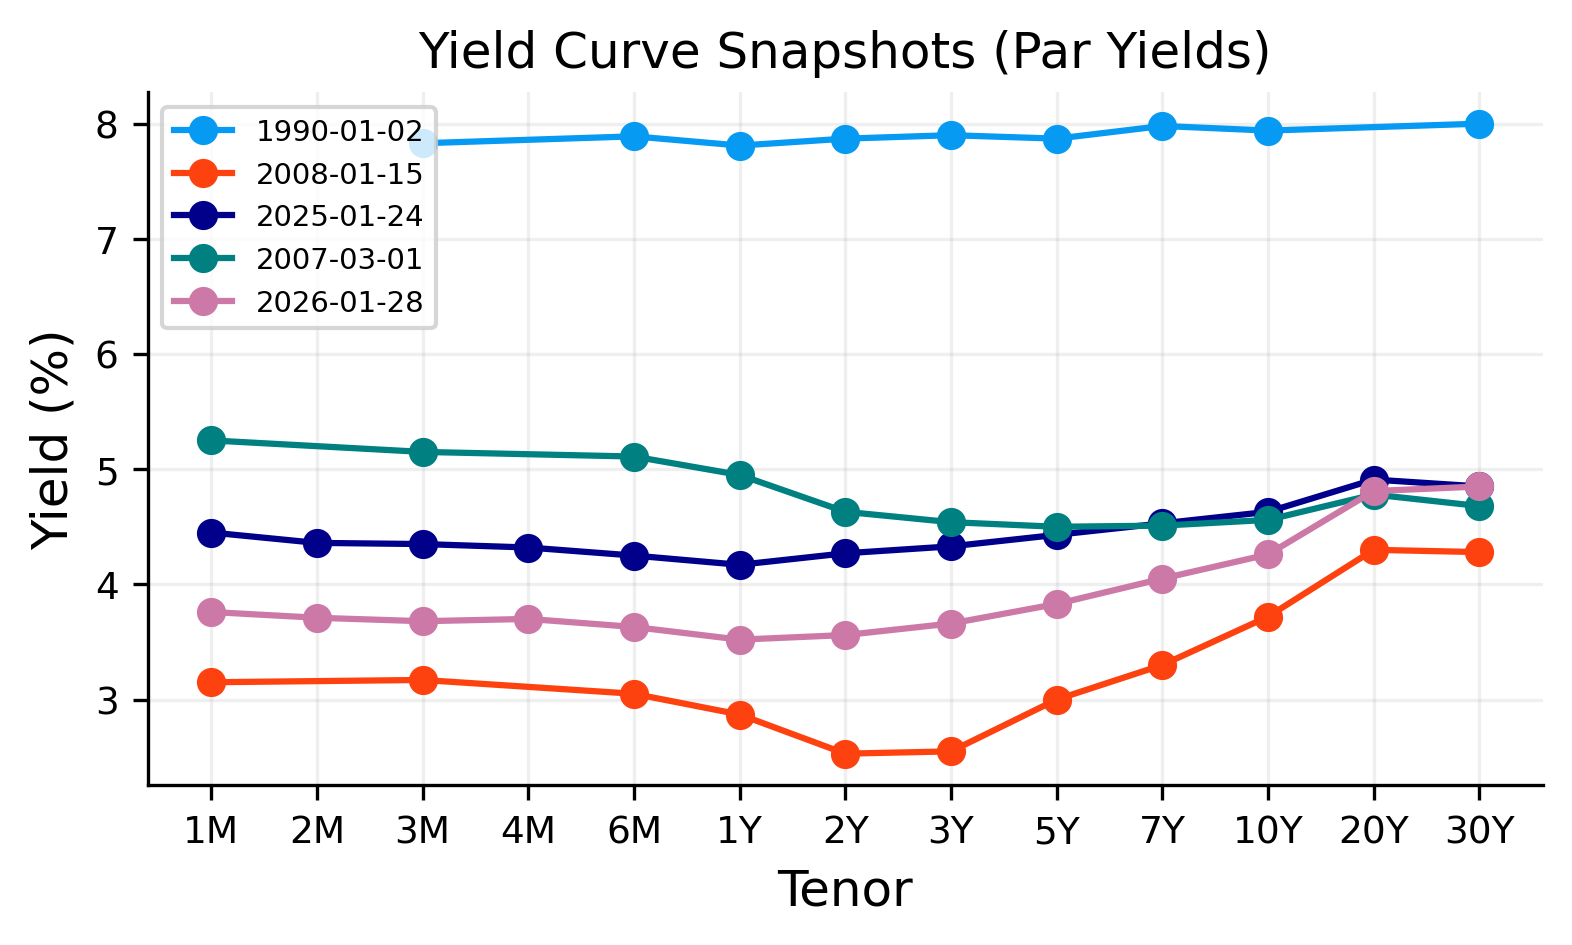

In [3]:
sample_dates = [
    df.index[0],
    df.index[len(df)//2],
    df.index[-252],
    df.index[df.index <= pd.Timestamp("2007-03-01")][-1],
    df.index[-1]
]

x = np.arange(len(tenor_cols))  

plt.figure()
for d in sample_dates:
    y = df.loc[d, tenor_cols].astype(float)
    mask = np.isfinite(y.values)
    plt.plot(x[mask], y.values[mask], marker="o", label=d.strftime("%Y-%m-%d"))

plt.title("Yield Curve Snapshots (Par Yields)")
plt.xticks(x, tenor_cols)
plt.ylabel("Yield (%)")
plt.xlabel("Tenor")
plt.legend()
plt.show()



The plot shows that the Treasury curve is not stable through time. Some dates have a fairly normal upward-sloping curve, while others show flatter or inverted shapes. This is exactly why the curve-building method matters.

A simple interpolation method may work well when the curve is smooth and monotone, but it can behave differently when the curve is inverted, when the short end moves sharply, or when the long end has limited curvature.

## 2. Discount Factors, Zero Rates, and Forward Rates

### 2.1) Discount factor
$D(t)$ is the present value of receiving 1 unit of currency at time $t$. For example what does 1 dollar in 20 years worth now.

### 2.2) Zero rate (continuous compounding)

$z(t)$ is the constant rate that discounts a payment in $t$ to present. for example, if we want to know discount factor of 1 dollar in 20 years we need an annual rate to compute the present value. that's zero rate.

Define $z(t)$ by
$$
D(t)=e^{-z(t)t}
$$

So:

$$
z(t)=-\dfrac{\ln D(t)}{t}
$$

### 3.3) Instantaneous forward rate
$f(t)$ is the slope of $z(t)$ which tells us how much the rate of return is very close to the time of maturity. it is used because zero rate is smooth and in instant time we need to have exact forward rate

$$
f(t)=-\dfrac{d}{dt}\ln D(t)
$$

Discount factor can also be calculated from forwadr curve:

$$
D(t)=\exp\left(-\int_0^t f(u)\,du\right)
$$

### 3.4) Discrete forward over an interval
For $t_1<t_2$, the continuously-compounded forward rate for the interval can be written in discrete form:
$$
F(t_1,t_2)=\dfrac{\ln D(t_1)-\ln D(t_2)}{t_2-t_1}
$$


---

## 3) Par Yield Implied by a Curve

This is used for building yield curve and validation to see if the predicted rate is close to real rate based on curve. We want to know what is the rate that makes the price of bond (PV of cashflows) equal to 1?

Given a curve $D(t)$, the par coupon rate for maturity $T$ and frequency $f$ solves

$$1= P = \sum_{i=1}^{n}\dfrac{c}{f}D(t_i)+D(T) \qquad t_i=i/f, \qquad n=fT$$


$$1=\dfrac{c}{f}\sum_{i=1}^{n}D(t_i)+D(T)$$


and finally we get to

$$c=f\,\dfrac{1-D(T)}{\sum_{i=1}^{n}D(t_i)}$$



Short maturities (<1Y) often use money-market conventions because they are mostly single payment. Two common ones:
- continuous: $y=-\dfrac{\ln D(T)}{T}$
- simple: $y=\dfrac{1/D(T)-1}{T}$

---

## 4) Bootstrapping Discount Factors from Par Yields

Bootstrapping constructs $D(T)$ at market tenors from observed par yields. in this way we can have a function of time to discount a payment in any maturity based on the real yields that we have.

### 4.1 Short end (<1Y) convention
For $T<1$ we use the money market convention again. for calculating discount factor:

- continuous convention: $D(T)=e^{-y(T)T}$
- simple convention: $D(T)=\dfrac{1}{1+y(T)T}$

### 4.2 Bootstrapping for coupon tenors (T ≥ 1)
If $c=y(T)$ is the market par yield at maturity $T$ (used as coupon rate).
With frequency $f$ and cashflow times $t_i=i/f$:

Par condition (normalized notional 1):
$$
1=\sum_{i=1}^{n-1}\dfrac{c}{f}D(t_i)+\left(1+\dfrac{c}{f}\right)D(T)
$$

Solve for the new unknown $D(T)$:
$$D(T)=\dfrac{1-\sum_{i=1}^{n-1}\dfrac{c}{f}D(t_i)}{1+\dfrac{c}{f}}
$$

if we have the earlier coupons discount factor, we know everything on the right side of equation. so we can solve it and get to $D(T)$

it's called bootstrapping because we first compute the $D(T<1Y)$ with short end convention, then we use that to compute $D(1Y)$ and then use them for $D(2Y)$ until the last maturity (30Y)


## 5) Turning Bootstrapped Pillars into a Full Curve

After bootstrapping we have pillars $(T_j, D(T_j))$ or $(T_j, z(T_j))$.
Bootstrapping needs $D(t_i)$ at coupon dates, but you often only have DFs at pillar maturities.

Now we want to define continuous functions $D(t)$ and $z(t)$ for all $t$.

### 5.1 Method A: Log-linear discount factors

A robust choice is log-linear interpolation:
for any $t$ that is between pillars $T_a<t<T_b$, we have

$$
\ln D(t)=\ln D(T_a)+\frac{t-T_a}{T_b-T_a}\left[\ln D(T_b)-\ln D(T_a)\right].
$$


So Discount Factor is:
$$D(t)=\exp\left(\ln D(t)\right)
$$

and zero rate is:
$$z(t)=-\dfrac{\ln D(t)}{t}$$



Base date: 2026-01-28
Tenors used: ['1M', '2M', '3M', '4M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']
First 5 pillar DFs: [0.99687157 0.99383574 0.99084219 0.98774241 0.98201372 0.96571989
 0.93185753 0.89680276 0.82670445 0.75353422 0.65216175 0.37090153
 0.22566195]


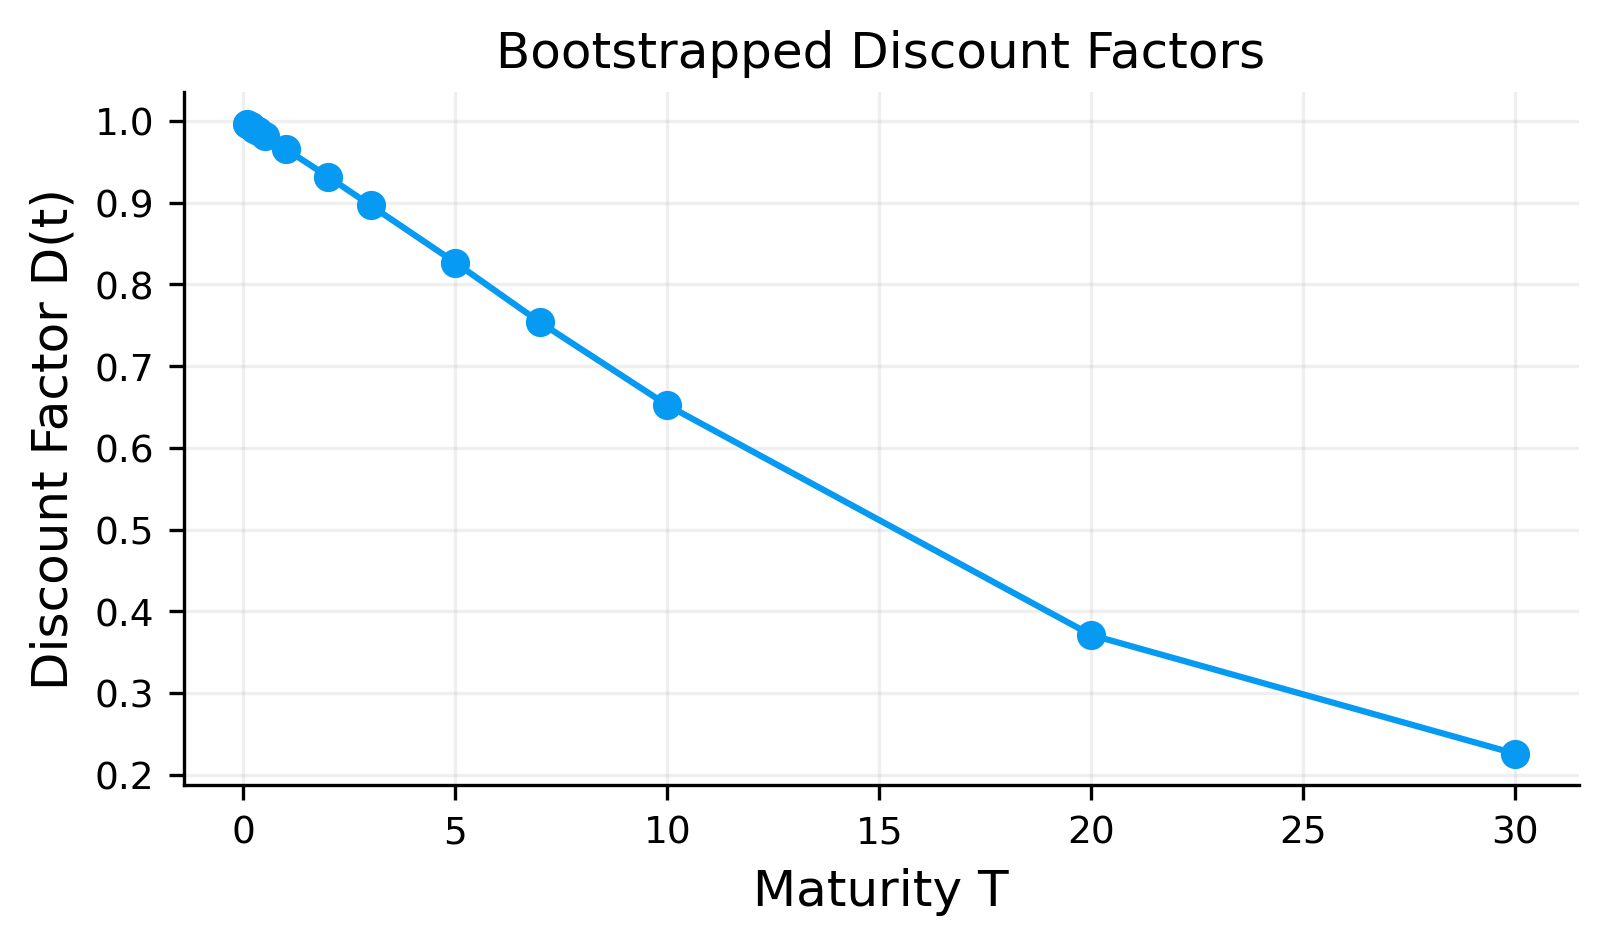

In [4]:
df_dec = df.copy()
df_dec[tenor_cols] = df_dec[tenor_cols] / 100.0

short_end_convention = "continuous"
f = 2
min_d = 1e-12


def labels_to_T(labels):
    T = []
    for lab in labels:
        labu = lab.upper().strip()
        if labu.endswith("M"):
            T.append(int(labu[:-1]) / 12.0)
        else:
            T.append(float(int(labu[:-1])))
    return np.array(T, dtype=float)


def get_par_from_row(row):
    y = row[tenor_cols].astype(float)
    mask = np.isfinite(y.values)
    labels = [tenor_cols[i] for i in range(len(tenor_cols)) if mask[i]]
    if len(labels) == 0:
        return None

    par = y.values[mask].astype(float)
    T = labels_to_T(labels)

    i = np.argsort(T)
    T = T[i]
    par = par[i]
    labels = [labels[i] for i in i]

    return T, par, labels


def get_par_for_date(date):
    row = df_dec.loc[date]
    return get_par_from_row(row)


def short_end_df(Ti, ri):
    if short_end_convention == "continuous":
        return math.exp(-ri * Ti)
    return 1.0 / (1.0 + ri * Ti)


def price_error_loglinear(d_T, Ti, t_prev, d_prev, times_interp, c, pv_known):
    d_T = max(float(d_T), min_d)
    pv_interp = 0.0
    if len(times_interp) > 0:
        w = (times_interp - t_prev) / (Ti - t_prev)
        log_d = (1 - w) * np.log(d_prev) + w * np.log(d_T)
        d_interp = np.exp(log_d)
        pv_interp = np.sum((c / f) * d_interp)
    return pv_known + pv_interp + d_T - 1.0


def solve_df_long_end(Ti, ri, d_map):
    c = float(ri)
    n = int(round(Ti * f))
    times = np.array([k / f for k in range(1, n + 1)], dtype=float)


    known_T = np.array(sorted(d_map.keys()), dtype=float)
    known_D = np.array([d_map[t] for t in known_T], dtype=float)
    known_D = np.clip(known_D, min_d, None)


    t_prev = known_T[-1]
    d_prev = known_D[-1]

    times_known = times[times <= t_prev + 1e-12]
    times_interp = times[times > t_prev + 1e-12]

    pv_known = 0.0
    if len(times_known) > 0:
        log_known_D = np.log(known_D)
        log_df_known = np.interp(times_known, known_T, log_known_D)
        d_known = np.exp(log_df_known)
        pv_known = np.sum((c / f) * d_known)

    lo = min_d
    hi = d_prev
    f_lo = price_error_loglinear(lo, Ti, t_prev, d_prev, times_interp, c, pv_known)
    f_hi = price_error_loglinear(hi, Ti, t_prev, d_prev, times_interp, c, pv_known)

    if f_lo * f_hi > 0:
    
        log_known_D = np.log(known_D)
        log_df_cpn = np.interp(
            times[:-1],
            known_T,
            log_known_D,
            left=log_known_D[0],
            right=log_known_D[-1],
        )
        d_cpn = np.exp(log_df_cpn)
        pv_coupons = np.sum((c / f) * d_cpn)
        d_T = (1.0 - pv_coupons) / (1.0 + c / f)
    else:
        for _ in range(100):
            mid = 0.5 * (lo + hi)
            f_mid = price_error_loglinear(mid, Ti, t_prev, d_prev, times_interp, c, pv_known)
            if f_lo * f_mid <= 0:
                hi = mid
                f_hi = f_mid
            else:
                lo = mid
                f_lo = f_mid
            if abs(hi - lo) < 1e-12:
                break
        d_T = 0.5 * (lo + hi)

    return d_T


def bootstrap_from_inputs(T, par, labels, date=None):
    d_map = {}

    for Ti, ri in zip(T, par, strict=True):
        if Ti < 1.0:
            d_T = short_end_df(Ti, ri)
            d_map[Ti] = max(float(d_T), min_d)
            continue

        d_T = solve_df_long_end(Ti, ri, d_map)
        if (not np.isfinite(d_T)) or (d_T <= 0):
            d_T = min_d
        d_map[Ti] = max(float(d_T), min_d)

    dfs = np.array([d_map[t] for t in T], dtype=float)

    return {
        "date": date,
        "T": T,
        "par": par,
        "labels": labels,
        "dfs": dfs,
    }


def bootstrap_pillars(date):
    result = get_par_for_date(date)
    if result is None:
        return None

    T, par, labels = result
    return bootstrap_from_inputs(T, par, labels, date=date)


# we bootstrap discount factors at the last available date for now
base_date = df_dec.index[-1]
pillars = bootstrap_pillars(base_date)

T = pillars["T"]
par = pillars["par"]
labels = pillars["labels"]
dfs = pillars["dfs"]

print("Base date:", base_date.date())
print("Tenors used:", labels)
print("First 5 pillar DFs:", dfs)

plt.figure()
plt.plot(T, dfs, marker="o")
plt.title("Bootstrapped Discount Factors")
plt.xlabel("Maturity T")
plt.ylabel("Discount Factor D(t)")
plt.show()


For the last available date, **2026-01-28**, the bootstrapped pillar discount factors decrease from approximately **0.9969 at 1M** to approximately **0.2257 at 30Y**.

This makes ense in time value of money. receiving one dollar farther in the future is worth less today. The very low 30Y discount factor reflects the cumulative effect of discounting over a long horizon. Even if the annual rate is only a few percent, compounding over 30 years produces a large present-value reduction.

We have transformed market coupon rates into a pricing object: a discount curve.

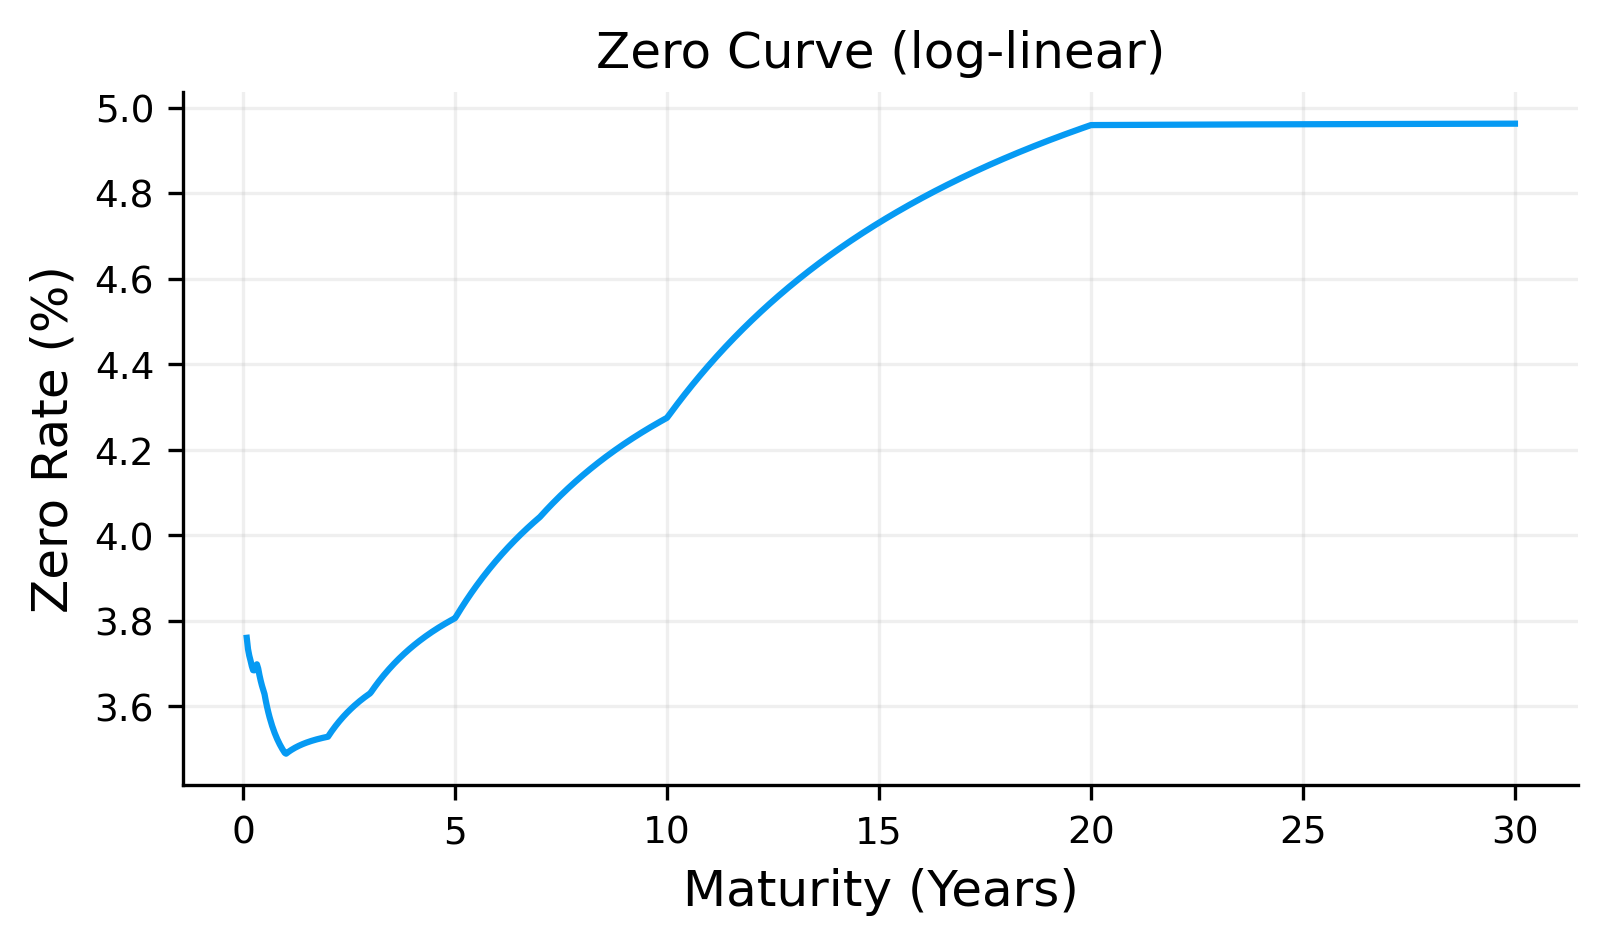

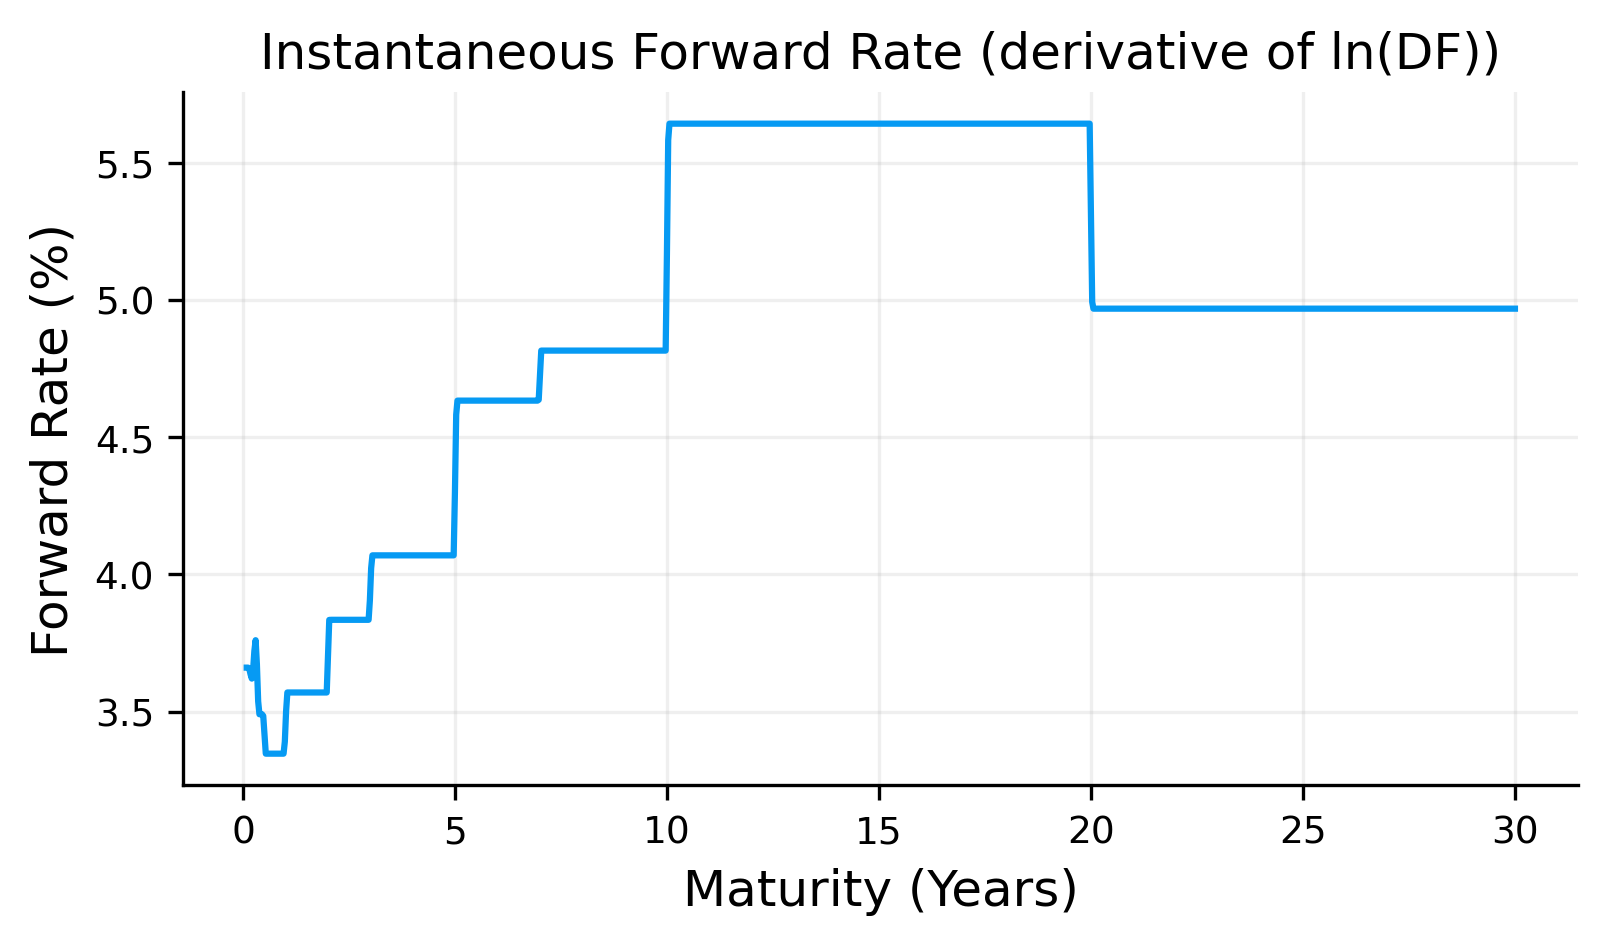

In [5]:
def loglinear_curve(T, dfs):
    loglinear_log_dfs = np.log(dfs)

    loglinear_grid = np.linspace(max(1 / 12, T.min()), 30.0, 1000)
    loglinear_log_df_grid = np.interp( loglinear_grid, T, loglinear_log_dfs,
                                     left=loglinear_log_dfs[0],
                                     right=loglinear_log_dfs[-1])
    
    loglinear_df_grid = np.exp(loglinear_log_df_grid)
    loglinear_z_grid = -np.log(loglinear_df_grid) / loglinear_grid
    loglinear_fwd_grid = -np.gradient(np.log(loglinear_df_grid), loglinear_grid)

    def loglinear_df_func(t):
        t = np.array(t, dtype=float)
        log_df = np.interp(t, T, loglinear_log_dfs,
                           left=loglinear_log_dfs[0],right=loglinear_log_dfs[-1])
        return np.exp(log_df)

    return {
        "name": "Log-linear DF",
        "grid": loglinear_grid,
        "df_grid": loglinear_df_grid,
        "z_grid": loglinear_z_grid,
        "fwd_grid": loglinear_fwd_grid,
        "df_func": loglinear_df_func,
        "log_dfs": loglinear_log_dfs}


loglinear_curve_data = loglinear_curve(T, dfs)
loglinear_grid = loglinear_curve_data["grid"]
loglinear_df_grid = loglinear_curve_data["df_grid"]
loglinear_z_grid = loglinear_curve_data["z_grid"]
loglinear_fwd_grid = loglinear_curve_data["fwd_grid"]

if "curves" not in globals():
    curves = {}
curves["loglinear"] = loglinear_curve_data


plt.figure()
plt.plot(loglinear_grid, loglinear_z_grid * 100.0)
plt.title("Zero Curve (log-linear)")
plt.xlabel("Maturity (Years)")
plt.ylabel("Zero Rate (%)")
plt.show()

plt.figure()
plt.plot(loglinear_grid, loglinear_fwd_grid * 100.0)
plt.title("Instantaneous Forward Rate (derivative of ln(DF))")
plt.xlabel("Maturity (Years)")
plt.ylabel("Forward Rate (%)")
plt.show()


The log-linear zero curve is smooth enough for pricing and remains stable because it is built directly from positive discount factors. The corresponding forward curve is more segmented because the method interpolates $\ln D(t)$ linearly between market pillars. This produces piecewise behavior in the implied instantaneous forward rate.

This is expected, log-linear discount curve is designed in the basic sense that discount factors remain positive. It is not designed to produce the smoothest possible forward curve. but it is one of the simplest methods and can actually perform with high out of sample accuracy.

If a more complex model cannot outperform the log-linear curve in out-of-sample checks, then the extra complexity may not be justified.

## 7) Curve Models Using Zero-Rate Smoothing

Instead of interpolating $D$, we can interpolate $z$ and recover $D(t)=e^{-z(t)t}$.

### 7.1 PCHIP on zero rates (Piecewise Cubic Hermite Interpolating Polynomial)
Given nodes $x_j=T_j$ and $y_j=z(T_j)$, PCHIP builds a piecewise cubic polynomial on each interval:

$$
p_j(t)=a_j(t-x_j)^3+b_j(t-x_j)^2+c_j(t-x_j)+d_j  \quad t\in[x_j,x_{j+1}]
$$

Constraints include:
- $p_j(x_j)=y_j$ and $p_j(x_{j+1})=y_{j+1}$
- first derivatives are chosen by shape-preserving slope rules to reduce overshoot

we define
$$z(t)=p_j(t)$$

then
$$D(t)=e^{-z(t)t}$$

PCHIP is designed to reduce overshooting. This is useful for yield curves because unrealistic oscillations can create strange discount factors or forward rates.

Compared with log-linear discount interpolation, PCHIP usually produces a smoother zero curve. The tradeoff is that the curve no longer has the same simple piecewise-forward interpretation and may not exactly reproduce all par-yield relationships after transformation back into coupon-bond pricing.


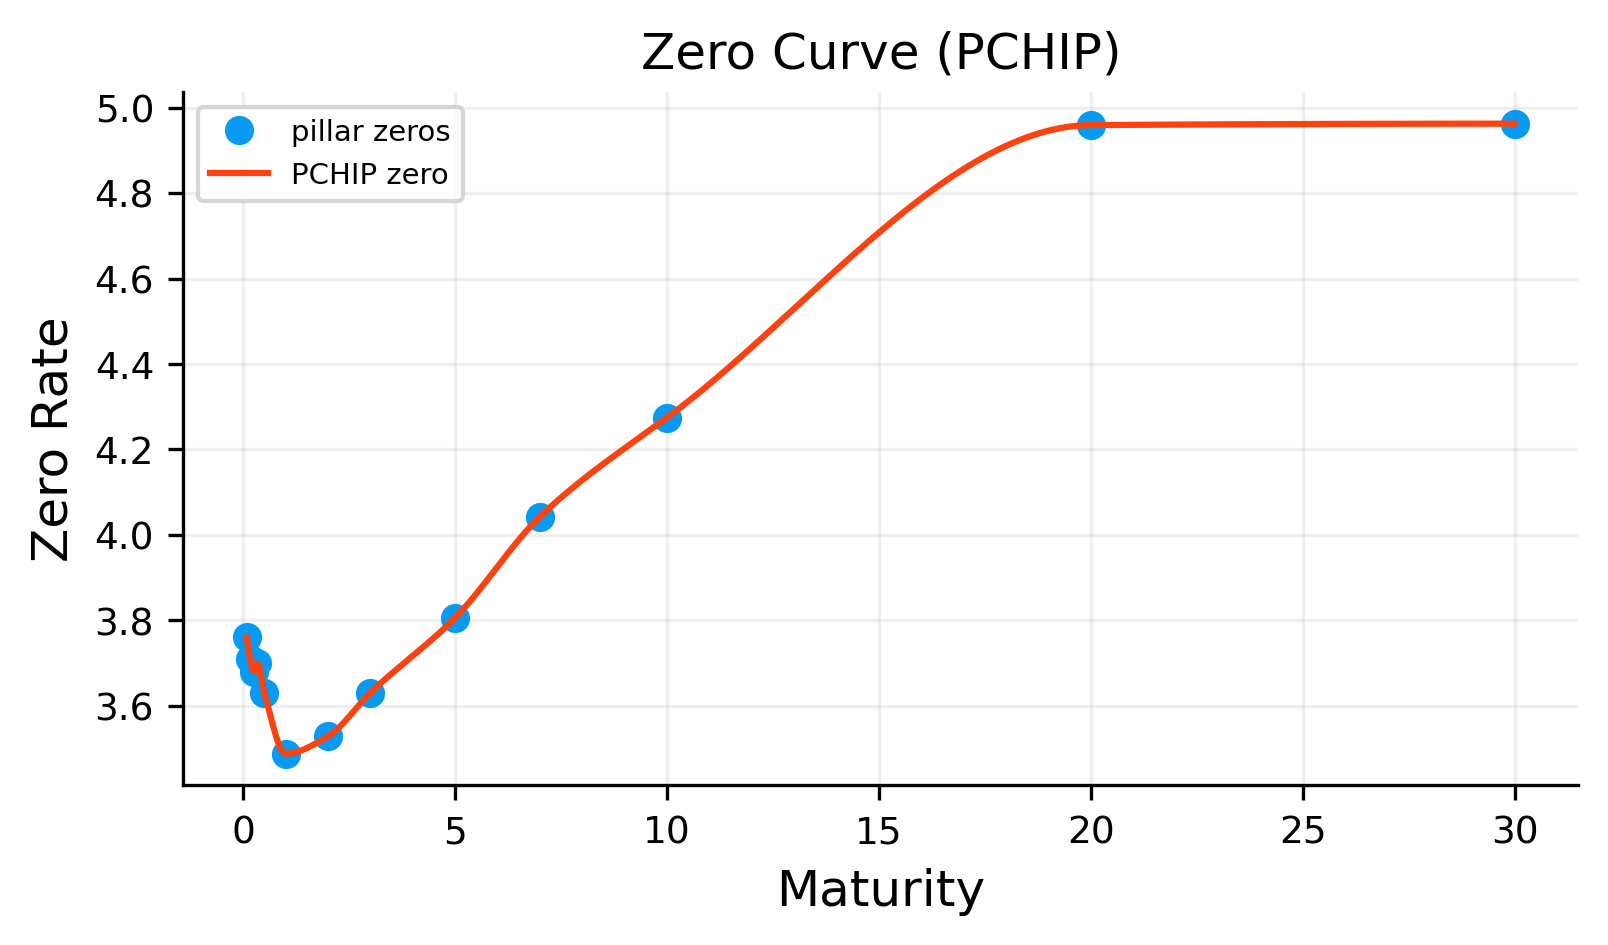

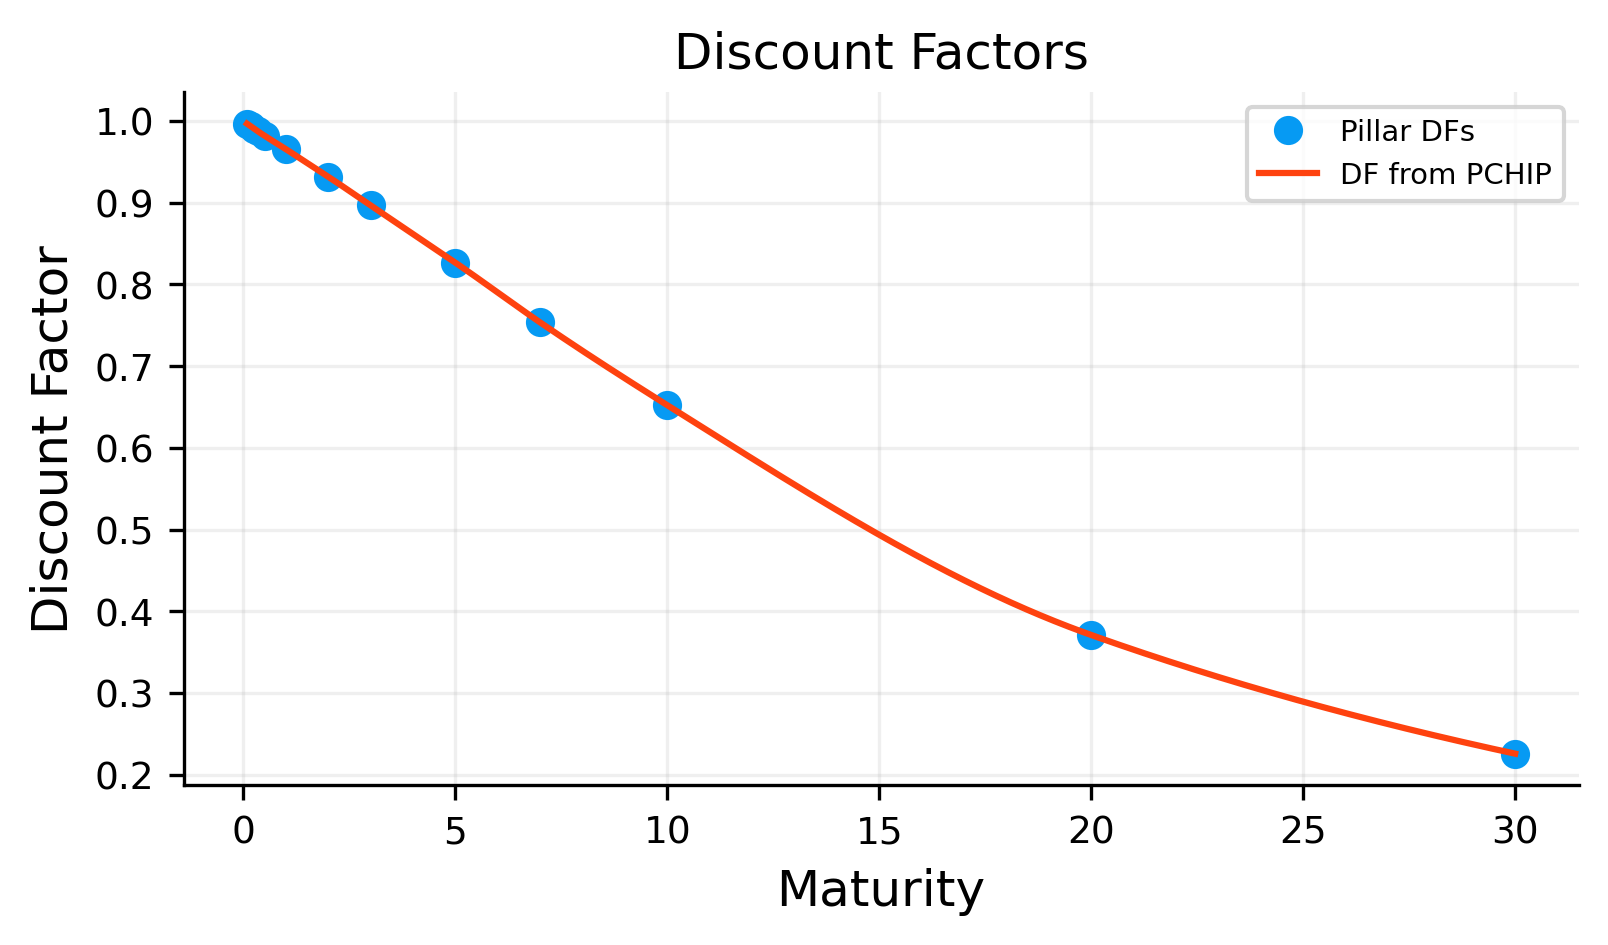

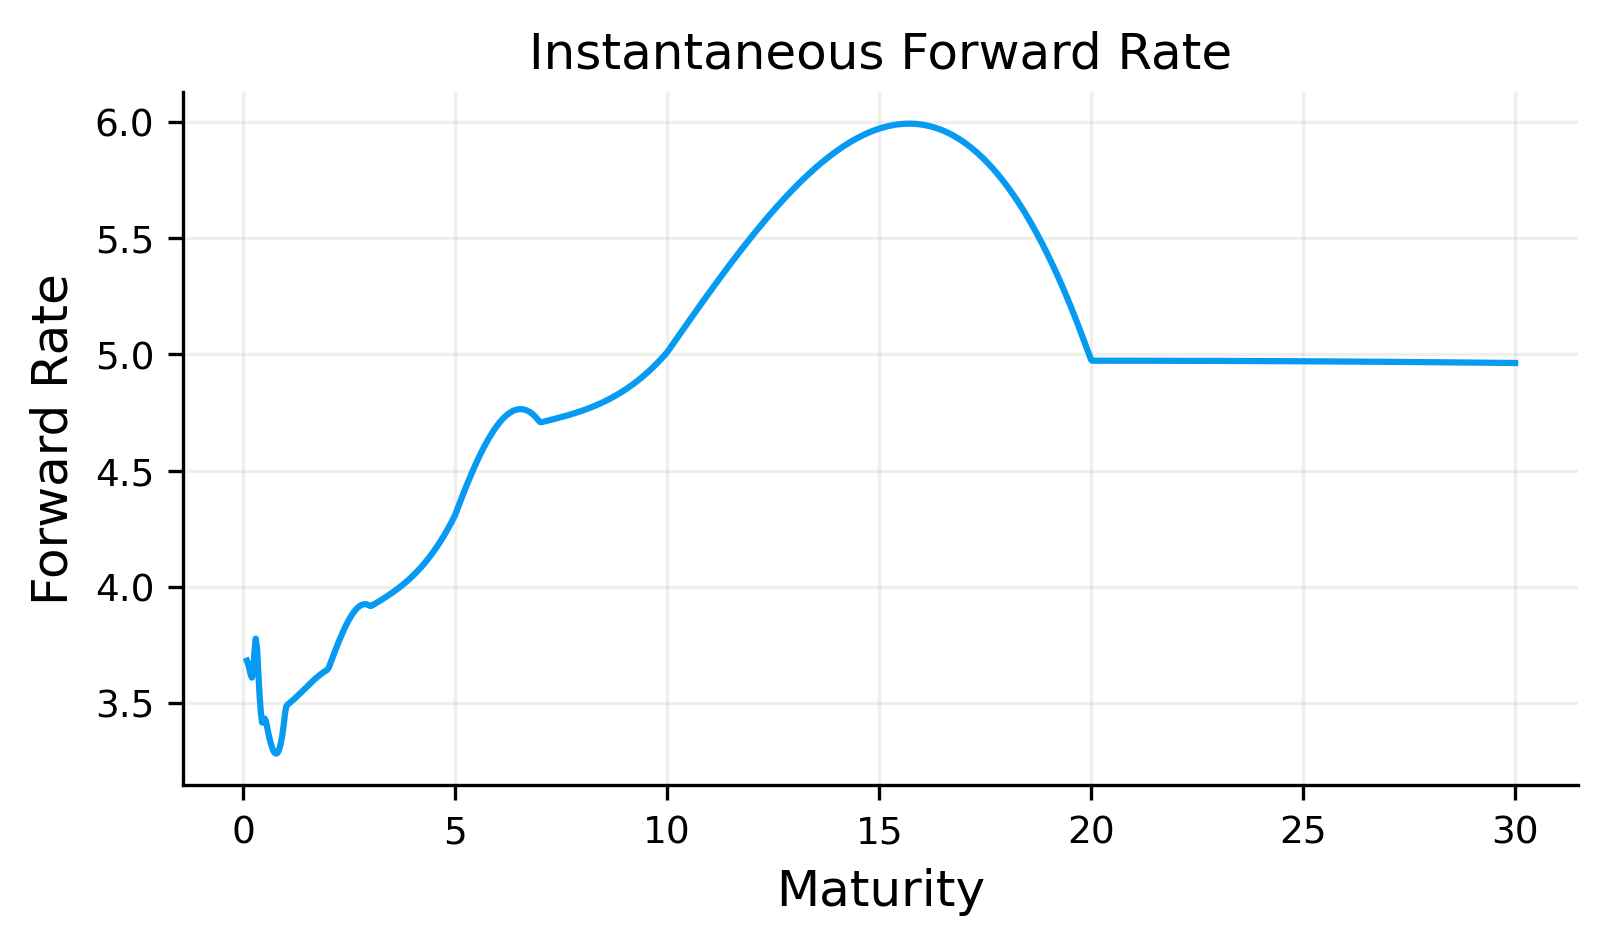

In [6]:
from scipy.interpolate import PchipInterpolator


def pchip_curve(T, dfs):
    pchip_zeros = -np.log(np.clip(dfs, min_d, None)) / T

    pchip_z = PchipInterpolator(T, pchip_zeros, extrapolate=True)
    pchip_grid = np.linspace(max(1 / 12, T.min()), 30.0, 1000)
    pchip_z_grid = pchip_z(pchip_grid)
    pchip_df_grid = np.exp(-pchip_z_grid * pchip_grid)

    pchip_fwd_grid = -np.gradient(
        np.log(np.clip(pchip_df_grid, min_d, None)), pchip_grid)

    def pchip_df_func(t):
        t = np.array(t, dtype=float)
        z = pchip_z(t)
        return np.exp(-z * t)

    return {
        "name": "PCHIP zero",
        "grid": pchip_grid,
        "df_grid": pchip_df_grid,
        "z_grid": pchip_z_grid,
        "fwd_grid": pchip_fwd_grid,
        "df_func": pchip_df_func,
        "pillar_zeros": pchip_zeros}


pchip_curve_data = pchip_curve(T, dfs)
curves["pchip"] = pchip_curve_data


plt.figure()
plt.plot(T, pchip_curve_data["pillar_zeros"] * 100.0, "o", label="pillar zeros")
plt.plot(pchip_curve_data["grid"], pchip_curve_data["z_grid"] * 100.0, "-", label="PCHIP zero")
plt.title("Zero Curve (PCHIP)")
plt.xlabel("Maturity")
plt.ylabel("Zero Rate")
plt.legend()
plt.show()

plt.figure()
plt.plot(T, dfs, "o", label="Pillar DFs")
plt.plot(pchip_curve_data["grid"], pchip_curve_data["df_grid"], "-", label="DF from PCHIP")
plt.title("Discount Factors")
plt.xlabel("Maturity")
plt.ylabel("Discount Factor")
plt.legend()
plt.show()

plt.figure()
plt.plot(pchip_curve_data["grid"], pchip_curve_data["fwd_grid"] * 100.0)
plt.title("Instantaneous Forward Rate")
plt.xlabel("Maturity")
plt.ylabel("Forward Rate")
plt.show()


The PCHIP zero curve follows the bootstrapped zero-rate pillars while producing a smoother path between maturities. The forward curve is smoother than the pure log-linear case, but it can still show local changes where the shape of the zero curve bends.

The PCHIP method can be a useful middle ground. It is still non-parametric and data-driven, but it imposes more shape discipline than linear interpolation.

## 8) Nelson–Siegel–Svensson (NSS) yield curve

we represent the continuous-compounded zero rate curve $z(t)$ with a small number of parameters, then derive discount factors, par yields and forwards

### 8.1 NSS zero-rate function

For maturity $t>0$, the NSS zero rate is:

$$
z(t)=\beta_0 +\beta_1\left(\frac{1-e^{-t/\tau_1}}{t/\tau_1}\right) +\beta_2\left(\frac{1-e^{-t/\tau_1}}{t/\tau_1}-e^{-t/\tau_1}\right) +\beta_3\left(\frac{1-e^{-t/\tau_2}}{t/\tau_2}-e^{-t/\tau_2}\right)
$$

Parameters:

- $\beta_0$ = long-run “level”

- $\beta_1$ = “slope” (short-end effect)

- $\beta_2$ = medium-term “curvature” (first hump)

- $\beta_3$ = additional curvature (second hump)

- $\tau_1,\tau_2>0$ control where humps occur

NSS is not just an interpolation method. It is a parametric curve model. This means it can smooth noisy observations and generate a clean curve, but it may not exactly match every quoted maturity. Its usefulness depends on whether the smooth parametric structure captures the actual shape of the market curve.

In [7]:
def nss_zero(t, b0,b1,b2,b3,tau1,tau2):
    t = np.array(t, dtype=float)
    x1 = t / tau1
    x2 = t / tau2
    L1 = (1.0 - np.exp(-x1)) / x1
    C1 = L1 - np.exp(-x1)
    C2 = (1.0 - np.exp(-x2)) / x2 - np.exp(-x2)
    return b0 + b1*L1 + b2*C1 + b3*C2


### 8.2 Par yield implied by NSS

For a coupon bond with maturity $T$ and coupon frequency $f$, coupon rate $c(T)$ is the rate that makes the bond price equal to par (normalize notional to 1):

$$
1=\sum_{i=1}^{n}\frac{c(T)}{f}D(t_i)+D(T)
$$

Solve for $c(T)$:

$$
c(T)=f\cdot\frac{1-D(T)}{\sum_{i=1}^{n}D(t_i)}
$$


For short maturities (money-market style), a common mapping is:

continuous: $y(T)=-\ln D(T)/T$

simple: $y(T)=(1/D(T)-1)/T$

but first we have to have $D(t)$

In [8]:
def par_from_d(df_func, T_list, f=2):
    T_arr = np.asarray(T_list, dtype=float)
    out = np.full_like(T_arr, np.nan, dtype=float)

    step = 1.0 / float(f)

    for k, Tk in enumerate(T_arr):
        if not np.isfinite(Tk) or Tk <= 0:
            continue

        D_T = float(np.asarray(df_func([Tk],), dtype=float)[0])
        D_T = max(D_T, min_d)

        if Tk < 1.0:
            if short_end_convention == "simple":
                out[k] = (1.0 / D_T - 1.0) / Tk
            else:
                out[k] = -np.log(D_T) / Tk
            continue

        n_full = int(np.floor(Tk * f + 1e-12))
        times = np.arange(step, n_full * step + 1e-12, step)
        if len(times) == 0 or abs(times[-1] - Tk) > 1e-10:
            times = np.append(times, Tk)

        accr = np.diff(np.concatenate([[0.0], times]))
        dfs = np.asarray(df_func(times), dtype=float)
        dfs = np.clip(dfs, min_d, None)

        denom = float(np.sum(accr * dfs))
        out[k] = (1.0 - dfs[-1]) / denom if denom > 0 else np.nan

    return out


### 8.3 Discount factor and forward from NSS

Once we have $z(t)$, using continuous compounding:

$$D(t)=e^{-z(t)t}$$

and the instantaneous forward rate is:

$$f(t)=-\frac{d}{dt}\ln D(t)$$

With NSS we often can compute $f(t)$ numerically on a grid:
$$f(t_i)\approx -\frac{\ln D(t_{i+1})-\ln D(t_{i-1})}{t_{i+1}-t_{i-1}}
$$

---

### 8.4 Calibrating NSS to market par yields

The NSS parameters are chosen by minimizing the difference between market par yields and model-implied par yields.

Let

$$
y^{mkt}(T_j)
$$

be the observed par yield at maturity $T_j$, and let

$$
y^{model}(T_j;\theta)
$$

be the par yield implied by the NSS parameter vector

$$
\theta=(\beta_0,\beta_1,\beta_2,\beta_3,\tau_1,\tau_2).
$$

The calibration objective is

$$
\min_{\theta}
\frac{1}{m}
\sum_{j=1}^{m}
\left[
y^{model}(T_j;\theta)-y^{mkt}(T_j)
\right]^2.
$$

This is a nonlinear optimization problem because the NSS parameters affect zero rates, discount factors, and then par yields. The implementation uses L-BFGS-B, a limited-memory quasi-Newton method that is appropriate for smooth optimization problems with a small number of parameters.

We use the long-end yield level as part of the initial guess because $\beta_0$ behaves like a long-run level parameter. This improves stability and gives the optimizer a reasonable starting point.

final MSE: 3.5093289069366877e-07
theta = [b0,b1,b2,b3,tau1,tau2] = [ 0.053115 -0.014698 -0.031572 -0.007968  1.500251  5.000021]


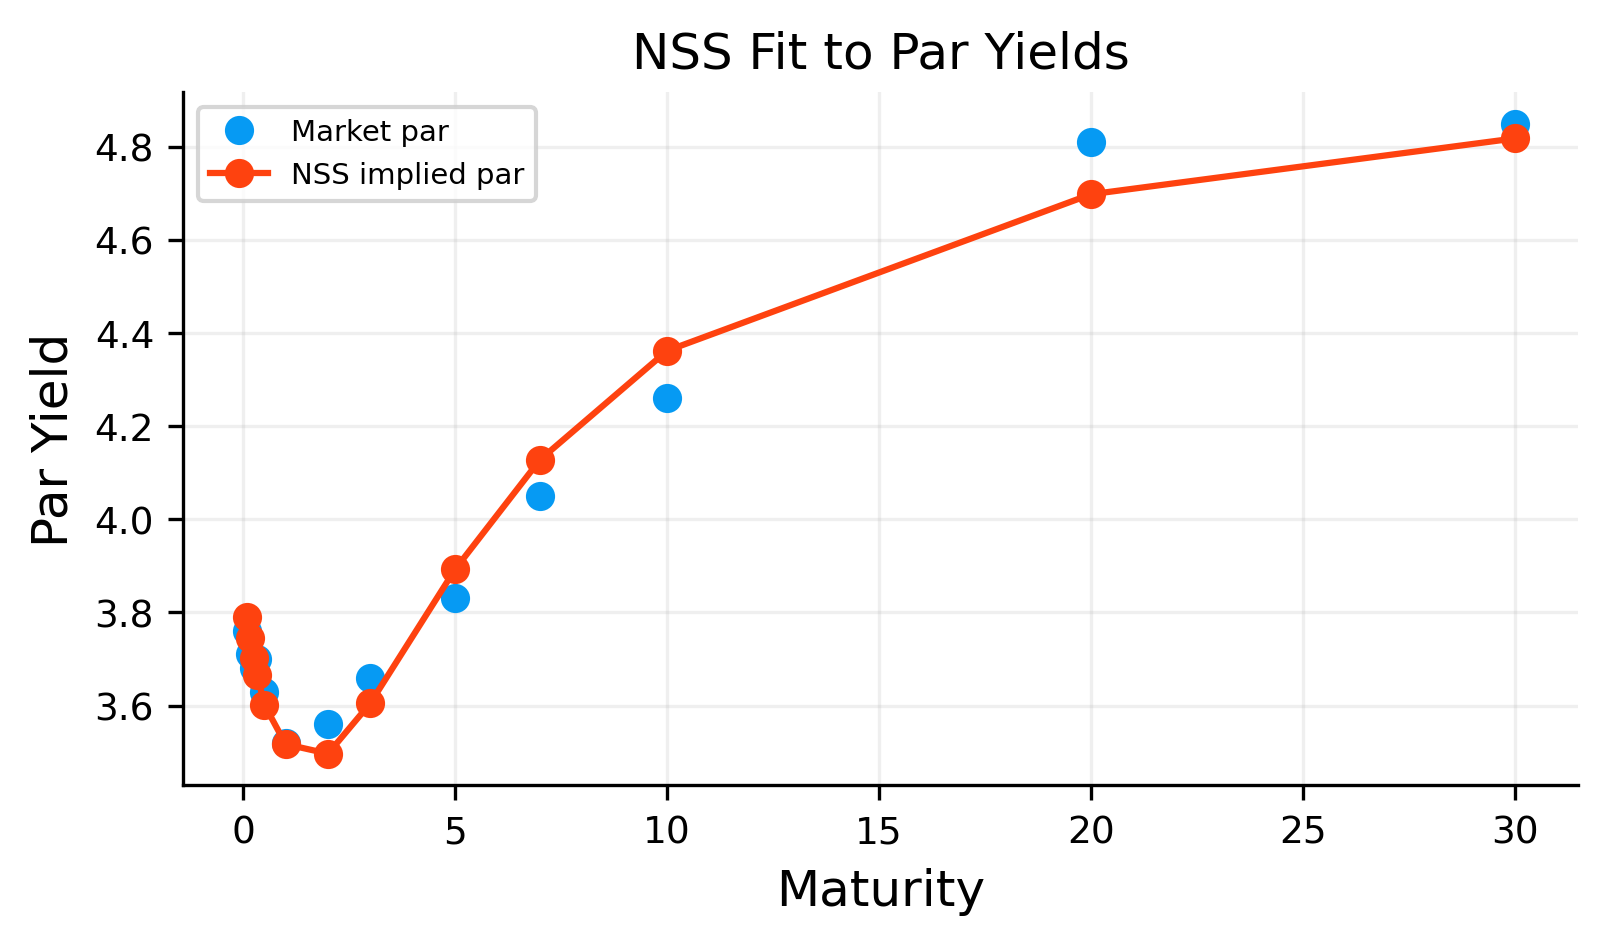

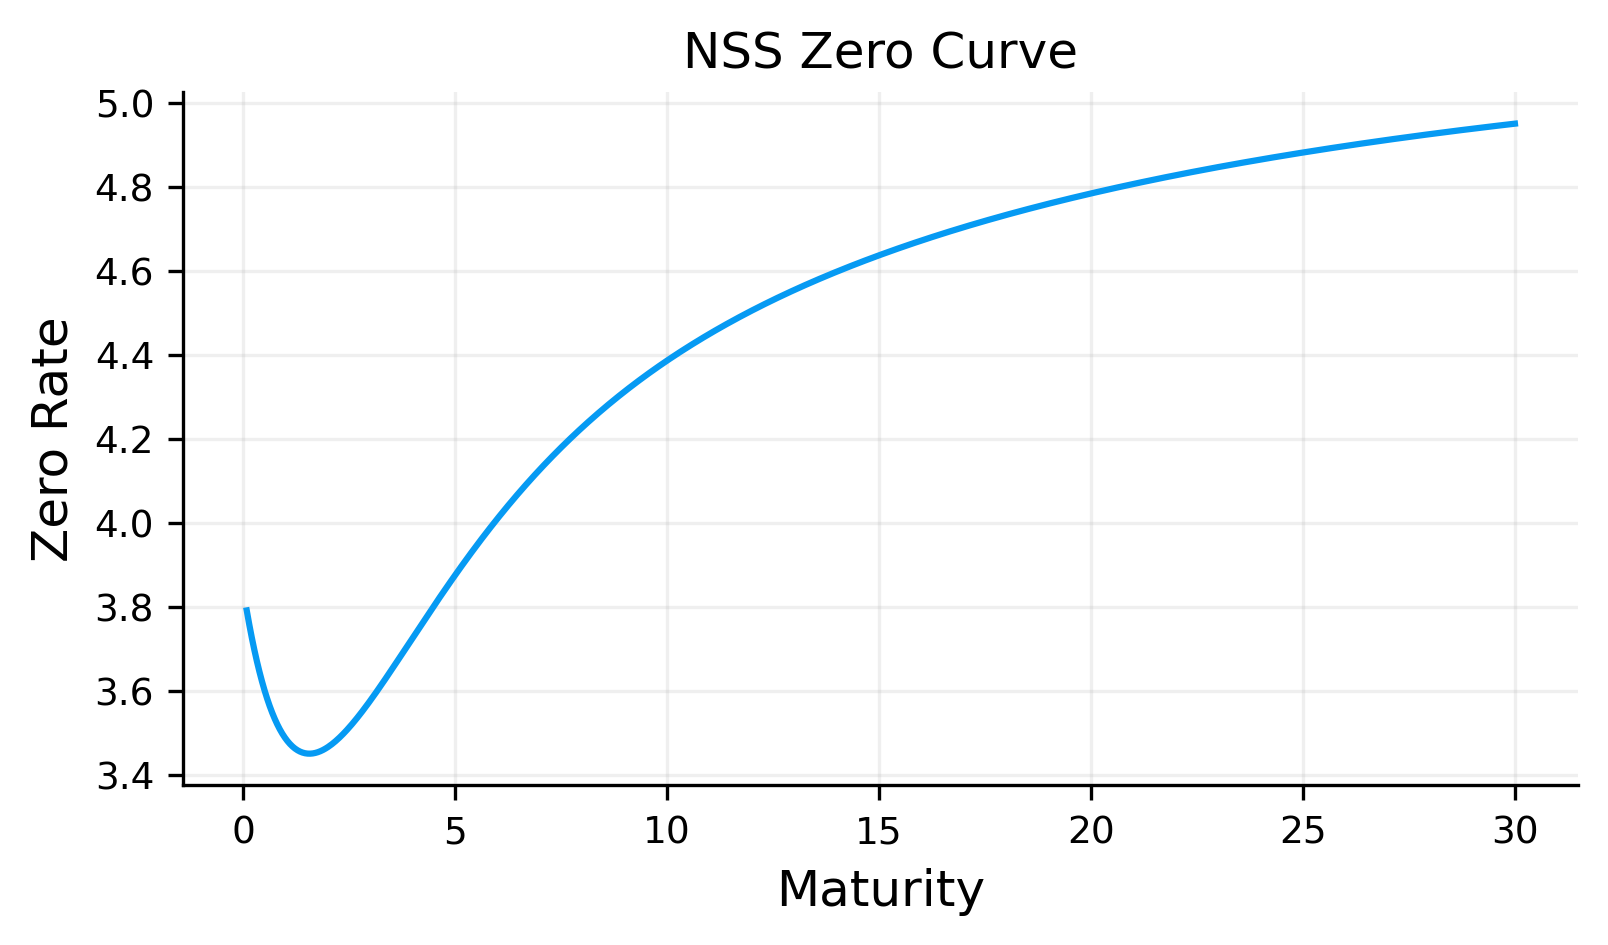

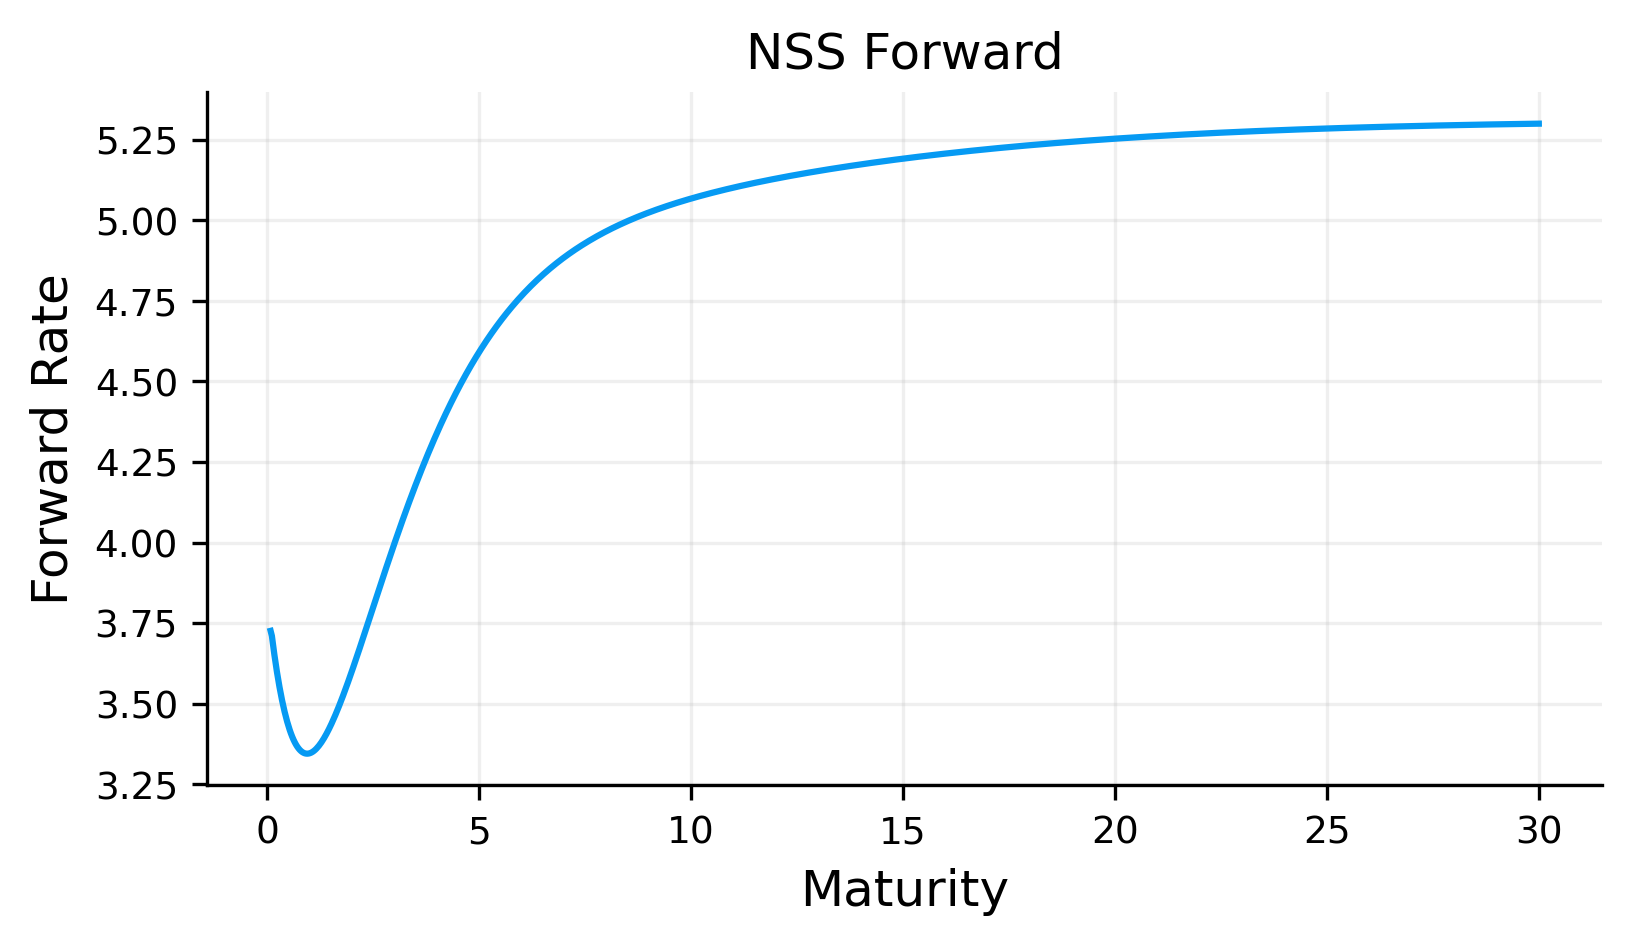

In [9]:
from scipy.optimize import minimize


def nss_curve(T, par):
    def obj(theta):
        b0, b1, b2, b3, tau1, tau2 = theta
        z = nss_zero(T, b0, b1, b2, b3, tau1, tau2)
        dfs = np.exp(-z * T)
        # we use log-linear DF interpolation on pillars for keeping it positive
        log_dfs = np.log(np.clip(dfs, min_d, None))

        def df_func(t):
            t = np.array(t, dtype=float)
            log_df = np.interp(t, T, log_dfs, left=log_dfs[0], right=log_dfs[-1])
            return np.exp(log_df)
        par_model = par_from_d(df_func, T)
        err = par_model - par
        return float(np.mean(err**2))

    # initializing with a first guess. for long run level we need something like the long-run yield level. that's why we use long term yields as guess
    b0_0 = float(np.nanmedian(par[-3:])) if len(par) >= 3 else float(np.nanmedian(par))
    x0 = np.array([b0_0, -0.02, 0.02, 0.01, 1.5, 5.0], dtype=float)
    pred = minimize(obj, x0, method="L-BFGS-B")
    theta = pred.x

    nss_grid = np.linspace(max(1 / 12, T.min()), 30.0, 1000)
    nss_z_grid = nss_zero(nss_grid, *theta)
    nss_df_grid = np.exp(-nss_z_grid * nss_grid)
    nss_fwd_grid = -np.gradient(
        np.log(np.clip(nss_df_grid, min_d, None)), nss_grid)

    def nss_df_func(t):
        t = np.array(t, dtype=float)
        return np.exp(-nss_zero(t, *theta) * t)

    curve = {
        "name": "NSS",
        "grid": nss_grid,
        "df_grid": nss_df_grid,
        "z_grid": nss_z_grid,
        "fwd_grid": nss_fwd_grid,
        "df_func": nss_df_func,
        "theta": theta}


    z_p = nss_zero(T, *theta)
    d_p = np.exp(-z_p * T)
    log_d_p = np.log(np.clip(d_p, min_d, None))
    def df_func_p(tt):
        return np.exp(
            np.interp(np.array(tt, float), T, log_d_p, left=log_d_p[0], right=log_d_p[-1]))
    par_fit = par_from_d(df_func_p, T)
    return curve, par_fit, pred


nss_curve_data, par_fit, pred = nss_curve(T, par)
theta = nss_curve_data["theta"]

if "curves" not in globals():
    curves = {}
curves["nss"] = nss_curve_data

print("final MSE:", pred.fun)
print("theta = [b0,b1,b2,b3,tau1,tau2] =", np.round(theta, 6))

plt.figure()
plt.plot(T, par * 100.0, "o", label="Market par")
plt.plot(T, par_fit * 100.0, "-o", label="NSS implied par")
plt.title("NSS Fit to Par Yields")
plt.xlabel("Maturity")
plt.ylabel("Par Yield")
plt.legend()
plt.show()

plt.figure()
plt.plot(nss_curve_data["grid"], nss_curve_data["z_grid"] * 100.0)
plt.title("NSS Zero Curve")
plt.xlabel("Maturity")
plt.ylabel("Zero Rate")
plt.show()

plt.figure()
plt.plot(nss_curve_data["grid"], nss_curve_data["fwd_grid"] * 100.0)
plt.title("NSS Forward")
plt.xlabel("Maturity")
plt.ylabel("Forward Rate")
plt.show()


## 9) QP curve: smooth discount factors under exact par-bond fit

Another approach for building a yield curve that:

- matches par-bond pricing equations exactly (like bootstrapping) or near-exactly (like NSS),

- is smooth,

- will result in a positive and increasing DF curve.

can come from a Quadratic Program (QP) if the variables are discount factors on a grid and constraints are linear.

### 9.1 Variables

We Pick a grid of cashflow times (like semiannual up to 30Y):
$t_1,t_2,\dots,t_M$

we want to get to 
$$
\mathbf{d} = (D(t_1),\dots,D(t_M))
$$

### 9.2 constraints

For a maturity $T$ (present on the grid), par yield $c$ and frequency $f$:

$$
1=\sum_{i=1}^{n}\frac{c}{f}D(t_i)+D(T)
$$

This is linear in $D(\cdot)$, so it becomes one row of:

$$A\mathbf{d}=\mathbf{1}$$

Positivity: 
$$D(t_k)\ge D_{min}$$

Monotone decreasing: 
$$D(t_{k+1})\le D(t_k)$$

These are linear inequalities, so the problem stays convex and QP-solvable.

In [10]:
import cvxpy as cp


def qp_build_t_grid(T_obs, f):
    T_max = float(np.max(T_obs))
    n_grid = int(round(T_max * f))
    t_grid = np.unique(
        np.concatenate(
            [
                np.array([i / f for i in range(1, n_grid + 1)], dtype=float),
                T_obs,
            ]
        )
    )
    t_grid = np.array(sorted(t_grid), dtype=float)
    grid_index = {float(np.round(t, 10)): i for i, t in enumerate(t_grid)}
    return t_grid, grid_index


def qp_build_constraints(t_grid, grid_index, T_obs, par_mkt, f, min_d):
    d = cp.Variable(len(t_grid))

    constraints = []
    constraints += [d >= min_d]
    constraints += [d[1:] <= d[:-1]]

    for Tk, yk in zip(T_obs, par_mkt, strict=True):
        if Tk < 1.0:
            key = float(np.round(Tk, 10))
            if key in grid_index:
                i = grid_index[key]
                df_target = float(np.exp(-yk * Tk))
                constraints += [d[i] == df_target]

    for Tk, ck in zip(T_obs, par_mkt, strict=True):
        if Tk < 1.0:
            continue
        keyT = float(np.round(Tk, 10))
        if keyT not in grid_index:
            continue
        iT = grid_index[keyT]
        n = int(round(Tk * f))

        coupon_idx = []
        for j in range(1, n + 1):
            key = float(np.round(j / f, 10))
            coupon_idx.append(grid_index[key])

        constraints += [cp.sum((ck / f) * d[coupon_idx]) + d[iT] == 1.0]

    return d, constraints

### 9.3 Smoothness objective (quadratic)

A simple convex smoothness penalty is the squared second difference of Discount Factors:

$$\min_{\mathbf{d}} \ |\Delta^2\mathbf{d}|_2^2$$

where $\Delta^2 d_k = d_{k+2}-2d_{k+1}+d_k$. (Discrete version)

This makes the optimizer prefer sequences of discount factors that have small curvature everywhere, which results a smooth DF curve with fewer oscillations and jumps.

we can also add a mild “keep close to a prior curve” penalty:
$$\epsilon|\mathbf{d}-\mathbf{d}^{prior}|_2^2$$

Total optimization objective:
$$\min_{\mathbf{d}} \ \lambda|\Delta^2\mathbf{d}|_2^2 + \epsilon|\mathbf{d}-\mathbf{d}^{prior}|_2^2$$

### 9.4 zero and forward curves

Once we have $D(t)$ on a grid:

$$z(t_k)=-\ln D(t_k)/t_k$$

$$f(t_k)\approx -\dfrac{\ln D(t_{k+1})-\ln D(t_k)}{t_{k+1}-t_k}$$

status: optimal ,  value: 1.2368745747617473


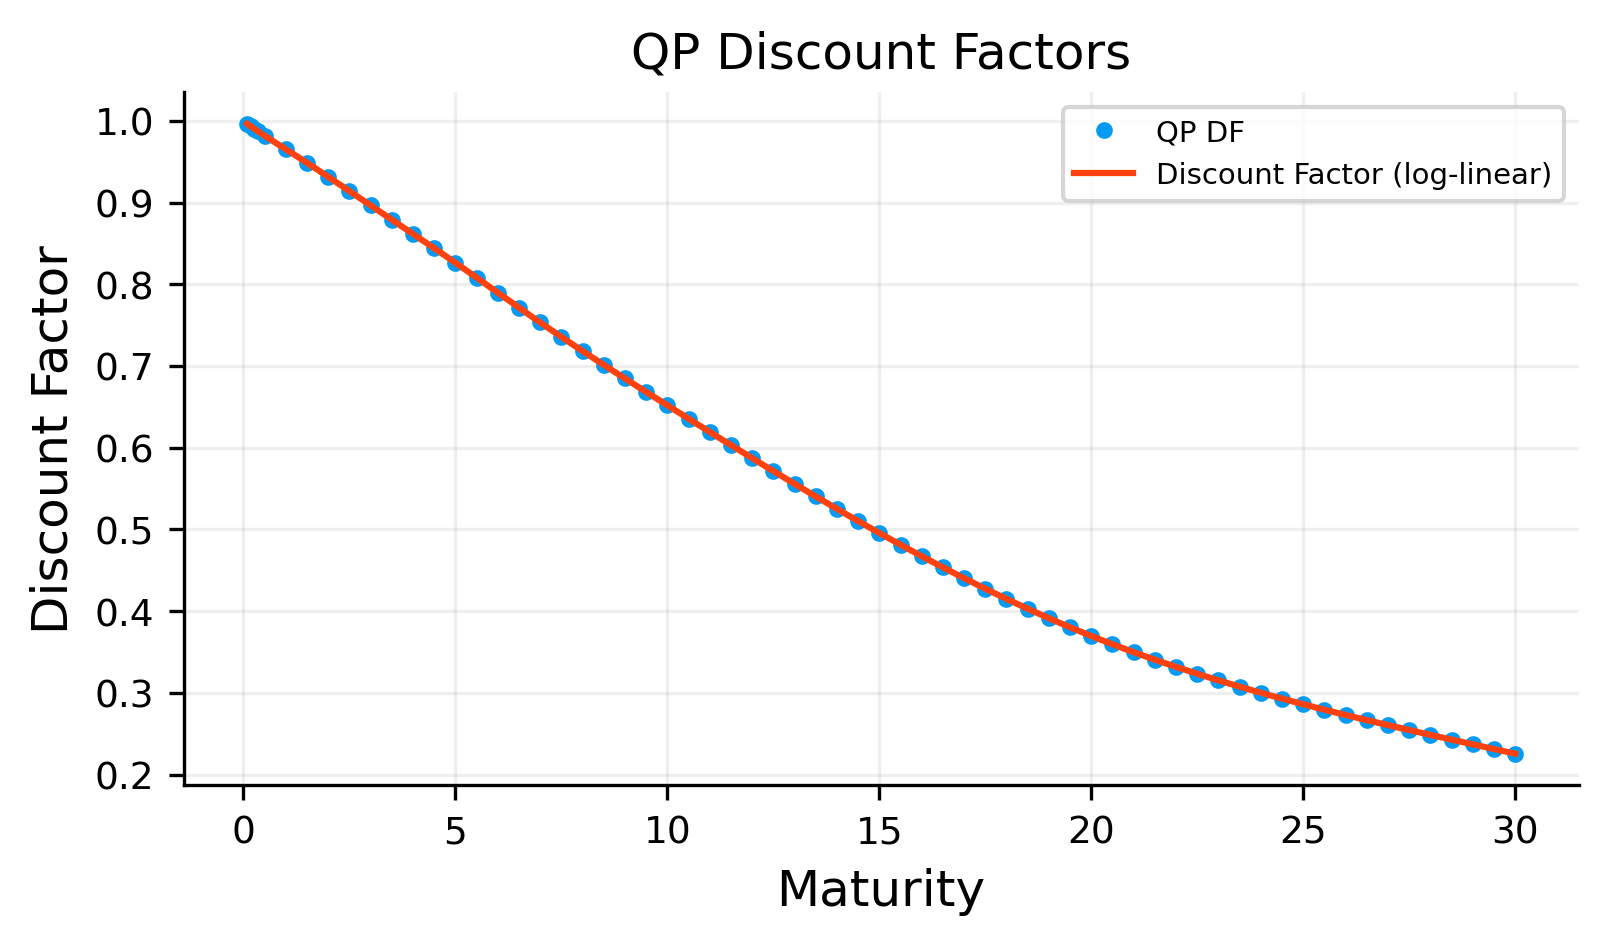

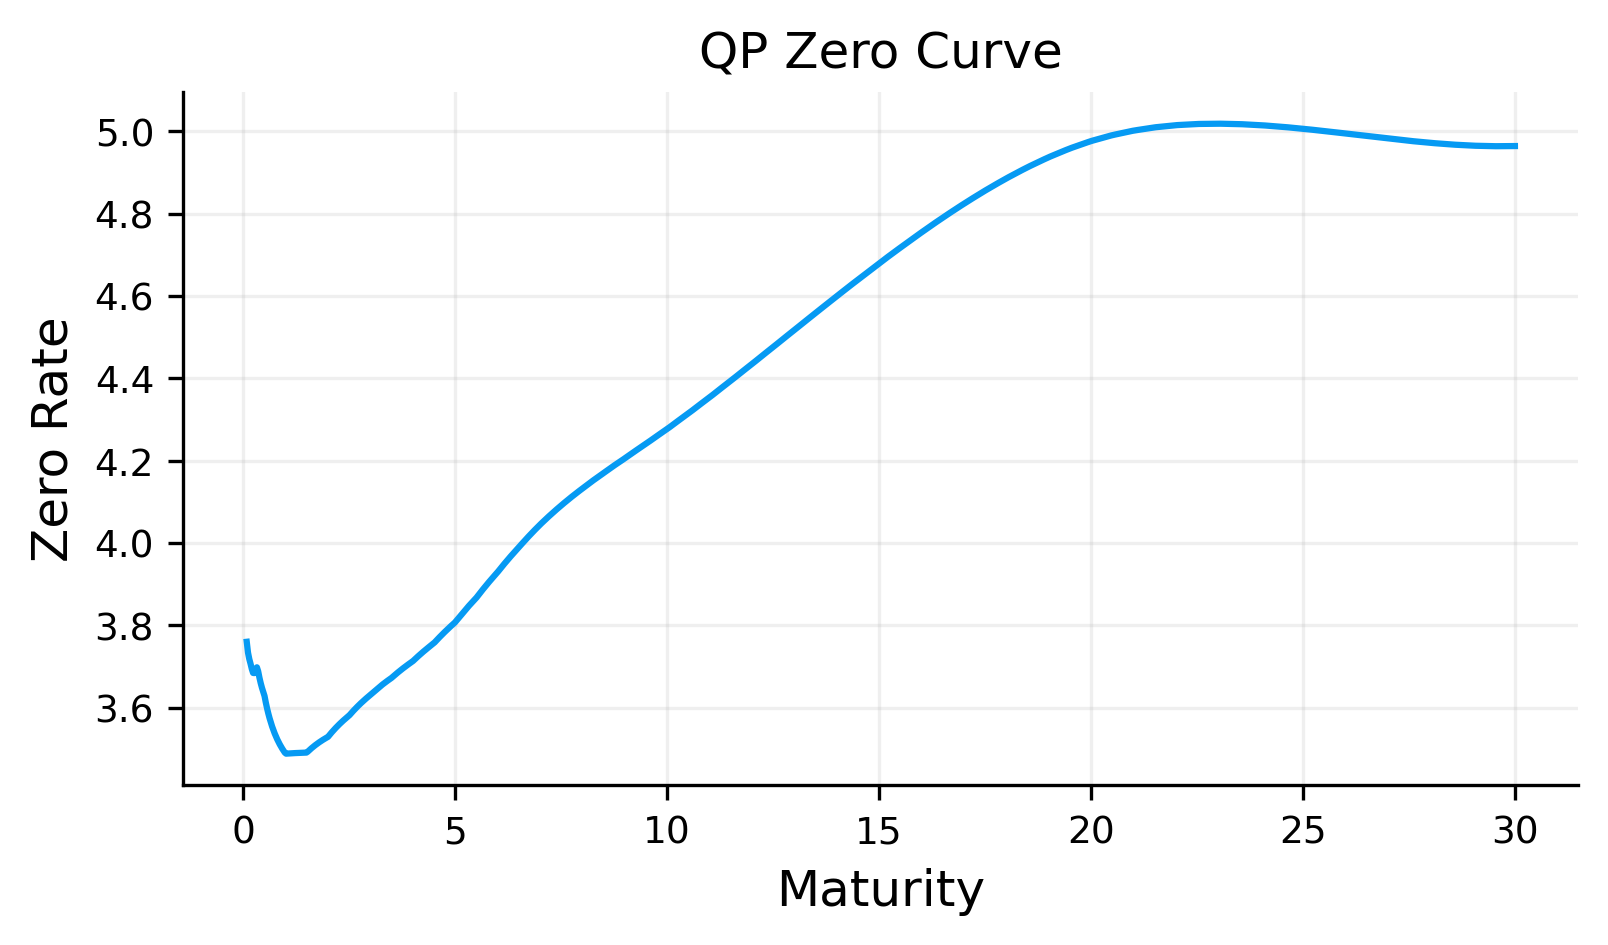

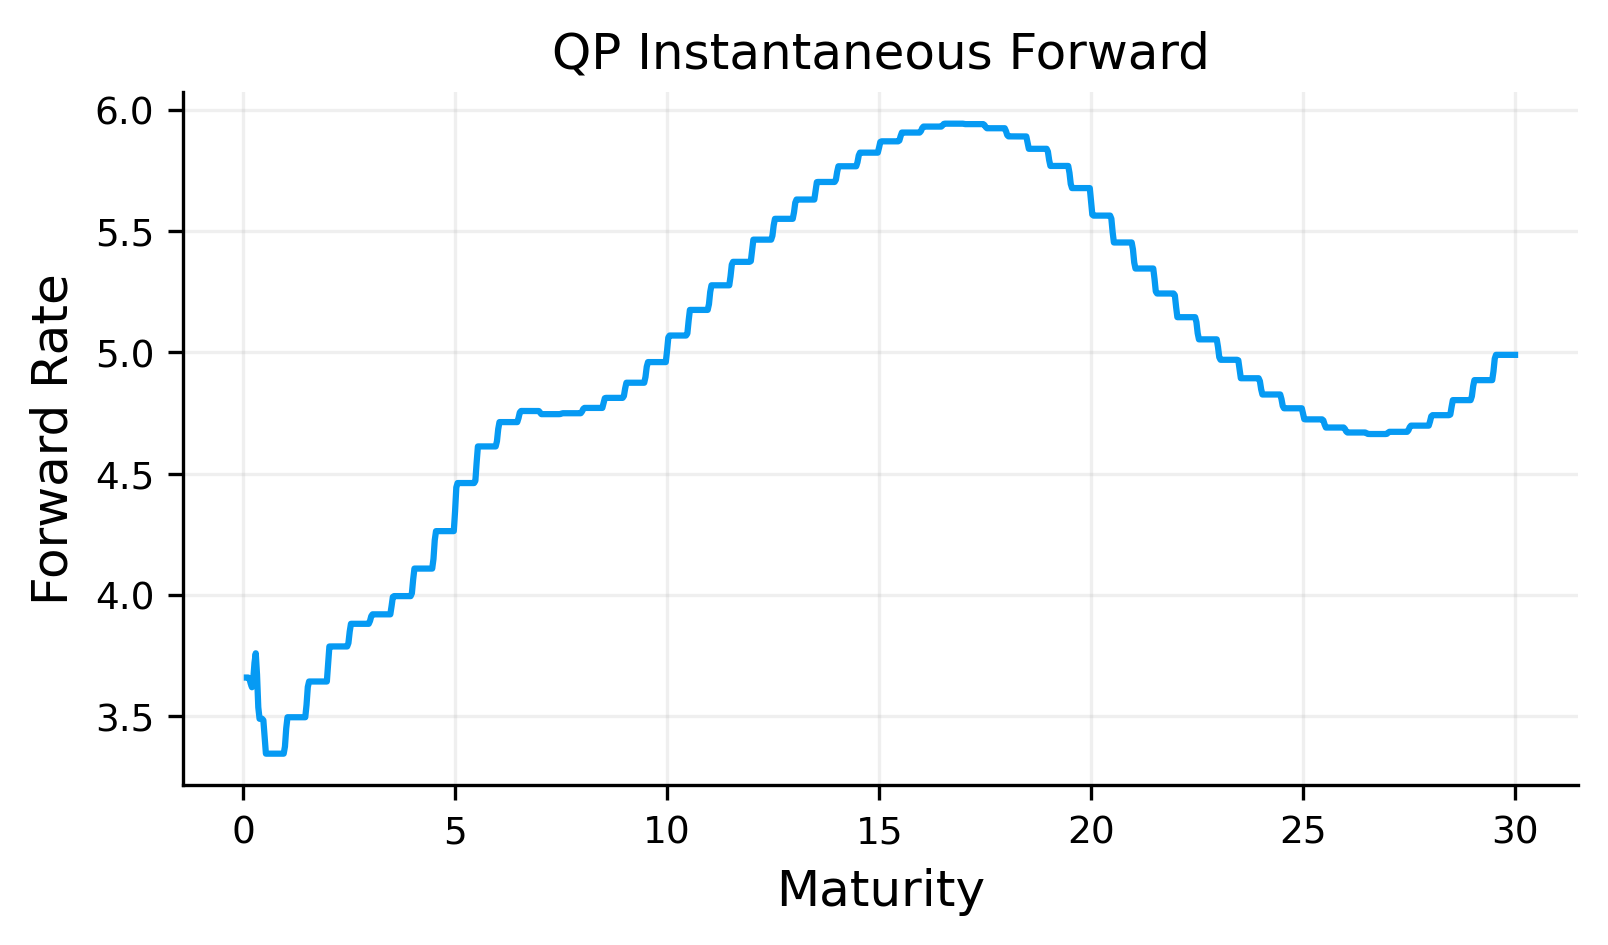

In [11]:
def qp_solve(t_grid, d, constraints, par_mkt, f, min_d):
    lam = 1e4
    eps = 1e-4
    prior_rate = (
        float(np.nanmedian(par_mkt[-3:])) if len(par_mkt) >= 3 else float(np.nanmedian(par_mkt)))
    d_prior = np.exp(-prior_rate * t_grid)
    d2 = d[2:] - 2 * d[1:-1] + d[:-2]
    obj = cp.Minimize(lam * cp.sum_squares(d2) + eps * cp.sum_squares(d - d_prior))
    problem = cp.Problem(obj, constraints)
    problem.solve(solver=cp.OSQP)
    d_sol = np.array(d.value).astype(float)
    d_sol = np.clip(d_sol, min_d, None)
    return d_sol, problem.status, problem.value


def qp_build_curve(t_grid, d_sol):
    qp_grid = np.linspace(max(1 / 12, t_grid.min()), 30.0, 1000)
    qp_log_d = np.log(d_sol)
    qp_log_df_grid = np.interp(qp_grid, t_grid, qp_log_d, left=qp_log_d[0], right=qp_log_d[-1])
    qp_df_grid = np.exp(qp_log_df_grid)
    qp_z_grid = -np.log(qp_df_grid) / np.maximum(qp_grid, 1e-8)
    qp_fwd_grid = -np.gradient(np.log(qp_df_grid), qp_grid)

    def qp_df_func(t):
        t = np.array(t, dtype=float)
        log_df = np.interp(t, t_grid, qp_log_d, left=qp_log_d[0], right=qp_log_d[-1])
        return np.exp(log_df)
    curve = {
        "name": "QP DF",
        "grid": qp_grid,
        "df_grid": qp_df_grid,
        "z_grid": qp_z_grid,
        "fwd_grid": qp_fwd_grid,
        "df_func": qp_df_func}
    return curve


def qp_curve(labels, par_mkt, f=2, min_d=1e-10):
    T_obs = []
    for lab in labels:
        labu = lab.upper().strip()
        T_obs.append(int(labu[:-1]) / 12.0 if labu.endswith("M") else float(int(labu[:-1])))
    T_obs = np.array(T_obs, dtype=float)
    idx = np.argsort(T_obs)
    T_obs = T_obs[idx]
    par_mkt = par_mkt[idx]
    labels = [labels[i] for i in idx]
    t_grid, grid_index = qp_build_t_grid(T_obs, f)
    d, constraints = qp_build_constraints(t_grid, grid_index, T_obs, par_mkt, f, min_d)
    d_sol, status, value = qp_solve(t_grid, d, constraints, par_mkt, f, min_d)
    curve = qp_build_curve(t_grid, d_sol)

    state = {
        "t_grid": t_grid,
        "d_sol": d_sol,
        "constraints": constraints,
        "status": status,
        "value": value}

    return curve, state


qp_curve_data, qp_state = qp_curve(labels, par)
curves["qp"] = qp_curve_data
print("status:", qp_state["status"], ",  value:", qp_state["value"])


plt.figure()
plt.plot(qp_state["t_grid"], qp_state["d_sol"], "o", markersize=3, label="QP DF")
plt.plot(qp_curve_data["grid"], qp_curve_data["df_grid"], "-", label="Discount Factor (log-linear)")
plt.title("QP Discount Factors")
plt.xlabel("Maturity")
plt.ylabel("Discount Factor")
plt.legend()
plt.show()

plt.figure()
plt.plot(qp_curve_data["grid"], qp_curve_data["z_grid"] * 100.0)
plt.title("QP Zero Curve")
plt.xlabel("Maturity")
plt.ylabel("Zero Rate")
plt.show()

plt.figure()
plt.plot(qp_curve_data["grid"], qp_curve_data["fwd_grid"] * 100.0)
plt.title("QP Instantaneous Forward")
plt.xlabel("Maturity")
plt.ylabel("Forward Rate")
plt.show()



## 10. Curve fit comparison and RMSE to observed par yields
We compute curve-implied par yields $\hat y(T_j)$ and compare to market $y(T_j)$:
$RMSE=\sqrt{\dfrac{1}{m}\sum_{j=1}^m (\hat y(T_j)-y(T_j))^2}$

We use two types of errors:

1. **In-sample RMSE**  
   The model is evaluated on the tenors used to fit the curve.

2. **Out-of-sample RMSE**  
   Some tenors are held out during fitting, and the model is evaluated on those held-out maturities.

The out-of-sample check is especially important. A method that exactly reproduces fitted tenors is not automatically the best method if it performs poorly between those points.


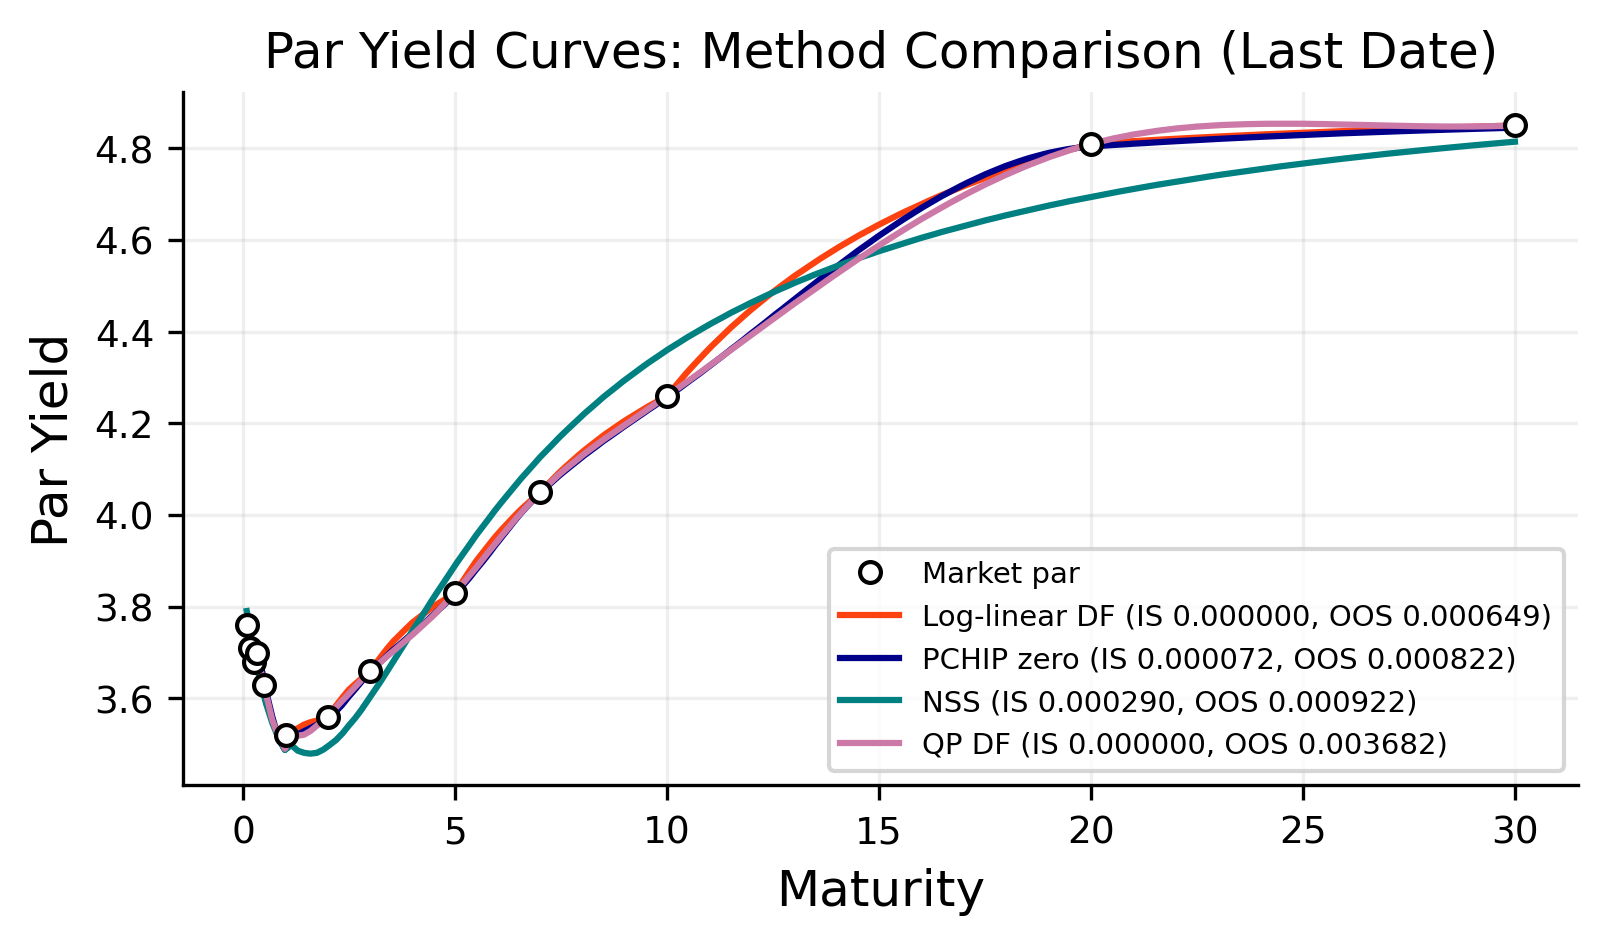

Primary curve selected for everything below: loglinear (Log-linear DF)


,name,rmse,rmse_oos,n_obs,n_obs_oos,n_dates,n_dates_oos
method,,,,,,,
loglinear,Log-linear DF,9.937239e-14,0.000649,900,400,100,100
pchip,PCHIP zero,7.233596e-05,0.000822,900,400,100,100
nss,NSS,2.895659e-04,0.000922,900,400,100,100
qp,QP DF,1.782548e-07,0.003682,900,400,100,100


In [12]:
def build_curves_for_date(date):
    pillars_full = bootstrap_pillars(date)
    if pillars_full is None:
        return None

    T_full = pillars_full["T"]
    par_full = pillars_full["par"]
    labels_full = pillars_full["labels"]

    holdouts = ["6M", "2Y", "7Y", "20Y"]
    holdout_idx = [labels_full.index(h) for h in holdouts if h in labels_full]

    holdout_idx = sorted(set([i for i in holdout_idx if 0 < i < len(labels_full) - 1]))
    min_train = 4
    if len(T_full) - len(holdout_idx) < min_train:
        holdout_idx = []

    if len(holdout_idx) > 0:
        mask_train = np.ones(len(T_full), dtype=bool)
        mask_train[holdout_idx] = False
        T_tr = T_full[mask_train]
        par_tr = par_full[mask_train]
        labels_tr = [labels_full[i] for i in range(len(labels_full)) if mask_train[i]]
        pillars = bootstrap_from_inputs(T_tr, par_tr, labels_tr, date=date)
        T_te = T_full[~mask_train]
        par_te = par_full[~mask_train]
        labels_te = [labels_full[i] for i in range(len(labels_full)) if not mask_train[i]]
    else:
        pillars = pillars_full
        T_te = np.array([], dtype=float)
        par_te = np.array([], dtype=float)
        labels_te = []

    pillars["T_test"] = T_te
    pillars["par_test"] = par_te
    pillars["labels_test"] = labels_te

    T_d = pillars["T"]
    par_d = pillars["par"]
    labels_d = pillars["labels"]
    dfs_d = pillars["dfs"]
    curves_d = {}
    errors = []

    try:
        curves_d["loglinear"] = loglinear_curve(T_d, dfs_d)
    except Exception as e:
        errors.append({"date": date, "method": "loglinear", "error": str(e)})
    try:
        curves_d["pchip"] = pchip_curve(T_d, dfs_d)
    except Exception as e:
        errors.append({"date": date, "method": "pchip", "error": str(e)})
    try:
        curves_d["nss"] = nss_curve(T_d, par_d)[0]
    except Exception as e:
        errors.append({"date": date, "method": "nss", "error": str(e)})
    try:
        curves_d["qp"] = qp_curve(labels_d, par_d)[0]
    except Exception as e:
        errors.append({"date": date, "method": "qp", "error": str(e)})

    return pillars, curves_d, errors

curve_order = ["loglinear", "pchip", "nss", "qp"]

rmse_sse = {k: 0.0 for k in curve_order}
rmse_count = {k: 0 for k in curve_order}
rmse_dates = {k: 0 for k in curve_order}
rmse_sse_oos = {k: 0.0 for k in curve_order}
rmse_count_oos = {k: 0 for k in curve_order}
rmse_dates_oos = {k: 0 for k in curve_order}

failed = []
for date in df_dec.index[-100:]:
    out = build_curves_for_date(date)
    if out is None:
        continue

    pillars_d, curves_d, errors = out
    failed.extend(errors)
    T_tr = pillars_d["T"]
    par_tr = pillars_d["par"]
    T_te = pillars_d["T_test"]
    par_te = pillars_d["par_test"]

    for k in curve_order:
        if k not in curves_d:
            continue
        try:
            c = curves_d[k]

            par_fit_tr = par_from_d(c["df_func"], T_tr)
            err_tr = par_fit_tr - par_tr
            rmse_sse[k] += float(np.sum(err_tr**2))
            rmse_count[k] += int(len(err_tr))
            rmse_dates[k] += 1

            if len(T_te) > 0:
                par_fit_te = par_from_d(c["df_func"], T_te)
                err_te = par_fit_te - par_te
                rmse_sse_oos[k] += float(np.sum(err_te**2))
                rmse_count_oos[k] += int(len(err_te))
                rmse_dates_oos[k] += 1

        except Exception as e:
            failed.append({"date": date, "method": k, "error": str(e)})

rmse_rows = []
for k in curve_order:
    if rmse_count[k] == 0:
        continue

    rmse_in = math.sqrt(rmse_sse[k] / rmse_count[k])
    rmse_out = (math.sqrt(rmse_sse_oos[k] / rmse_count_oos[k])
        if rmse_count_oos[k] > 0
        else float("nan"))

    name_val = curves[k]["name"] if ("curves" in globals() and k in curves) else k

    rmse_rows.append({"method": k, "name": name_val, "rmse": rmse_in, "rmse_oos": rmse_out,
            "n_obs": rmse_count[k], "n_obs_oos": rmse_count_oos[k], "n_dates": rmse_dates[k],
             "n_dates_oos": rmse_dates_oos[k],})

rmse_df = pd.DataFrame(rmse_rows).set_index("method")

if len(failed) > 0:
    print(f"Failed date-method pairs: {len(failed)}")
    display(pd.DataFrame(failed).head())

plot_grid = np.linspace(max(1 / 12, T.min()), T.max(), 200)
plt.figure()
plt.plot(T, par * 100.0, "o", markersize=5, markeredgecolor="black", markerfacecolor="white", label="Market par", zorder=5)

for k in curve_order:
    c = curves[k]
    par_grid = par_from_d(c["df_func"], plot_grid)
    rmse_in = rmse_df.loc[k, "rmse"] if k in rmse_df.index else float("nan")
    rmse_out = rmse_df.loc[k, "rmse_oos"] if k in rmse_df.index else float("nan")
    plt.plot(plot_grid, par_grid * 100.0, label=f"{c['name']} (IS {rmse_in:.6f}, OOS {rmse_out:.6f})")

plt.title("Par Yield Curves: Method Comparison (Last Date)")
plt.xlabel("Maturity")
plt.ylabel("Par Yield")
plt.legend()
plt.show()

rmse_rank = rmse_df.copy()
if rmse_rank["rmse_oos"].notna().any():
    rmse_rank = rmse_rank.sort_values(["rmse_oos", "rmse"])
else:
    rmse_rank = rmse_rank.sort_values(["rmse"])

primary_curve_method = rmse_rank.index[0]
primary_curve_name = rmse_rank.iloc[0]["name"]

print(f"Primary curve selected for everything below: {primary_curve_method} ({primary_curve_name})")
display(rmse_rank)

We select **log-linear discount-factor interpolation** as the primary curve for the analysis.

The in-sample error for the log-linear method is essentially zero because it is built directly from the bootstrapped pillar discount factors. More importantly, it also has the best out-of-sample RMSE among the tested methods over the last 100 dates.

The ranking shows the following pattern:

- **Log-linear DF** has the best holdout performance.
- **PCHIP zero** is close behind, with slightly higher out-of-sample error.
- **NSS** is smoother and interpretable but less accurate in this specific US holdout test.
- **QP** fits the training points extremely well but has the weakest holdout performance in this test.

This is an important result because it argues against unnecessary complexity. Even though NSS and QP are more sophisticated, the simple log-linear discount-factor curve performs best for this particular validation setup and dates. in other conditions or more complex situations we can expect the more complex models to perform better out of sample.

---

## 11) Synthetic Bond Issuance

We now create a synthetic bond issuance process because the raw yield curve data gives us rates, not a full historical data of individual bonds. A real bond strategy needs actual instruments with coupons, maturities, prices, accrued cash flows, and time to maturity. Since we don't have a full issue level Treasury data, we generate one in a controlled and economically interpretable way.

The idea is simple: at each monthly date, we issue new bonds at selected maturities $2$, $5$, $10$, and $30$ years. Each new bond is issued at par, so its coupon is chosen to make the initial clean price approximately equal to one. If $c_t(T)$ is the coupon rate for a newly issued bond with maturity $T$ at date $t$, then $c_t(T)$ is set from the par curve so that

If the discount function at date $t$ is $D_t(\tau)$, which gives the present value of 1 currency unit received at time $t+\tau$ ($\tau$ years after $t$), for a continuously compounded zero coupon yield $z_t(\tau)$,

$$
D_t(\tau) = e^{-z_t(\tau)\tau}.
$$

- coupon rate $c$ (annual),
- payment frequency $f$ (like 2 if it's semi-annual),
- maturity $T$ years,
- face value ($N$) 1,

the cash flows happen at times $\tau_i = i/f$ for $i=1,\dots,n$ where $n = f \cdot T$. The cash flow at $\tau_i$ is $c/f$ for $i<n$, and at $\tau_n = T$ it is $1 + c/f$.

The price of the bond at issuance (time $t$) is

$$
P_t = \sum_{i=1}^{N} CF_i \; D_t(\tau_i).
$$

If the bond was issued in the past and has already aged, we define $\delta$ as the time elapsed since its issue date. The remaining cash flows happen at $\tau_i - \delta$ (for $\tau_i > \delta$), and the price becomes

$$
P_t = \sum_{\tau_i > \delta} CF_i \; D_t(\tau_i - \delta).
$$

When we issue a new bond at date $t$ with maturity $T$, we want its clean price to be exactly 1 (par). This is achieved by setting the coupon $c_t(T)$ such that

$$
P = \sum_{i=1}^{fT} \frac{c_t(T)}{f}\; D_t\!\left(\frac{i}{f}\right) \;+\; 1\cdot D_t(T) \;=\; 1.
$$

In practice, the observed data are **par yields** $y_t(T)$. A par bond has a coupon equal to $y_t(T)$ and a price of 1. Therefore we simply set

$$
c_t(T) = y_t(T)
$$

This guarantees that the bond is issued at par, and its subsequent price evolution is driven purely by changes in the discount curve.


#### 11.4.2 Duration Overlay (Optional)

In addition to the weight‑based rebalancing, we may impose a **duration target**. The effective duration of the portfolio is computed via a parallel shift of the discount curve. If the current duration deviates from the target $D^*$ by more than a band $\Delta_D$, we trade between the shortest and longest maturities (2Y and 30Y) to bring duration back into line. This overlay is applied *after* the standard rebalancing.




In [13]:
issue_maturities = [2, 5, 10, 30]
issue_labels = {2: "2Y", 5: "5Y", 10: "10Y", 30: "30Y"}

bucket_floor = {2: 1.5, 5: 3.5, 10: 7.5, 30: 20.0}
risk_bucket_bounds = {
    2: (0.0, 3.5),
    5: (3.5, 7.5),
    10: (7.5, 20.0),
    30: (20.0, 30.0),
}

target_weights = {2: 0.25, 5: 0.25, 10: 0.25, 30: 0.25}
rebalance_band = 0.05
initial_nav = 100.0
trade_cost_bp = 1.0
cash_tenor_label = "1M"

duration_target = 5.0
duration_band = 0.30

month_end_curve = df_dec[tenor_cols].resample("ME").last()
issue_dates = month_end_curve.index


def yearfrac(t0, t1):
    return (t1 - t0).days / 365.0


def bond_cashflows(c, T, f=2):
    times = np.arange(1 / f, T + 1e-9, 1 / f)
    cfs = np.full_like(times, c / f, dtype=float)
    cfs[-1] += 1.0
    return times, cfs


def make_synthetic_bond(issue_date, maturity_years, coupon, units=0.0, f=2):
    times, cfs = bond_cashflows(coupon, maturity_years, f=f)
    payment_dates = pd.to_datetime(
        [issue_date + pd.DateOffset(months=int(round(12 * t))) for t in times]
    )
    return {
        "issue_date": pd.Timestamp(issue_date),
        "original_maturity": float(maturity_years),
        "coupon": float(coupon),
        "times": times.astype(float),
        "cfs": cfs.astype(float),
        "payment_dates": payment_dates,
        "units": float(units),
        "freq": int(f),
    }


def remaining_maturity(bond, valuation_date):
    if bond is None:
        return 0.0
    delta = yearfrac(bond["issue_date"], valuation_date)
    return float(max(bond["times"][-1] - delta, 0.0))


def get_current_par_yield(date, maturity):
    label = issue_labels[maturity]
    y = float(month_end_curve.loc[date, label])
    if not np.isfinite(y):
        raise ValueError(f"Missing par yield for {label} on {date}")
    return y

def curve_date_for(d):
    if d in df_dec.index:
        return d
    idx = df_dec.index.searchsorted(d, side="right") - 1
    if idx < 0:
        return None
    return df_dec.index[idx]

def get_cash_rate(date, label=cash_tenor_label):
    curve_date = curve_date_for(date)
    if curve_date is None:
        return 0.0
    r = float(df_dec.loc[curve_date, label]) if label in df_dec.columns else np.nan
    if not np.isfinite(r):
        for fallback in ["3M", "6M", "1Y"]:
            if fallback in df_dec.columns:
                r = float(df_dec.loc[curve_date, fallback])
                if np.isfinite(r):
                    break
    return float(r) if np.isfinite(r) else 0.0


def grow_cash(cash, start_date, end_date):
    dt = yearfrac(start_date, end_date)
    r = get_cash_rate(start_date)
    return float(cash * math.exp(r * dt))

max_rebalance_gap_days = 45


def split_contiguous_blocks(dates, max_gap_days=max_rebalance_gap_days):
    dates = pd.DatetimeIndex(sorted(pd.to_datetime(dates).unique()))
    if len(dates) == 0:
        return []

    blocks = []
    start = 0
    for i in range(1, len(dates)):
        if (dates[i] - dates[i - 1]).days > max_gap_days:
            blocks.append(dates[start:i])
            start = i
    blocks.append(dates[start:len(dates)])
    return [pd.DatetimeIndex(b) for b in blocks if len(b) > 0]


def choose_backtest_block(dates, max_gap_days=max_rebalance_gap_days, min_len=60):
    blocks = split_contiguous_blocks(dates, max_gap_days=max_gap_days)
    if len(blocks) == 0:
        return pd.DatetimeIndex([])

    blocks = [b for b in blocks if len(b) >= min_len]
    if len(blocks) == 0:
        return pd.DatetimeIndex([])

    return max(blocks, key=len)


def gap_safe_frame(obj, max_gap_days=max_rebalance_gap_days):
    out = obj.copy()

    if len(out.index) == 0:
        return out

    gap_mask = out.index.to_series().diff().dt.days.gt(max_gap_days)
    gap_dates = gap_mask[gap_mask].index

    if isinstance(out, pd.Series):
        out = out.astype(float)
        out.loc[gap_dates] = np.nan
    else:
        out = out.astype(float)
        out.loc[gap_dates, :] = np.nan

    return out

def price_bond(df_func, times, cfs, delta):
    mask = times > delta + 1e-12
    if not np.any(mask):
        return 0.0
    t_rem = times[mask] - delta
    cf_rem = cfs[mask]
    return float(np.sum(cf_rem * df_func(t_rem)))


def remaining_cashflow_arrays(bond, valuation_date):
    if bond is None or bond.get("units", 0.0) <= 0:
        return np.array([], dtype=float), np.array([], dtype=float)
    delta = yearfrac(bond["issue_date"], valuation_date)
    mask = bond["times"] > delta + 1e-12
    if not np.any(mask):
        return np.array([], dtype=float), np.array([], dtype=float)
    t_rem = bond["times"][mask] - delta
    cf_rem = bond["cfs"][mask] * bond["units"]
    return t_rem, cf_rem

## 12) Fixed-Income Risk Measures: PV01, Duration, Convexity, and Key-Rate Duration

We now move to forward looking risk. This is a crucial step because a fixed income portfolio can have a smooth historical return path while still carrying large hidden sensitivity to rate shocks. A fixed income portfolio can have high coupon income but dangerous long end exposure, or it can have lower yield but much tighter risk control.

### 12.1 $PV01$ and Duration

These meausures show us the first order exposure and sensitivity of a fixed income portfolio to a shock in rates and evaluates how much the value of portfolio would change in the scenraio that rates go up by a small number.

$$ \dfrac{\partial{P}}{\partial{y_t}}$$

The first risk measure is **PV01**, the change in portfolio value for a one basis point move in rates. If the entire curve is shifted up by $\Delta y = 1\text{ bp}=0.0001$. This shows us the exposure  the portfolio PV01 is approximated by

$$
PV01_t\approx P_t(y_t)-P_t(y_t+0.0001).
$$

For a bond or portfolio with value $P$, modified duration can be connected to PV01 as

$$
D_{\text{mod}} \approx \frac{PV01}{P \times 0.0001}.
$$

This gives a direct interpretation: if the modified duration is $6.5$, then a parallel $100$ bp increase in yields produces a $6.5\%$ first order price decline.

The second measure is **effective duration**, which is based on symmetric finite differences and works naturally with curve based pricing:

$$
D_{\text{eff}}=\frac{P(y-\Delta y)-P(y+\Delta y)}{2P_0\Delta y}.
$$

### 12.1 Convexity

This measure shows the second order sensitivity of portfolio to change in rates. We can see how much duration would change for change in rates.

$$ \dfrac{\partial^2{P}}{\partial{y_t}^2}$$

Convexity captures the curvature of the price-yield relationship:

$$
\mathcal{C}+\frac{P(y-\Delta y)+P(y+\Delta y)-2P_0}{P_0(\Delta y)^2}.
$$

The duration approximation alone is linear:

$$
\frac{\Delta P}{P}\approx -D\Delta y.
$$

Adding convexity gives the second-order approximation:

$$
\frac{\Delta P}{P} \approx -D\Delta y+\frac{1}{2}\mathcal{C}(\Delta y)^2.
$$

This matters especially for longer maturity bonds. The price-yield curve is not a straight line. The longer the maturity and the lower the coupon, the more curvature we usually see.

### 12.3 Key Rate Duration

A parallel duration number answers the question "what happens if the whole curve shifts together?" But actual yield curves do not move only in parallel. The short end can rally while the long end sells off, or the five year point can reprice more than the thirty year point. If all the curve would move together, the shape of curve wouldn't change, but it does. We use Key rate duration to decompose the portfolio exposure by curve location.

For key maturity $k_j$ (like 2 years or 10 years), we define a local bump function $b_j(\tau)$ around that key rate and construct a bumped zero curve:

$$
z_t^{(j)}(\tau)=z_t(\tau)+\Delta b_j(\tau).
$$

The bumped discount factor is

$$
D_t^{(j)}(\tau)=\exp(-z_t^{(j)}(\tau)\tau).
$$

The key rate duration for bucket $j$ is estimated by

$$
KRD_j=\frac{P_0-P^{(j)}}{P_0\Delta},
$$

and the key rate PV01 is

$$
KPV01_j = P_0 \times KRD_j \times 0.0001.
$$

A useful check for KRD is that the sum of key rate durations should be close to the effective duration:

$$
\sum_j KRD_j \approx D_{\text{eff}}.
$$

This equality is not exacttly the same in every numerical solution because the bump functions, interpolation, maturity grid, and finite difference options can be different and create small differences.

In [14]:
def bond_position_value(bond, valuation_date, df_func):
    if bond is None or bond.get("units", 0.0) <= 0:
        return 0.0
    delta = yearfrac(bond["issue_date"], valuation_date)
    return float(bond["units"] * price_bond(df_func, bond["times"], bond["cfs"], delta))


def position_values_by_bucket(positions, valuation_date, df_func):
    return {
        T: bond_position_value(positions.get(T), valuation_date, df_func)
        for T in issue_maturities
    }


def bond_cashflows_between(bond, start_date, end_date):
    if bond is None or bond.get("units", 0.0) <= 0:
        return 0.0, 0.0, 0.0

    pay_mask = (bond["payment_dates"] > start_date) & (bond["payment_dates"] <= end_date)
    if not np.any(pay_mask):
        return 0.0, 0.0, 0.0

    gross = float(np.sum(bond["cfs"][pay_mask] * bond["units"]))
    n_pay = int(np.sum(pay_mask))
    coupon = float(n_pay * (bond["coupon"] / bond["freq"]) * bond["units"])
    principal = gross - coupon
    return gross, coupon, principal

def clone_positions(positions):
    return copy.deepcopy(positions)

def shifted_df_func(df_func, shift_func):
    def _f(t):
        t = np.array(t, dtype=float)
        return df_func(t) * np.exp(-shift_func(t) * t)
    return _f

def bucket_bump_func(key, bump_bp=1.0):
    lo, hi = risk_bucket_bounds[key]
    bump = bump_bp / 10000.0
    def shift(t):
        t = np.array(t, dtype=float)
        out = np.zeros_like(t, dtype=float)
        out[(t >= lo) & (t <= hi + 1e-12)] = bump
        return out

    return shift

def curve_date_for(d):
    if d in df_dec.index:
        return d
    idx = df_dec.index.searchsorted(d, side="right") - 1
    if idx < 0:
        return None
    return df_dec.index[idx]

curves_cache = {}
def get_curves_for(date):
    if date in curves_cache:
        return curves_cache[date]
    out = build_curves_for_date(date)
    if out is None:
        curves_cache[date] = None
        return None
    _, curves_d, _ = out
    curves_cache[date] = curves_d
    return curves_d

def get_primary_curve_for(date):
    curves_d = get_curves_for(date)
    if curves_d is None or primary_curve_method not in curves_d:
        return None
    return curves_d[primary_curve_method]

def price_from_ytm(y, times, cfs, f=2):
    return float(np.sum(cfs / np.power(1.0 + y / f, f * times)))

def solve_bond_ytm(price, times, cfs, f=2):
    if price <= 0 or len(times) == 0:
        return np.nan
    lo, hi = -0.05, 0.50
    def err(y):
        return price_from_ytm(y, times, cfs, f=f) - price
    e_lo = err(lo)
    e_hi = err(hi)
    while e_lo * e_hi > 0 and hi < 5.0:
        hi *= 2.0
        e_hi = err(hi)

    if e_lo * e_hi > 0:
        return np.nan

    for _ in range(80):
        mid = 0.5 * (lo + hi)
        e_mid = err(mid)
        if abs(e_mid) < 1e-12:
            return mid
        if e_lo * e_mid <= 0:
            hi = mid
            e_hi = e_mid
        else:
            lo = mid
            e_lo = e_mid
    return 0.5 * (lo + hi)

def bond_modified_duration(bond, valuation_date, df_func, bump_bp=1.0):
    t_rem, cf_rem = remaining_cashflow_arrays(bond, valuation_date)
    if len(t_rem) == 0:
        return 0.0
    price = bond_position_value(bond, valuation_date, df_func)
    price_per_unit = price / max(bond["units"], 1e-12)
    ytm = solve_bond_ytm(price_per_unit, t_rem, cf_rem / max(bond["units"], 1e-12), f=bond["freq"])
    if not np.isfinite(ytm):
        return np.nan
    dy = bump_bp / 10000.0
    p_up = price_from_ytm(ytm + dy, t_rem, cf_rem / max(bond["units"], 1e-12), f=bond["freq"])
    p_dn = price_from_ytm(ytm - dy, t_rem, cf_rem / max(bond["units"], 1e-12), f=bond["freq"])
    return float((p_dn - p_up) / (2.0 * price_per_unit * dy))


def portfolio_parallel_risk(positions, cash, valuation_date, df_func, bump_bp=1.0):
    dy = bump_bp / 10000.0
    base_bucket = position_values_by_bucket(positions, valuation_date, df_func)
    base = cash + sum(base_bucket.values())
    if base <= 0:
        return {"pv01": np.nan, "effective_duration": np.nan, "convexity": np.nan}
    shift_up = shifted_df_func(df_func, lambda t: np.full_like(np.array(t, dtype=float), dy))
    shift_dn = shifted_df_func(df_func, lambda t: np.full_like(np.array(t, dtype=float), -dy))
    pv_up = cash + sum(position_values_by_bucket(positions, valuation_date, shift_up).values())
    pv_dn = cash + sum(position_values_by_bucket(positions, valuation_date, shift_dn).values())
    pv01 = (pv_dn - pv_up) / 2.0
    effective_duration = (pv_dn - pv_up) / (2.0 * base * dy)
    convexity = (pv_up + pv_dn - 2.0 * base) / (base * dy ** 2)
    return {
        "pv01": float(pv01),
        "effective_duration": float(effective_duration),
        "convexity": float(convexity)}


def portfolio_modified_duration(positions, cash, valuation_date, df_func, bump_bp=1.0):
    bucket_values = position_values_by_bucket(positions, valuation_date, df_func)
    total_nav = cash + sum(bucket_values.values())
    if total_nav <= 0:
        return np.nan
    out = 0.0
    for T in issue_maturities:
        value = bucket_values[T]
        if value <= 0:
            continue
        dur_i = bond_modified_duration(positions.get(T), valuation_date, df_func, bump_bp=bump_bp)
        if np.isfinite(dur_i):
            out += (value / total_nav) * dur_i
    return float(out)


def portfolio_key_rate_risk(positions, cash, valuation_date, df_func, bump_bp=1.0):
    base_bucket = position_values_by_bucket(positions, valuation_date, df_func)
    base = cash + sum(base_bucket.values())
    if base <= 0:
        return pd.DataFrame(columns=["key", "krd", "key_rate_pv01"])
    rows = []
    dy = bump_bp / 10000.0
    for key in issue_maturities:
        shift_up = shifted_df_func(df_func, bucket_bump_func(key, bump_bp=+bump_bp))
        shift_dn = shifted_df_func(df_func, bucket_bump_func(key, bump_bp=-bump_bp))
        pv_up = cash + sum(position_values_by_bucket(positions, valuation_date, shift_up).values())
        pv_dn = cash + sum(position_values_by_bucket(positions, valuation_date, shift_dn).values())
        key_rate_pv01 = (pv_dn - pv_up) / 2.0
        krd = (pv_dn - pv_up) / (2.0 * base * dy)
        rows.append({
            "key": key,
            "krd": float(krd),
            "key_rate_pv01": float(key_rate_pv01),
        })
    return pd.DataFrame(rows)


## 13) The Ladder Strategy

Our strategy holds a portfolio of bonds with fixed target maturities $ T = \{2,5,10,30\}$ years. At each rebalancing date (end of each month), we aim to keep the **market value weights** of each maturity bucket equal to a target, for example $w_T^* = 0.25$ for all $T$ (equal weight ladder). The portfolio is rebalanced when any weight deviates by more than a band (like $\pm 0.05$) and we trade to keep the weights inside of the band over time.

A bond that was originally issued with maturity $T$ will, after some months, have a remaining maturity $T_{\text{rem}} < T$. If $T_{\text{rem}}$ falls below a defined floor $\theta_T$ (like for $T=10$ we set $\theta_{10}=7.5$ years), the position is **sold** and then we hold cash until the next rebalancing, where a new 10 year bond will be bought. This is the natural “rolling” of a bond ladder. We never hold a bond that has become too short relative to its original bucket.

The complete process is:

1. On a rebalancing date, compute the current market value of each bond bucket (summing over all bonds in that bucket – though we hold at most one bond per bucket for simplicity).
2. Compute total NAV = cash + sum of bucket values.
3. For each bucket, calculate the current weight $w_T^{\text{curr}} = \text{bucket value} / \text{NAV}$.
4. If any $|w_T^{\text{curr}} - w_T^*| > \text{rebalance\_band}$ (here 0.05) **or** if a bucket is empty (value near zero), we rebalance.
5. Target values: $V_T^* = \text{NAV} \times w_T^*$.
6. Compute deltas $\Delta_T = V_T^* - \text{bucket value}_T$.
7. First sell buckets with negative delta (overweight) to raise cash.
8. Then buy buckets with positive delta (underweight) using available cash.

This two step sell first, then buy, avoids using cash that will be received from sells during the buying step. It also respects transaction costs.

---

## 14) Return Decomposition

The **total return** of the ladder is

$$
R_{t+1} = \frac{NAV_{t+1}}{NAV_t} - 1.
$$

Where $NAV_t$ is the net asset value at the start of period $[t, t+\Delta t]$.

One of the most useful things from simulating bonds is that we can break total return into three components:

1. **Coupon income + cash carry** (actual cash flows received.)
2. **Roll‑down (or carry from time decay)** (the price increase due to the passage of time, assuming the yield curve does not move.)
3. **Curve move P&L** (the price change caused by shifts in the yield curve.)

### 14.1 Coupon Income and Cash Carry

During each period $t$, the portfolio receives coupon payments and principal repayments (if any bond matured). These cash flows are added to the cash account. In addition, cash itself earns interest at the risk free rate $r_t$ (the 1 month rate from the curve). The **coupon + cash carry** component is the sum of:

- All coupon payments received,
- All principal repayments,
- Interest accrued on the cash balance (using continuous compounding: $\text{cash}_{t+1}^{\text{(carry)}} = \text{cash}_t \cdot e^{r_t \Delta t}$).

### 14.2 Roll‑Down (Carry) and Curve Move

To isolate the effect of the yield curve changing from the effect of **time passing** (roll‑down), we perform a same‑curve valuation:

1. At the start of the period, we have positions $\{B_i\}$ and a discount curve $D_t(\cdot)$.
2. Compute the starting $NAV_t$.
3. Move forward to $t+1$, but **keep using the old curve** $D_t$ to re‑price the bonds (as if yields had not changed). Also include the actual coupon, principal, and cash carry received. This gives a hypothetical NAV $NAV_{t+1}^{\text{same curve}}$.
4. The **carry + roll‑down P&L** is 
$$NAV_{t+1}^{\text{same curve}} - NAV_t$$

5. Now reprice the bonds using the new curve $D_{t+1}$. The additional change is the **curve move P&L**:

$$ \text{CurveMove} = NAV_{t+1}^{\text{actual}} - NAV_{t+1}^{\text{same curve}}. $$

So in overall we have:

$$
NAV_{t+1}^{\text{actual}} - NAV_t = \underbrace{\text{CouponIncome} + \text{CashCarry}}_{\text{income}} + \underbrace{\text{RollDown}}_{\text{time decay}} + \underbrace{\text{CurveMove}}_{\text{rate changes}}.
$$

The **roll‑down** shows the fact that a bond's price increases as it gets closer to maturity (if the yield curve is sloping upward), even if yields remain unchanged.

In [15]:
def apply_trade(positions, cash, date, df_func, maturity, target_value_delta, trade_rows, reason):
    tc = trade_cost_bp / 10000.0
    if maturity not in positions or positions[maturity] is None:
        coupon = get_current_par_yield(date, maturity)
        positions[maturity] = make_synthetic_bond(date, maturity, coupon, units=0.0, f=f)
    bond = positions[maturity]
    if bond["units"] > 0:
        price = bond_position_value(bond, date, df_func) / bond["units"]
    else:
        price = 1.0
    if price <= 0:
        return cash
    if target_value_delta < -1e-12:
        sell_value = min(-target_value_delta, bond_position_value(bond, date, df_func))
        sell_units = sell_value / price
        cost = sell_value * tc
        bond["units"] -= sell_units
        cash += sell_value - cost
        trade_rows.append({
            "date": date, "maturity": maturity,
            "side": "sell", "notional": sell_value,
            "price": price, "units": sell_units,
            "cost": cost, "reason": reason})
        if bond["units"] <= 1e-12:
            positions.pop(maturity, None)

    elif target_value_delta > 1e-12:
        buy_value = min(target_value_delta, cash / (1.0 + tc))
        buy_units = buy_value / price
        cost = buy_value * tc
        bond["units"] += buy_units
        cash -= buy_value + cost
        trade_rows.append({
            "date": date, "maturity": maturity,
            "side": "buy", "notional": buy_value,
            "price": price, "units": buy_units,
            "cost": cost, "reason": reason})

    return cash


def roll_bucket_positions(positions, cash, date, df_func):
    trade_rows = []
    tc = trade_cost_bp / 10000.0

    for T in issue_maturities:
        bond = positions.get(T)
        if bond is None:
            continue
        rem = remaining_maturity(bond, date)
        value = bond_position_value(bond, date, df_func)
        if rem <= 1e-10:
            positions.pop(T, None)
            continue
        if rem < bucket_floor[T]:
            cost = value * tc
            cash += value - cost
            trade_rows.append({
                "date": date, "maturity": T,
                "side": "sell", "notional": value,
                "price": value / max(bond["units"], 1e-12),
                "units": bond["units"], "cost": cost,
                "reason": "roll"})
            positions.pop(T, None)

    return positions, cash, trade_rows


def rebalance_to_targets(positions, cash, date, df_func, target_weights, reason="rebalance"):
    trade_rows = []

    bucket_values = position_values_by_bucket(positions, date, df_func)
    nav = cash + sum(bucket_values.values())
    if nav <= 0:
        return positions, cash, trade_rows

    current_weights = {
        T: bucket_values[T] / nav
        for T in issue_maturities}
    need_rebalance = any(abs(current_weights[T] - target_weights[T]) > rebalance_band for T in issue_maturities)
    missing_bucket = any((T not in positions) or (bucket_values[T] <= 1e-12) for T in issue_maturities)

    if not need_rebalance and not missing_bucket:
        return positions, cash, trade_rows

    target_values = {T: nav * target_weights[T] for T in issue_maturities}
    deltas = {T: target_values[T] - bucket_values[T] for T in issue_maturities}

    for T in issue_maturities:
        if deltas[T] < -1e-12:
            cash = apply_trade(positions, cash, date, df_func, T, deltas[T], trade_rows, reason)

    bucket_values = position_values_by_bucket(positions, date, df_func)
    nav = cash + sum(bucket_values.values())
    target_values = {T: nav * target_weights[T] for T in issue_maturities}
    deltas = {T: target_values[T] - bucket_values[T] for T in issue_maturities}

    for T in issue_maturities:
        if deltas[T] > 1e-12:
            cash = apply_trade(positions, cash, date, df_func, T, deltas[T], trade_rows, reason)

    return positions, cash, trade_rows

## 15) Duration Targeting and risk amanagement

We now use the risk measures to create an active overlay. We want to keep the ladder closer to a target duration so that the strategy does not accidentally drift into too much interest rate exposure.

If $D_t$ is the current effective duration of the ladder and let $D^*$ is the target duration (like 5 for example). The targeting problem is to choose portfolio adjustments so that

$$
D_t \approx D^*.
$$

A simple proportional version of the idea can be written as scaling the risky bond exposure by

$$
w_t^{\text{bond}}
\approx
\frac{D^*}{D_t},
$$

with the remaining cash we hold or short duration exposure. In a more realistic ladder implementation, the adjustment is done through bond selection and rebalancing rather than a single continuous scaling factor, but the idea is the same. If the ladder duration is above the target, we reduce long duration exposure. If it is below the target, we allow more duration.

But there is always trade off. Duration targeting usually reduces risk and controls portfolio's sensitivity to interest rates, but it can also reduce carry and curve exposure. Since longer duration bonds often carry higher yields and stronger roll down potential, cutting duration can lower expected return. Therefore, the right question is not whether targeting increases return. The right question is whether the reduction in risk is worth the reduction in return.

In [16]:
def apply_duration_overlay(positions, cash, date, df_func, target_duration, duration_band):
    if target_duration is None:
        return positions, cash, [], np.nan

    eff_dur = portfolio_parallel_risk(positions, cash, date, df_func)["effective_duration"]
    if not np.isfinite(eff_dur) or abs(eff_dur - target_duration) <= duration_band:
        return positions, cash, [], eff_dur
    trade_rows = []
    nav = cash + sum(position_values_by_bucket(positions, date, df_func).values())

    if eff_dur > target_duration:
        sell_T, buy_T = 30, 2
    else:
        sell_T, buy_T = 2, 30

    if sell_T not in positions:
        return positions, cash, trade_rows, eff_dur
    sell_value_now = bond_position_value(positions.get(sell_T), date, df_func)
    if sell_value_now <= 0:
        return positions, cash, trade_rows, eff_dur
    if buy_T not in positions:
        coupon = get_current_par_yield(date, buy_T)
        positions[buy_T] = make_synthetic_bond(date, buy_T, coupon, units=0.0, f=f)
    dur_sell = bond_modified_duration(positions[sell_T], date, df_func)
    dur_buy = bond_modified_duration(positions[buy_T], date, df_func)

    if not np.isfinite(dur_sell) or not np.isfinite(dur_buy) or abs(dur_buy - dur_sell) < 1e-8:
        return positions, cash, trade_rows, eff_dur
    trade_value = abs(nav * (target_duration - eff_dur) / (dur_buy - dur_sell))
    trade_value = min(trade_value, sell_value_now)
    cash = apply_trade(positions, cash, date, df_func, sell_T, -trade_value, trade_rows, "duration_overlay")
    cash = apply_trade(positions, cash, date, df_func, buy_T, +trade_value, trade_rows, "duration_overlay")
    new_eff_dur = portfolio_parallel_risk(positions, cash, date, df_func)["effective_duration"]
    return positions, cash, trade_rows, new_eff_dur

## 15) Backtesting and metrics

We now implement the baseline ladder strategy using the selected primary curve (log-linear) without targeting one specific duration.

### 15.1 Statistics

The monthly return is the percentage of NAV that changed from each month to next:

$$
r_{t+1}^{p}=\frac{NAV_{t+1}-NAV_t}{NAV_t}.
$$

The cumulative wealth is all the gained return from start to a specific time

$$
W_t = \prod_{s \leq t}(1+r_s^p),
$$

and the drawdown is amount we have fell from the peak of cumulative wealth

$$
DD_t = \frac{W_t}{\max_{u \leq t} W_u}-1.
$$

From this return series, the standard strategy statistics are:

$$
\text{Annualized Return} = W_T^{12/N}-1,
$$

$$
\text{Annualized Volatility}=\sqrt{12}\,\sigma(r_t^p),
$$

$$
\text{Max Drawdown}=\min_t DD_t.
$$

Volatility or standard deviation of returns is the main measure of risk. Max drawdown shows the most we fall from the peak wealth.

### 15.2 Transaction Costs and Turnover

Every trade (buy or sell) includes a cost. We model it as a proportional cost on the traded notional value. 

$$\kappa = \text{trade cost bp} / 10000$$

For a sell of notional $V$, the cash received is $V \cdot (1 - \kappa)$. For a buy, the cash paid is $V \cdot (1 + \kappa)$. The difference is lost to the strategy.

**Turnover** for a period is the sum of absolute notional values of all trades during that period, divided by the starting NAV. High turnover may erode returns if the strategy rebalances too aggressively.

In [17]:
def run_ladder_strategy(strategy_name, target_weights, duration_target=None, duration_band=None):
    all_valid_dates = []
    for d in issue_dates:
        curve_date = curve_date_for(d)
        if curve_date is None:
            continue

        curve = get_primary_curve_for(curve_date)
        needed_cols = [issue_labels[T] for T in issue_maturities] + [cash_tenor_label]

        if curve is not None and month_end_curve.loc[d, needed_cols].notna().all():
            all_valid_dates.append(d)

    all_valid_dates = pd.DatetimeIndex(sorted(pd.to_datetime(all_valid_dates).unique()))
    valid_dates = choose_backtest_block(all_valid_dates, max_gap_days=max_rebalance_gap_days, min_len=60)

    if len(valid_dates) == 0:
        raise ValueError("No contiguous valid block available for the chosen primary curve.")

    print(
        f"{strategy_name}: using contiguous block "
        f"{valid_dates[0].date()} -> {valid_dates[-1].date()} "
        f"({len(valid_dates)} dates)")

    start_date = valid_dates[0]
    positions = {}
    cash = float(initial_nav)

    for T in issue_maturities:
        coupon = get_current_par_yield(start_date, T)
        units = initial_nav * target_weights[T]
        positions[T] = make_synthetic_bond(start_date, T, coupon, units=units, f=f)
        cash -= units

    rows = []
    bucket_rows = []
    trade_rows = []
    carry_rows = []
    snapshots = {}

    start_curve = get_primary_curve_for(curve_date_for(start_date))
    df_start = start_curve["df_func"]
    start_bucket_values = position_values_by_bucket(positions, start_date, df_start)
    start_nav = cash + sum(start_bucket_values.values())

    rows.append({
        "date": start_date, "strategy": strategy_name,
        "nav": start_nav, "cash": cash, "ret": np.nan,
        "coupon_income": 0.0, "principal_income": 0.0,
        "cash_carry": 0.0, "curve_move_pnl": 0.0,
        "carry_roll_pnl": 0.0, "turnover": 0.0})
    
    for T in issue_maturities:
        bucket_rows.append({
            "date": start_date, "strategy": strategy_name,
            "maturity": T, "pv": start_bucket_values[T],
            "weight": start_bucket_values[T] / start_nav if start_nav > 0 else np.nan})

    snapshots[start_date] = {"positions": clone_positions(positions), "cash": float(cash)}

    for i in range(1, len(valid_dates)):
        prev_date = valid_dates[i - 1]
        date = valid_dates[i]
        gap_days = (date - prev_date).days
        if gap_days > max_rebalance_gap_days:
            raise RuntimeError(
                f"Gap of {gap_days} days detected between {prev_date.date()} and {date.date()} "
                f"in {strategy_name}. The backtest should not cross structural gaps.")

        prev_curve = get_primary_curve_for(curve_date_for(prev_date))
        current_curve = get_primary_curve_for(curve_date_for(date))
        if prev_curve is None or current_curve is None:
            continue

        df_prev = prev_curve["df_func"]
        df_now = current_curve["df_func"]

        positions_start = clone_positions(positions)
        cash_start = float(cash)
        nav_start = cash_start + sum(position_values_by_bucket(positions_start, prev_date, df_prev).values())

        cash = grow_cash(cash, prev_date, date)
        cash_carry = cash - cash_start

        coupon_income = 0.0
        principal_income = 0.0
        for T in list(positions.keys()):
            gross, coupon, principal = bond_cashflows_between(positions[T], prev_date, date)
            cash += gross
            coupon_income += coupon
            principal_income += principal

        same_curve_positions = sum(position_values_by_bucket(positions_start, date, df_prev).values())
        same_curve_nav = cash_start + cash_carry + coupon_income + principal_income + same_curve_positions

        actual_positions_pretrade = sum(position_values_by_bucket(positions, date, df_now).values())
        actual_nav_pretrade = cash + actual_positions_pretrade

        carry_roll_pnl = same_curve_nav - nav_start
        curve_move_pnl = actual_nav_pretrade - same_curve_nav

        positions, cash, roll_trades = roll_bucket_positions(positions, cash, date, df_now)
        period_trades = list(roll_trades)

        positions, cash, rebalance_trades = rebalance_to_targets(
            positions, cash, date, df_now, target_weights, reason="rebalance")
        period_trades.extend(rebalance_trades)

        if duration_target is not None:
            positions, cash, overlay_trades, _ = apply_duration_overlay(
                positions, cash, date, df_now, duration_target, duration_band)
            period_trades.extend(overlay_trades)

        bucket_values = position_values_by_bucket(positions, date, df_now)
        end_nav = cash + sum(bucket_values.values())
        turnover = (
            sum(tr["notional"] for tr in period_trades) / nav_start
            if nav_start > 0 else np.nan)

        rows.append({
            "date": date,
            "strategy": strategy_name,
            "nav": end_nav,
            "cash": cash,
            "ret": (end_nav / nav_start - 1.0) if nav_start > 0 else np.nan,
            "coupon_income": coupon_income,
            "principal_income": principal_income,
            "cash_carry": cash_carry,
            "curve_move_pnl": curve_move_pnl,
            "carry_roll_pnl": carry_roll_pnl,
            "turnover": turnover})

        for T in issue_maturities:
            bucket_rows.append({
                "date": date, "strategy": strategy_name,
                "maturity": T, "pv": bucket_values[T],
                "weight": bucket_values[T] / end_nav if end_nav > 0 else np.nan})

        for tr in period_trades:
            tr["strategy"] = strategy_name
            trade_rows.append(tr)

        coupon_carry_pnl = coupon_income + cash_carry
        roll_pnl = carry_roll_pnl - coupon_carry_pnl
        nav_denom = nav_start if nav_start > 0 else np.nan

        carry_rows.append({
            "date": date,
            "strategy": strategy_name,
            "coupon_carry_pnl": coupon_carry_pnl,
            "roll_pnl": roll_pnl,
            "curve_move_pnl": curve_move_pnl,
            "coupon_carry_ret": coupon_carry_pnl / nav_denom if nav_start > 0 else np.nan,
            "roll_ret": roll_pnl / nav_denom if nav_start > 0 else np.nan,
            "curve_move_ret": curve_move_pnl / nav_denom if nav_start > 0 else np.nan,
            "explained_ret": (coupon_carry_pnl + roll_pnl + curve_move_pnl) / nav_denom if nav_start > 0 else np.nan,
        })

        snapshots[date] = {"positions": clone_positions(positions), "cash": float(cash)}

    strategy_df = pd.DataFrame(rows).set_index("date").sort_index()
    bucket_df = pd.DataFrame(bucket_rows).sort_values(["date", "maturity"])
    trade_df = pd.DataFrame(trade_rows)
    carry_df = pd.DataFrame(carry_rows).set_index("date").sort_index()

    return strategy_df, bucket_df, trade_df, carry_df, snapshots


baseline_ladder: using contiguous block 2006-02-28 -> 2026-01-31 (240 dates)
Primary curve used below: loglinear
Baseline strategy summary:


,final_nav,annualized_return,annualized_vol,max_drawdown
baseline_ladder,182.258234,0.030596,0.060663,-0.202618


Recent trades:


,date,maturity,side,notional,price,units,cost,reason,strategy
261,2025-01-31,10,buy,1.124060,1.018643,1.103488,0.000112,rebalance,baseline_ladder
262,2025-01-31,30,buy,2.496421,0.722192,3.456726,0.000250,rebalance,baseline_ladder
263,2025-08-31,2,sell,43.511321,1.010234,43.070519,0.004351,roll,baseline_ladder
264,2025-08-31,2,buy,44.792990,1.000000,44.792990,0.004479,rebalance,baseline_ladder
265,2025-08-31,5,buy,0.555761,1.042242,0.533236,0.000056,rebalance,baseline_ladder
266,2025-08-31,10,buy,0.273409,1.052914,0.259669,0.000027,rebalance,baseline_ladder
267,2025-08-31,30,buy,2.324158,0.712101,3.263806,0.000232,rebalance,baseline_ladder
268,2025-11-30,5,sell,44.375081,1.032518,42.977517,0.004438,roll,baseline_ladder
269,2025-11-30,30,sell,1.205887,0.748473,1.611131,0.000121,rebalance,baseline_ladder
270,2025-11-30,2,buy,0.634953,1.009867,0.628749,0.000063,rebalance,baseline_ladder


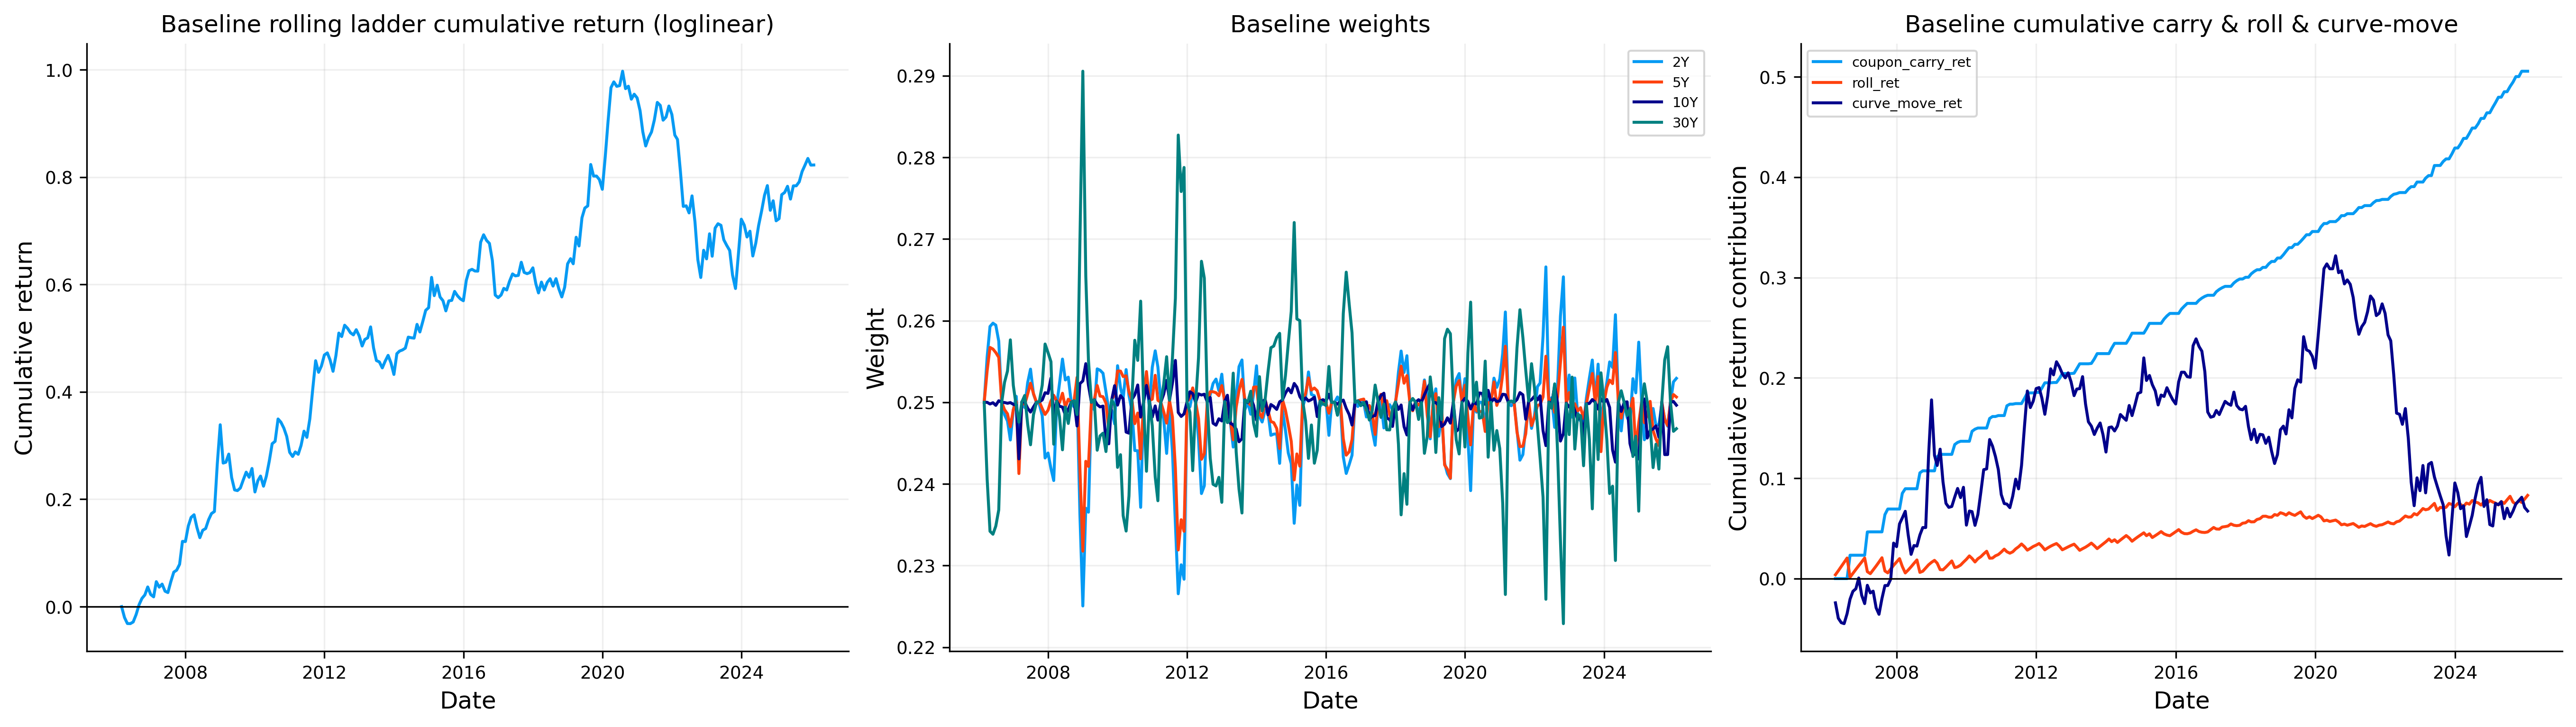

In [18]:
def strategy_summary_table(strategy_df):
    rets = strategy_df["ret"].dropna()
    if len(rets) == 0:
        return pd.DataFrame()

    wealth = (1.0 + rets).cumprod()
    running_max = wealth.cummax()
    drawdown = wealth / running_max - 1.0

    ann_return = wealth.iloc[-1] ** (12.0 / len(rets)) - 1.0
    ann_vol = rets.std(ddof=1) * np.sqrt(12.0) if len(rets) > 1 else np.nan
    max_dd = drawdown.min()

    return pd.DataFrame([{
        "final_nav": strategy_df["nav"].iloc[-1],
        "annualized_return": ann_return,
        "annualized_vol": ann_vol,
        "max_drawdown": max_dd,
    }], index=[strategy_df["strategy"].iloc[0]])


baseline_df, baseline_bucket_df, baseline_trades_df, baseline_carry_df, baseline_snapshots = run_ladder_strategy(
    strategy_name="baseline_ladder",
    target_weights=target_weights,
    duration_target=None, duration_band=None)

print(f"Primary curve used below: {primary_curve_method}")
print("Baseline strategy summary:")
display(strategy_summary_table(baseline_df))
print("Recent trades:")
display(baseline_trades_df.tail(12))
baseline_weights = baseline_bucket_df.pivot(index="date", columns="maturity", values="weight").sort_index()
baseline_weights_plot = gap_safe_frame(baseline_weights)
baseline_cumret = (1.0 + baseline_df["ret"].fillna(0.0)).cumprod() - 1.0
baseline_cumret_plot = gap_safe_frame(baseline_cumret)
baseline_carry_cum = baseline_carry_df[["coupon_carry_ret", "roll_ret", "curve_move_ret"]].fillna(0.0).cumsum()
baseline_carry_cum_plot = gap_safe_frame(baseline_carry_cum)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
axes[0].plot(baseline_cumret_plot.index, baseline_cumret_plot.values)
axes[0].axhline(0.0, color="black", linewidth=0.8)
axes[0].set_title(f"Baseline rolling ladder cumulative return ({primary_curve_method})")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Cumulative return")

for T in issue_maturities:
    axes[1].plot(baseline_weights_plot.index, baseline_weights_plot[T], label=f"{T}Y")
axes[1].set_title("Baseline weights")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Weight")
axes[1].legend()

for col in baseline_carry_cum_plot.columns:
    axes[2].plot(baseline_carry_cum_plot.index, baseline_carry_cum_plot[col], label=col)
axes[2].axhline(0.0, color="black", linewidth=0.8)
axes[2].set_title("Baseline cumulative carry & roll & curve-move")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Cumulative return contribution")
axes[2].legend()

plt.show()

The simulation and backtesting is for a time window of monthly data from **2006-02-28 to 2026-01-31**. This is not only a calm period window. It includes the Financial crisis period, the zero rate regime and the post 2021 inflation shock.

The baseline ladder summary shows:

| Strategy | Final NAV | Annualized return | Annualized volatility | Max drawdown |
|---|---:|---:|---:|---:|
| Baseline ladder | 182.2582 | 3.0596% | 6.0663% | -20.2618% |

This output is expected for a Treasury ladder. The annualized return is positive but not like equity, the volatility is lower than a stock portfolio, and the drawdown is still meaningful because intermediate and long duration bonds can lose lots of their value when rates rise quickly.

The most important detail is that the ladder is not riskless. A ladder is often described as conservative because coupon income and maturity diversification smooth the path, but the strategy still has duration exposure. When the yield curve shifts upward, the present value of the remaining cash flows falls. Coupon income and carry/roll effects are usually stabilizing, but curve-move P\&L can dominate in months where rates move sharply.

In [19]:
def strategy_risk_timeseries(strategy_df, snapshots):
    risk_rows = []
    krd_rows = []

    for date in strategy_df.index:
        curve = get_primary_curve_for(curve_date_for(date))
        if curve is None or date not in snapshots:
            continue

        df_func = curve["df_func"]
        positions = clone_positions(snapshots[date]["positions"])
        cash = float(snapshots[date]["cash"])

        parallel = portfolio_parallel_risk(positions, cash, date, df_func, bump_bp=1.0)
        mod_dur = portfolio_modified_duration(positions, cash, date, df_func, bump_bp=1.0)

        risk_rows.append({
            "date": date,
            "strategy": strategy_df.loc[date, "strategy"],
            "nav": strategy_df.loc[date, "nav"],
            "pv01": parallel["pv01"],
            "modified_duration": mod_dur,
            "effective_duration": parallel["effective_duration"],
            "convexity": parallel["convexity"],
        })

        krd_tmp = portfolio_key_rate_risk(positions, cash, date, df_func, bump_bp=1.0)
        if len(krd_tmp) > 0:
            krd_tmp["date"] = date
            krd_tmp["strategy"] = strategy_df.loc[date, "strategy"]
            krd_rows.append(krd_tmp)

    risk_df = pd.DataFrame(risk_rows).set_index("date").sort_index()
    krd_df = pd.concat(krd_rows, axis=0, ignore_index=True) if len(krd_rows) > 0 else pd.DataFrame()
    return risk_df, krd_df

Baseline risk summary:


,pv01,modified_duration,effective_duration,convexity
date,,,,
2025-09-30,0.121968,6.638165,6.737480,85.036803
2025-10-31,0.121810,6.584971,6.683788,84.566819
2025-11-30,0.126783,6.813048,6.910113,84.814958
2025-12-31,0.123132,6.660231,6.756776,82.182537
2026-01-31,0.121644,6.573155,6.674283,81.160590


Baseline KRD on the last date:


,key,krd,key_rate_pv01
956,2,0.543016,0.009897
957,5,1.402075,0.025554
958,10,2.136849,0.038946
959,30,2.592342,0.047248


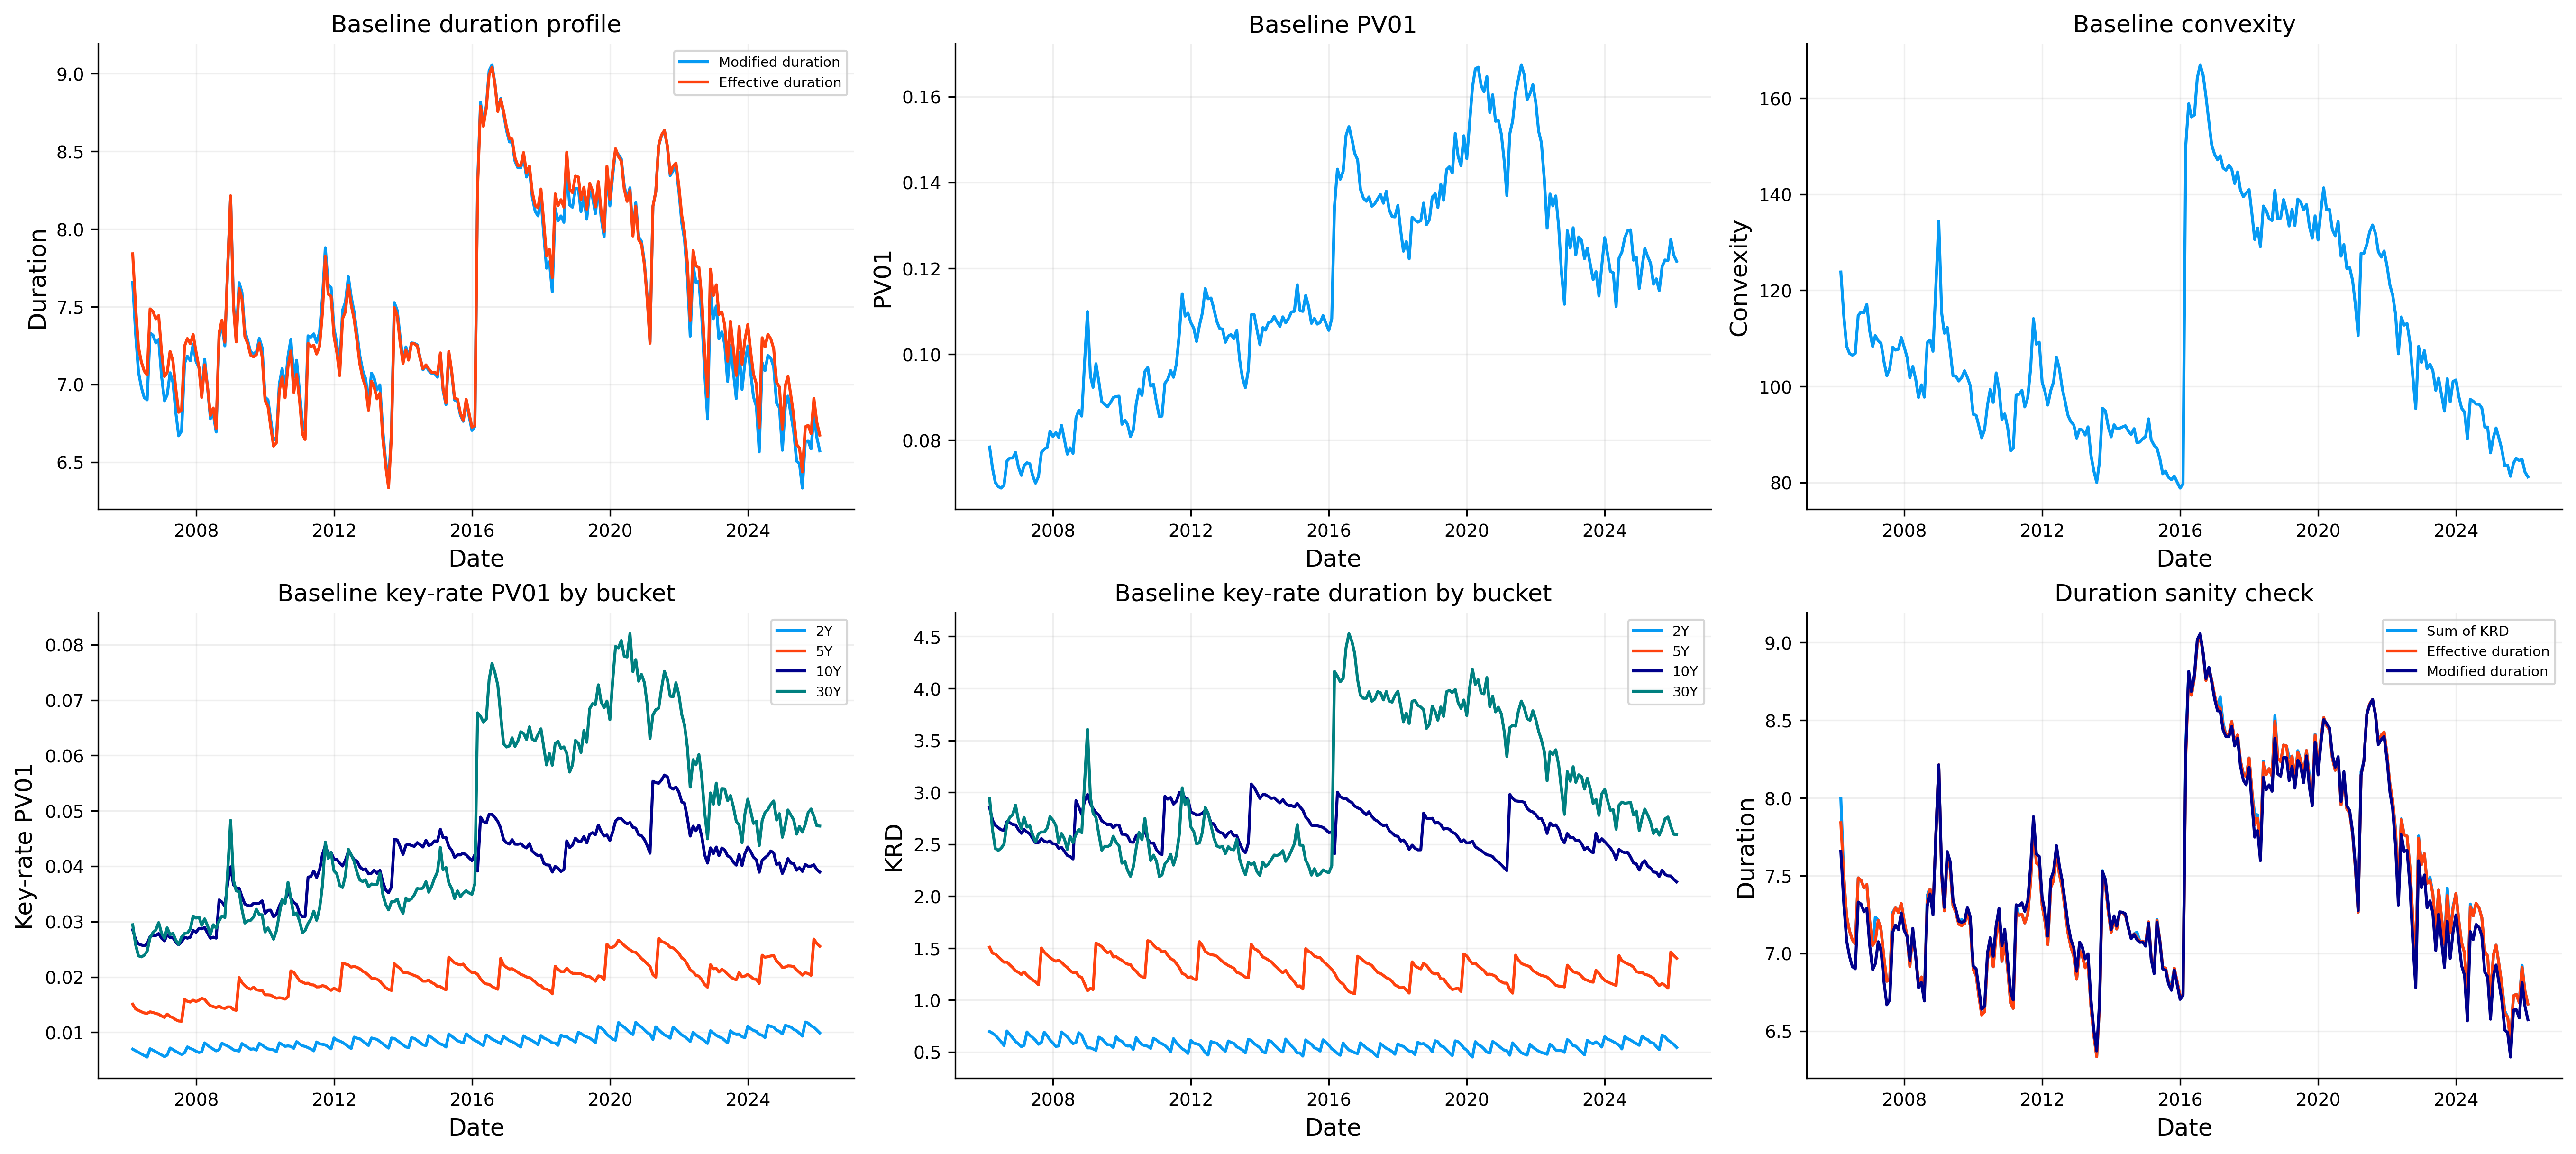

In [20]:
baseline_risk_df, baseline_krd_df = strategy_risk_timeseries(baseline_df, baseline_snapshots)

print("Baseline risk summary:")
display(baseline_risk_df[["pv01", "modified_duration", "effective_duration", "convexity"]].tail())

latest_krd = (
    baseline_krd_df[baseline_krd_df["date"] == baseline_krd_df["date"].max()]
    [["key", "krd", "key_rate_pv01"]]
    .sort_values("key"))

print("Baseline KRD on the last date:")
display(latest_krd)

baseline_risk_plot = gap_safe_frame(
    baseline_risk_df[["pv01", "modified_duration", "effective_duration", "convexity"]])

baseline_krd_pivot = (
    baseline_krd_df.pivot(index="date", columns="key", values="krd")
    .sort_index())
baseline_krd_pv01_pivot = (
    baseline_krd_df.pivot(index="date", columns="key", values="key_rate_pv01")
    .sort_index())

baseline_krd_plot = gap_safe_frame(baseline_krd_pivot)
baseline_krd_pv01_plot = gap_safe_frame(baseline_krd_pv01_pivot)

baseline_krd_sum = baseline_krd_pivot.sum(axis=1).reindex(baseline_risk_df.index)
baseline_krd_sum_plot = gap_safe_frame(
    pd.DataFrame({
        "krd_sum": baseline_krd_sum,
        "effective_duration": baseline_risk_df["effective_duration"],
        "modified_duration": baseline_risk_df["modified_duration"]}))

fig, axes = plt.subplots(2, 3, figsize=(18, 8), constrained_layout=True)

axes[0, 0].plot(baseline_risk_plot.index, baseline_risk_plot["modified_duration"], label="Modified duration")
axes[0, 0].plot(baseline_risk_plot.index, baseline_risk_plot["effective_duration"], label="Effective duration")
axes[0, 0].set_title("Baseline duration profile")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Duration")
axes[0, 0].legend()

axes[0, 1].plot(baseline_risk_plot.index, baseline_risk_plot["pv01"])
axes[0, 1].set_title("Baseline PV01")
axes[0, 1].set_xlabel("Date")
axes[0, 1].set_ylabel("PV01")

axes[0, 2].plot(baseline_risk_plot.index, baseline_risk_plot["convexity"])
axes[0, 2].set_title("Baseline convexity")
axes[0, 2].set_xlabel("Date")
axes[0, 2].set_ylabel("Convexity")

for key in baseline_krd_pv01_plot.columns:
    axes[1, 0].plot(baseline_krd_pv01_plot.index, baseline_krd_pv01_plot[key], label=f"{int(key)}Y")
axes[1, 0].set_title("Baseline key-rate PV01 by bucket")
axes[1, 0].set_xlabel("Date")
axes[1, 0].set_ylabel("Key-rate PV01")
axes[1, 0].legend()

for key in baseline_krd_plot.columns:
    axes[1, 1].plot(baseline_krd_plot.index, baseline_krd_plot[key], label=f"{int(key)}Y")
axes[1, 1].set_title("Baseline key-rate duration by bucket")
axes[1, 1].set_xlabel("Date")
axes[1, 1].set_ylabel("KRD")
axes[1, 1].legend()

axes[1, 2].plot(baseline_krd_sum_plot.index, baseline_krd_sum_plot["krd_sum"], label="Sum of KRD")
axes[1, 2].plot(baseline_krd_sum_plot.index, baseline_krd_sum_plot["effective_duration"], label="Effective duration")
axes[1, 2].plot(baseline_krd_sum_plot.index, baseline_krd_sum_plot["modified_duration"], label="Modified duration")
axes[1, 2].set_title("Duration sanity check")
axes[1, 2].set_xlabel("Date")
axes[1, 2].set_ylabel("Duration")
axes[1, 2].legend()

plt.show()

As we can see, the portfolio carries a modified duration around the mid six year area near the end. The last few observations show modified duration around **6.57 to 6.81**, effective duration around **6.67 to 6.91**, and convexity around **81 to 85**.

The PV01 tells us that a $1$ bp parallel increase in rates near the end of our window costs about **0.12 NAV units** for the baseline ladder. In percentage terms, the modified duration estimate says that a $100$ bp parallel rate shock would create approximately a **6.6%** first order loss.

The latest key-rate durations are:

| Key rate | KRD | Key-rate PV01 |
|---:|---:|---:|
| 2Y | 0.5430 | 0.00990 |
| 5Y | 1.4021 | 0.02555 |
| 10Y | 2.1368 | 0.03895 |
| 30Y | 2.5923 | 0.04725 |

The baseline ladder is not concentrated only at the short end. Even though the ladder includes short and intermediate maturities, a large share of the rate exposure sits in the **10Y and 30Y key rate weights**. This happens because long cash flows carry much larger duration per unit of market value. A small notional in a long bond can contribute a lot to total interest rate risk.

As we can see, the $30$Y key rate duration is the largest, followed by the $10$Y bucket. Together they explain most of the rate sensitivity. This is exactly why the baseline ladder suffered a meaningful drawdown in the rising rate times. Coupon income helps, but coupon income is not large enough to fully offset a rapid repricing of long duration cash flows.

This section also gives us a natural reason to test duration targeting. If the baseline strategy has duration around $6.6$ to $6.9$, and much of that exposure comes from the long end, then we may want to reduce the duration an stabilize it. We now see if a duration-targeted overlay can lower volatility and drawdown, and what return reduction we accept for that risk control.

duration_target_ladder: using contiguous block 2006-02-28 -> 2026-01-31 (240 dates)
Strategy comparison summary:


,annualized_return,annualized_vol,max_drawdown
baseline_ladder,0.030596,0.060663,-0.202618
duration_target_ladder,0.026734,0.040731,-0.135296


Duration-target strategy risk summary:


,pv01,modified_duration,effective_duration,convexity
date,,,,
2025-09-30,0.083507,4.900694,4.980669,48.421179
2025-10-31,0.083955,4.901447,4.981061,49.324957
2025-11-30,0.084502,4.903033,4.980832,45.880551
2025-12-31,0.084242,4.903146,4.981674,46.752495
2026-01-31,0.084225,4.898487,4.980011,47.586177


Recent duration-target trades:


,date,maturity,side,notional,price,units,cost,reason,strategy
1475,2025-12-31,2,sell,25.555513,1.013052,25.226272,2.555551e-03,rebalance,duration_target_ladder
1476,2025-12-31,5,sell,0.009737,0.996978,0.009767,9.737118e-07,rebalance,duration_target_ladder
1477,2025-12-31,10,buy,0.126700,1.047506,0.120954,1.267003e-05,rebalance,duration_target_ladder
1478,2025-12-31,30,buy,25.433438,0.732829,34.705849,2.543344e-03,rebalance,duration_target_ladder
1479,2025-12-31,30,sell,23.844204,0.732829,32.537220,2.384420e-03,duration_overlay,duration_target_ladder
1480,2025-12-31,2,buy,23.839436,1.013052,23.532304,2.383944e-03,duration_overlay,duration_target_ladder
1481,2026-01-31,2,sell,23.955481,1.014912,23.603497,2.395548e-03,rebalance,duration_target_ladder
1482,2026-01-31,5,buy,0.049595,0.995921,0.049799,4.959548e-06,rebalance,duration_target_ladder
1483,2026-01-31,10,buy,0.077153,1.045729,0.073779,7.715288e-06,rebalance,duration_target_ladder
1484,2026-01-31,30,buy,23.823942,0.733884,32.462806,2.382394e-03,rebalance,duration_target_ladder


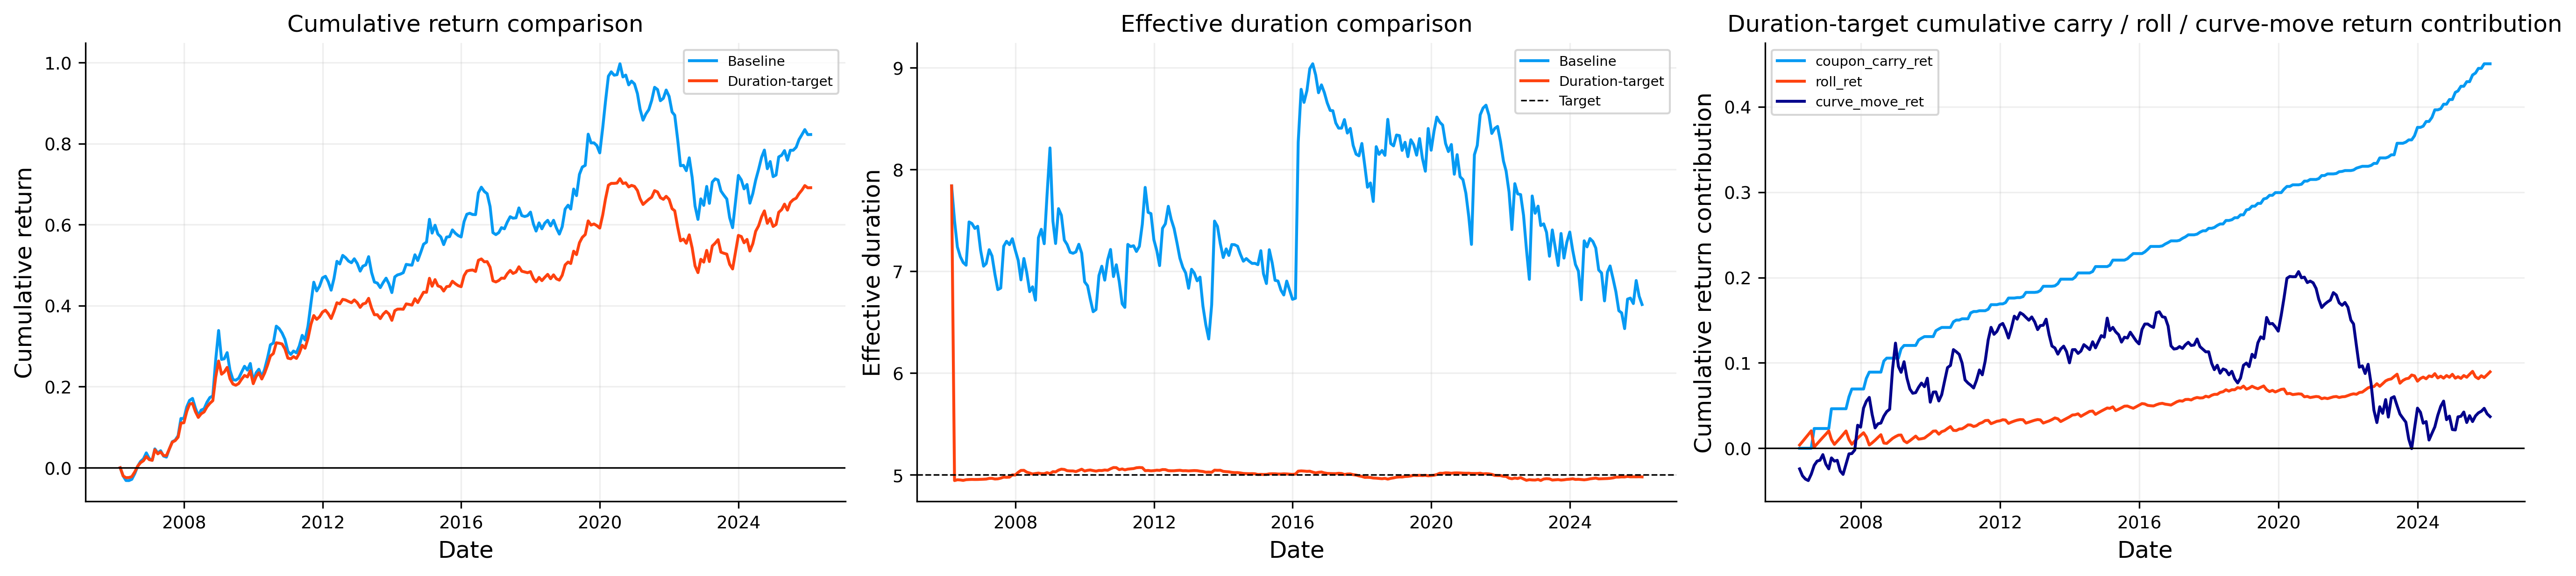

In [21]:
duration_df, duration_bucket_df, duration_trades_df, duration_carry_df, duration_snapshots = run_ladder_strategy(
    strategy_name="duration_target_ladder", target_weights=target_weights,
    duration_target=duration_target, duration_band=duration_band)

duration_risk_df, duration_krd_df = strategy_risk_timeseries(duration_df, duration_snapshots)

comparison_summary = pd.concat(
    [strategy_summary_table(baseline_df),
    strategy_summary_table(duration_df)],axis=0)

comparison_metrics = comparison_summary.drop(columns=["final_nav"], errors="ignore")

print("Strategy comparison summary:")
display(comparison_metrics)

print("Duration-target strategy risk summary:")
display(duration_risk_df[["pv01", "modified_duration", "effective_duration", "convexity"]].tail())

print("Recent duration-target trades:")
display(duration_trades_df.tail(12))

duration_risk_plot = gap_safe_frame(
    duration_risk_df[["pv01", "modified_duration", "effective_duration", "convexity"]])

duration_carry_cum_plot = gap_safe_frame(
    duration_carry_df[["coupon_carry_ret", "roll_ret", "curve_move_ret"]].fillna(0.0).cumsum())

baseline_cumret_compare = gap_safe_frame((1.0 + baseline_df["ret"].fillna(0.0)).cumprod() - 1.0)
duration_cumret_compare = gap_safe_frame((1.0 + duration_df["ret"].fillna(0.0)).cumprod() - 1.0)

fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)

axes[0].plot(baseline_cumret_compare.index, baseline_cumret_compare.values, label="Baseline")
axes[0].plot(duration_cumret_compare.index, duration_cumret_compare.values, label="Duration-target")
axes[0].axhline(0.0, color="black", linewidth=0.8)
axes[0].set_title("Cumulative return comparison")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Cumulative return")
axes[0].legend()

axes[1].plot(baseline_risk_plot.index, baseline_risk_plot["effective_duration"], label="Baseline")
axes[1].plot(duration_risk_plot.index, duration_risk_plot["effective_duration"], label="Duration-target")
axes[1].axhline(duration_target, color="black", linestyle="--", linewidth=0.8, label="Target")
axes[1].set_title("Effective duration comparison")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Effective duration")
axes[1].legend()

for col in duration_carry_cum_plot.columns:
    axes[2].plot(duration_carry_cum_plot.index, duration_carry_cum_plot[col], label=col)
axes[2].axhline(0.0, color="black", linewidth=0.8)
axes[2].set_title("Duration-target cumulative carry / roll / curve-move return contribution")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Cumulative return contribution")
axes[2].legend()

plt.show()

From both strategies, we can see an important trade-off:

| Strategy | Final NAV | Annualized return | Annualized volatility | Max drawdown |
|---|---:|---:|---:|---:|
| Baseline ladder | 182.2582 | 3.0596% | 6.0663% | -20.2618% |
| Duration-target ladder | 169.1267 | 2.6734% | 4.0731% | -13.5296% |

As we can see, the duration-targeted version gives up return: annualized return falls from about 3.06% to about 2.67%, and the final NAV is lower. But the risk reduction is substantial. Annualized volatility drops from about **6.07%** to about **4.07%**, and the max drawdown improves from about -20.26% to about -13.53%.

This is the expected fixed-income result. Reducing duration reduces the exposure to rate shocks, and the lower volatility confirms that the overlay is doing what it is designed to do. The cost is lower exposure to the parts of the curve that generated carry and long-end return during periods that could have more returns.

Near the end of the sample, the effective duration is almost exactly around **4.98**, while the modified duration is around **4.90**:

The baseline ladder drifts around the mid-six-year area, while the duration-targeted ladder remains tightly anchored around five years of effective duration. Convexity also falls from the baseline level around 80 to around 40. That reduction is natural because shortening duration reduces exposure to long cash flows, and long cash flows are the main source of convexity.

The conclusion is that duration targeting works as a **risk control extension**. It does not magically improve every metric. Instead, it gives the investor a different portfolio: lower return, lower volatility, lower drawdown, lower convexity, and a more controlled interest-rate exposure.

# Implementing the whole project on Japan data using quantfinlab

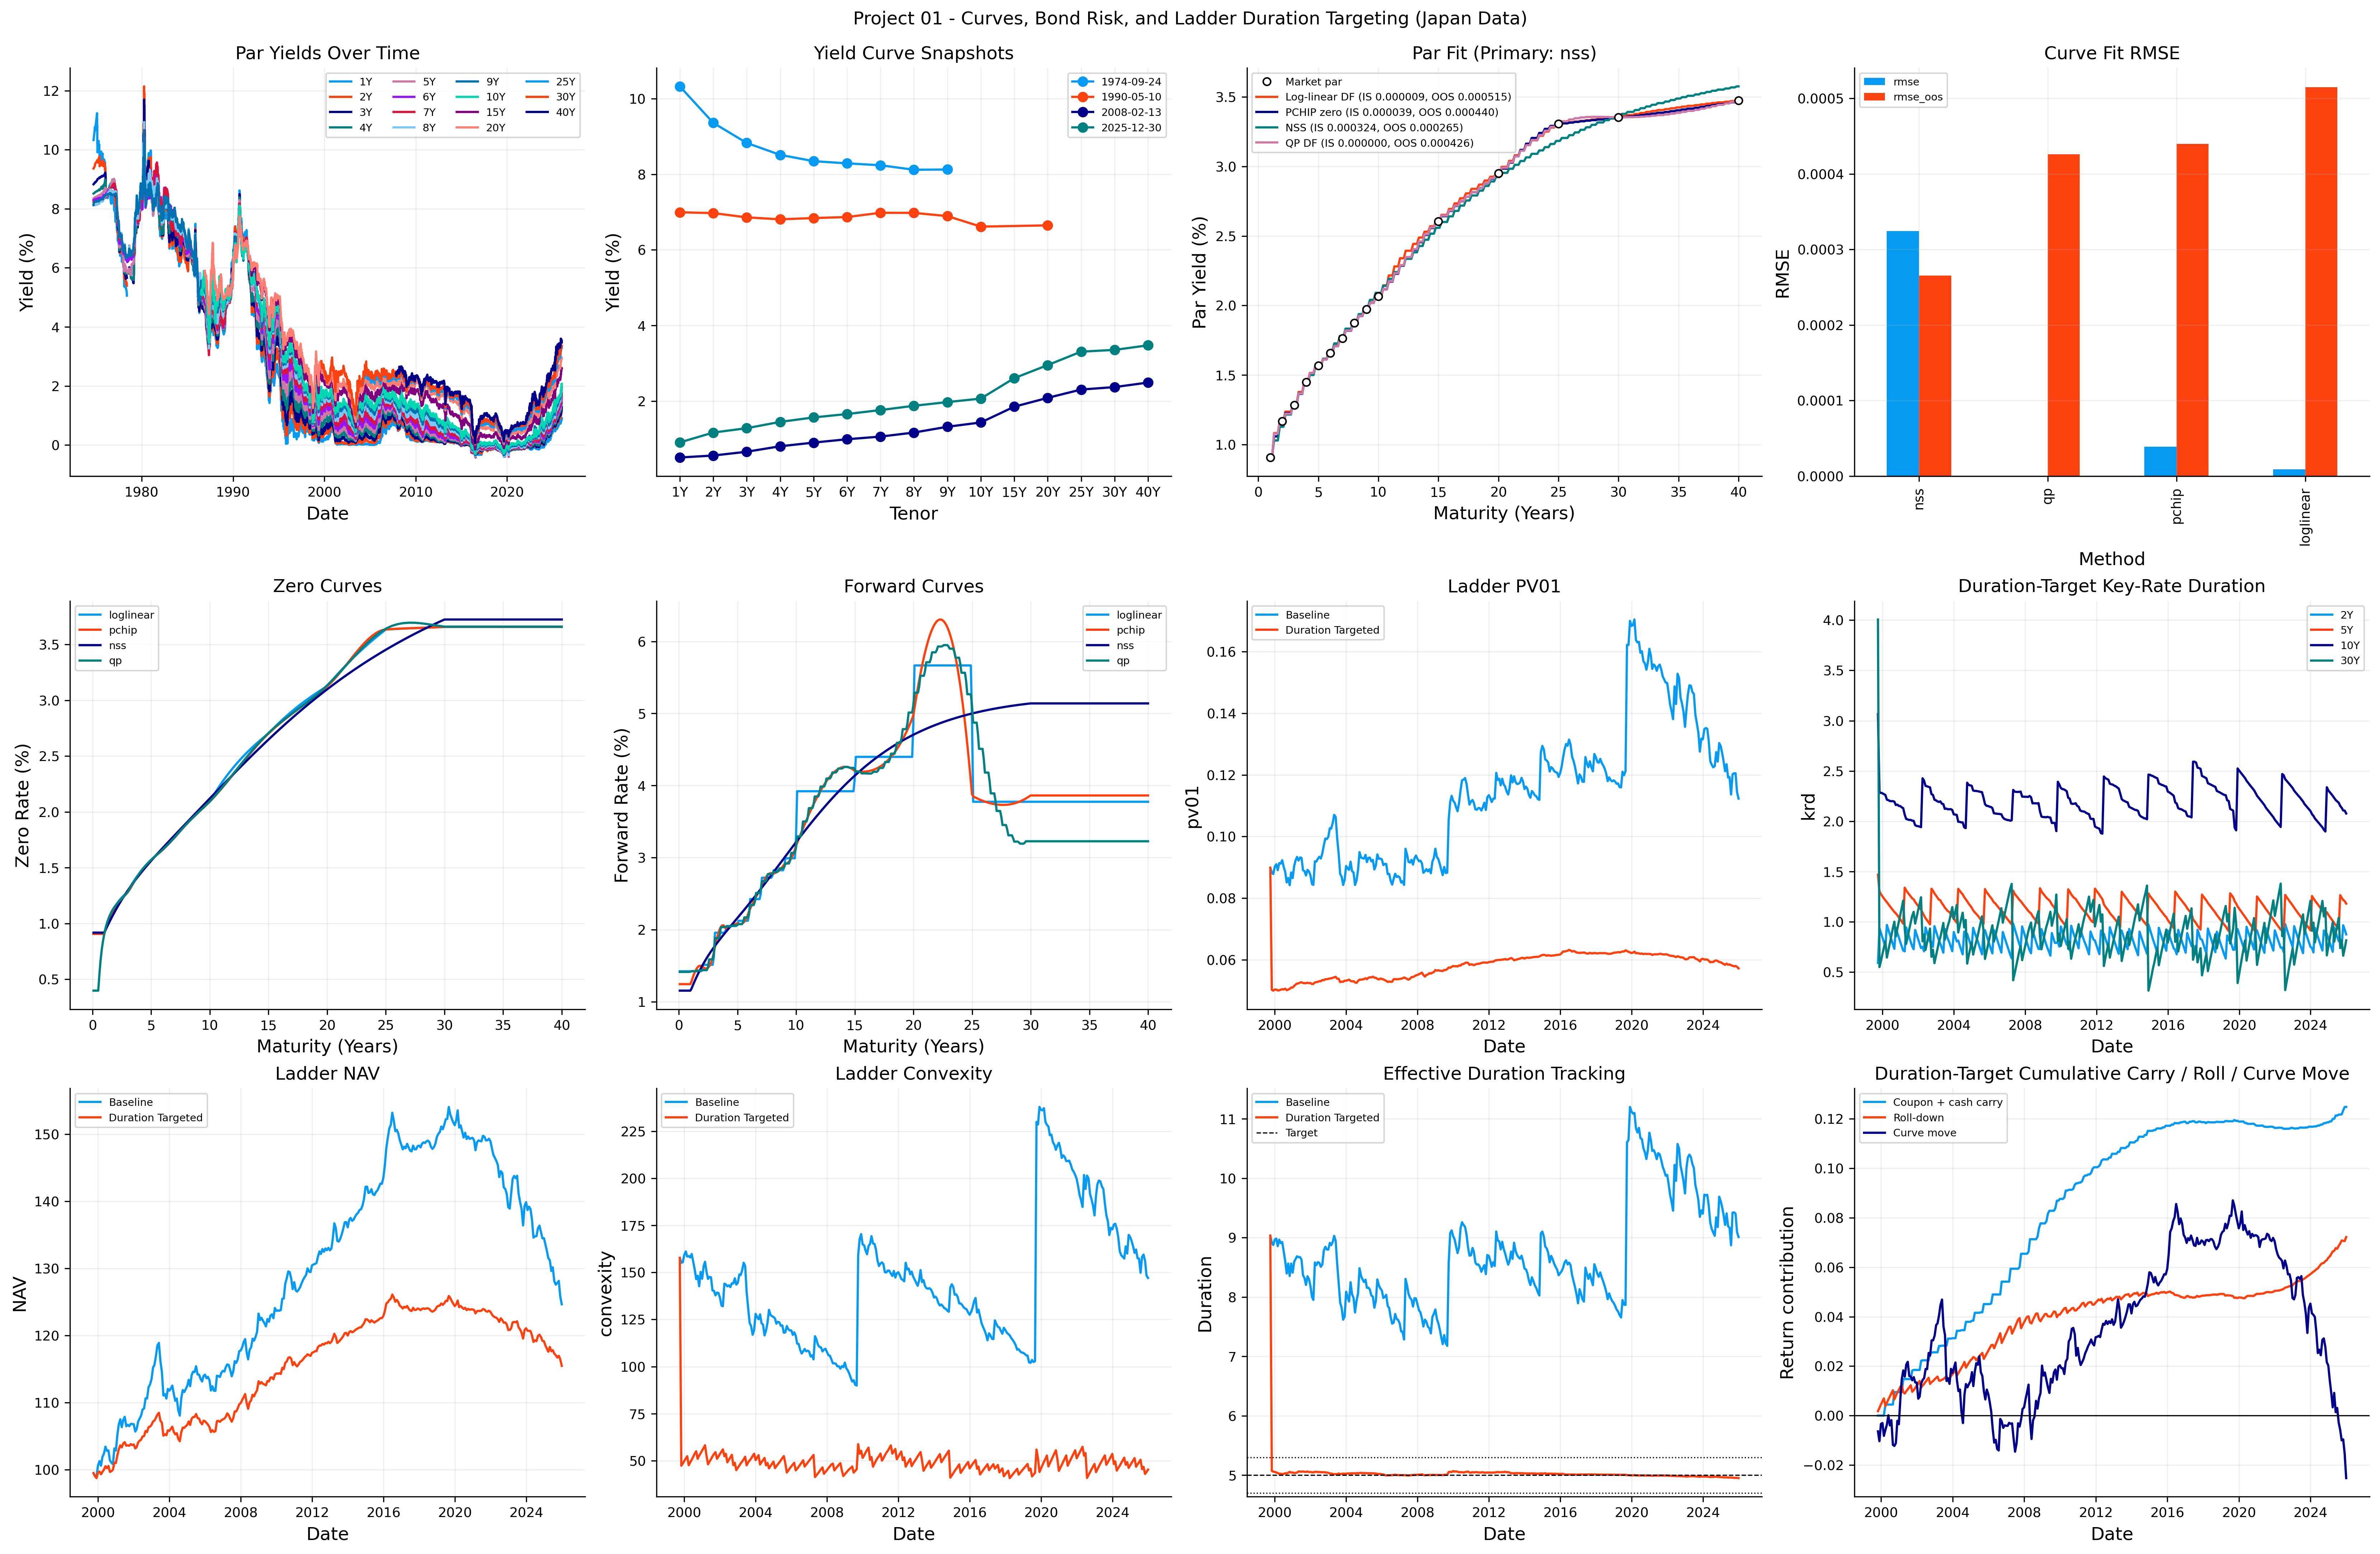

Asof date: 2025-12-30
Primary curve selected for ladder: nss (NSS)
Bond price/risk table:


,clean_price,pv01,convexity,krd_2Y,krd_5Y,krd_10Y,krd_30Y
method,,,,,,,
loglinear,1.000000,0.000907,87.530846,0.098387,0.421344,8.514938,0.0
pchip,1.000078,0.000907,87.524809,0.098400,0.421397,8.514987,0.0
nss,0.997714,0.000905,87.497439,0.098420,0.421132,8.491704,0.0
qp,1.000000,0.000907,87.522921,0.098397,0.421366,8.514131,0.0


RMSE ranking:


,name,rmse,rmse_oos,n_obs,n_obs_oos,n_dates,n_dates_oos,n_failed
method,,,,,,,,
nss,NSS,3.241647e-04,0.000265,1100,400,100,100,0
qp,QP DF,2.833055e-09,0.000426,1100,400,100,100,0
pchip,PCHIP zero,3.874855e-05,0.000440,1100,400,100,100,0
loglinear,Log-linear DF,8.669301e-06,0.000515,1100,400,100,100,0


Ladder comparison summary:


...

,key,krd,key_rate_pv01
1260,2,0.875942,0.010115
1261,5,1.181746,0.013646
1262,10,2.077895,0.023994
1263,30,0.816305,0.009426


Duration sanity check:


,krd_sum,effective_duration,modified_duration
date,,,
2025-08-31,4.964034,4.959127,4.926961
2025-09-30,4.956324,4.956324,4.921390
2025-10-31,4.955246,4.955246,4.921839
2025-11-30,4.969994,4.955872,4.920005
2025-12-31,4.951888,4.951888,4.910377


PV01 sanity check:


,key_rate_pv01_sum,pv01
date,,
2025-08-31,0.058108,0.058050
2025-09-30,0.057848,0.057848
2025-10-31,0.057965,0.057965
2025-11-30,0.057875,0.057711
2025-12-31,0.057181,0.057181


In [22]:
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from quantfinlab.fixed_income import (
    bootstrap, bond_pricing,
    discounting, duration_overlay,
    forwards, ladder, risk,
    smoothers, tenors)
from quantfinlab.backtest import fixed_income as fi_backtest
from quantfinlab.plotting import curves as curve_plots
from quantfinlab.plotting import fixed_income as fi_plots

warnings.filterwarnings("ignore")
path = Path("../data/japan_yield_curve_all.csv")

first_line = path.read_text(encoding="utf-8", errors="ignore").splitlines()[0].strip().lower()
if first_line.startswith("interest rate"):
    raw = pd.read_csv(path, skiprows=1, na_values=["-"], keep_default_na=True)
else:
    raw = pd.read_csv(path, na_values=["-"], keep_default_na=True)

raw = raw.rename(columns={c: str(c).strip() for c in raw.columns})


def normalize_tenor_name(c):
    s = str(c).strip().upper().replace(" ", "")
    s = s.replace("MONTHS", "M").replace("MONTH", "M").replace("MOS", "M").replace("MO", "M")
    s = s.replace("YEARS", "Y").replace("YEAR", "Y").replace("YRS", "Y").replace("YR", "Y")
    return s


lower_cols = [c.lower() for c in raw.columns]
date_col = raw.columns[lower_cols.index("date")] if "date" in lower_cols else raw.columns[0]
raw = raw.rename(columns={date_col: "date"})
raw["date"] = pd.to_datetime(raw["date"], errors="coerce")
raw = raw.dropna(subset=["date"]).sort_values("date").set_index("date")

raw = raw.rename(columns={c: normalize_tenor_name(c) for c in raw.columns})
tenor_cols = [c for c in raw.columns if re.fullmatch(r"\d+(M|Y)", str(c))]
tenor_cols = sorted(tenor_cols, key=tenors.tenor_to_years)

par = raw[tenor_cols].apply(pd.to_numeric, errors="coerce").dropna(how="all").sort_index()
if np.nanmedian(par.to_numpy(dtype=float)) > 1.0:
    par = par / 100.0
par = bootstrap.normalize_par_yields(par, tenor_cols=tenor_cols, assume_percent=False)
tenor_cols = [c for c in tenor_cols if c in par.columns]

methods = ["loglinear", "pchip", "nss", "qp"]
holdouts = ["2Y", "7Y", "20Y", "30Y"]
keys = [2, 5, 10, 30]
target_weights = {2: 0.25, 5: 0.25, 10: 0.25, 30: 0.25}
risk_bucket_bounds = {2: (0.0, 3.5), 5: (3.5, 7.5), 10: (7.5, 20.0), 30: (20.0, 30.0)}
freq = 2
short_end = "continuous"
duration_target = 5.0
duration_band = 0.30

asof = discounting.resolve_asof(par.index)
pillars = bootstrap.bootstrap_pillars(
    par.loc[asof],
    asof=asof,
    tenor_cols=tenor_cols,
    freq=freq,
    short_end=short_end)

curves = smoothers.fit_curves(pillars, methods=methods, freq=freq)

curve_t_max = max(30.0, float(pillars.T.max()))
plot_grid = np.linspace(max(1 / 12, float(pillars.T.min())), float(pillars.T.max()), 250)
par_fit_table = discounting.par_curve_table(curves, grid=plot_grid, freq=freq)
zero_table = discounting.zero_curve_table(curves, t_min=1 / 12, t_max=curve_t_max, points=400)
fwd_table = forwards.forward_curve_table(curves, t_min=1 / 12, t_max=curve_t_max, points=400)

rmse = bootstrap.rmse_backtest(
    par.tail(100), methods=methods, holdouts=holdouts,
    freq=freq, short_end=short_end, tenor_cols=tenor_cols)

primary_curve_method, primary_curve_name, rmse_rank = bootstrap.select_primary_curve(
    rmse, methods=methods, curves=curves)

example_bond, used_tenor = bond_pricing.bond_from_par_curve_row(
    par.loc[asof], maturity_years=10,
    tenor_cols=tenor_cols, freq=freq)

bond_tbl = risk.bond_price_and_risk(example_bond, curves, bump_bp=1.0, key_tenors=keys).reindex(methods)

primary_curve_lookup = ladder.make_curve_lookup(
    par, curve_method=primary_curve_method,
    tenor_cols=tenor_cols, freq=freq, short_end=short_end)

baseline_ladder = fi_backtest.run_bond_ladder_backtest(
    par_yields=par, strategy_name="baseline_ladder",
    curve_method=primary_curve_method, curve_lookup=primary_curve_lookup,
    buckets=keys, target_weights=target_weights, rebalance_band=0.05,
    trading_cost_bps=1.0, duration_target=None, freq=freq,
    short_end=short_end, tenor_cols=tenor_cols,
    risk_bucket_bounds=risk_bucket_bounds)

duration_ladder = fi_backtest.run_bond_ladder_backtest(
    par_yields=par, strategy_name="duration_target_ladder",
    curve_method=primary_curve_method,
    curve_lookup=primary_curve_lookup, buckets=keys,
    target_weights=target_weights, rebalance_band=0.05,
    trading_cost_bps=1.0, duration_target=duration_target,
    duration_band=duration_band,
    overlay_fn=duration_overlay.duration_switch_overlay,
    freq=freq, short_end=short_end, tenor_cols=tenor_cols,
    risk_bucket_bounds=risk_bucket_bounds)

baseline_strategy = baseline_ladder.diagnostics["strategy"]
duration_strategy = duration_ladder.diagnostics["strategy"]
baseline_risk = baseline_ladder.diagnostics["risk"]
duration_risk = duration_ladder.diagnostics["risk"]
baseline_krd = baseline_ladder.diagnostics["krd"]
duration_krd = duration_ladder.diagnostics["krd"]

comparison_summary = pd.concat(
    [ladder.ladder_performance_table(baseline_strategy),
    ladder.ladder_performance_table(duration_strategy)], axis=0)

duration_tracking = pd.DataFrame(
    {"Baseline": baseline_risk["effective_duration"],
    "Duration Targeted": duration_risk["effective_duration"]})

latest_krd = risk.latest_krd_table(duration_krd)
duration_sanity = risk.duration_sanity_table(duration_risk, duration_krd)
pv01_sanity = risk.pv01_sanity_table(duration_risk, duration_krd)

n = len(par.index)
sample_dates = [par.index[0], par.index[n // 3], par.index[(2 * n) // 3], par.index[-1]]
rmse_label_map = {
    m: f"{rmse_rank.loc[m, 'name']} (IS {rmse_rank.loc[m, 'rmse']:.6f}, OOS {rmse_rank.loc[m, 'rmse_oos']:.6f})"
    if m in rmse_rank.index
    else m
    for m in methods}

fig = plt.figure(figsize=(22, 14), constrained_layout=True)
gs = fig.add_gridspec(3, 4)

ax_all = fig.add_subplot(gs[0, 0])
curve_plots.plot_par_yields_history(ax_all, par, title="Par Yields Over Time")

ax_snap = fig.add_subplot(gs[0, 1])
curve_plots.plot_yield_curve_snapshots(
    ax_snap,
    par,
    tenor_cols=tenor_cols,
    sample_dates=sample_dates,
    title="Yield Curve Snapshots")

ax_par = fig.add_subplot(gs[0, 2])
curve_plots.draw_market_par_points(ax_par, pillars.T, pillars.par)
curve_plots.draw_curve_lines(ax_par, par_fit_table, scale=100.0, label_map=rmse_label_map)
curve_plots.style_axis(
    ax_par,
    title=f"Par Fit (Primary: {primary_curve_method})", xlabel="Maturity (Years)", ylabel="Par Yield (%)")

ax_rmse = fig.add_subplot(gs[0, 3])
curve_plots.plot_rmse_bars(ax_rmse, rmse_rank, title="Curve Fit RMSE")

ax_zero = fig.add_subplot(gs[1, 0])
curve_plots.plot_zero_curves(ax_zero, zero_table, title="Zero Curves")

ax_fwd = fig.add_subplot(gs[1, 1])
curve_plots.plot_forward_curves(ax_fwd, fwd_table, title="Forward Curves")

ax_pv01 = fig.add_subplot(gs[1, 2])
fi_plots.plot_risk_timeseries(
    ax_pv01,
    {"Baseline": baseline_risk, "Duration Targeted": duration_risk},
    metric="pv01", title="Ladder PV01")

ax_krd = fig.add_subplot(gs[1, 3])
fi_plots.plot_krd_lines(
    ax_krd, duration_krd, value="krd", keys=keys,
    title="Duration-Target Key-Rate Duration")

ax_nav = fig.add_subplot(gs[2, 0])
fi_plots.plot_ladder_nav(ax_nav,
    {"Baseline": baseline_ladder.nav, "Duration Targeted": duration_ladder.nav},
    title="Ladder NAV")

ax_convexity = fig.add_subplot(gs[2, 1])
fi_plots.plot_risk_timeseries(ax_convexity,
    {"Baseline": baseline_risk, "Duration Targeted": duration_risk},
    metric="convexity", title="Ladder Convexity")

ax_duration = fig.add_subplot(gs[2, 2])
fi_plots.plot_duration_tracking( ax_duration, duration_tracking,
    target=duration_target, band=duration_band,
    title="Effective Duration Tracking")

ax_carry = fig.add_subplot(gs[2, 3])
fi_plots.plot_carry_return_contributions( ax_carry,
    duration_ladder.diagnostics["carry"], cumulative=True,
    title="Duration-Target Cumulative Carry / Roll / Curve Move")

fig.suptitle("Project 01 - Curves, Bond Risk, and Ladder Duration Targeting (Japan Data)", y=1.02)
plt.show()


print(f"Asof date: {asof.date()}")
print(f"Primary curve selected for ladder: {primary_curve_method} ({primary_curve_name})")
print("Bond price/risk table:")
display(bond_tbl)
print("RMSE ranking:")
display(rmse_rank)
print("Ladder comparison summary:")
display(comparison_summary)
print("Latest duration-target ladder KRD:")
display(latest_krd)
print("Duration sanity check:")
display(duration_sanity.tail())
print("PV01 sanity check:")
display(pv01_sanity.tail())


The Japanese yield curve has a different behavior, policy history, and long-end structure.

The curve-selection output shows that the primary curve for the Japan ladder is **NSS**, not the same curve chosen in the U.S. case. The RMSE ranking is:

| Method | In-sample RMSE | Out-of-sample RMSE |
|---|---:|---:|
| NSS | 0.000324 | 0.000265 |
| QP | 0.000000003 | 0.000426 |
| PCHIP | 0.0000387 | 0.000440 |
| Log-linear | 0.00000867 | 0.000515 |

This is an important point. maybe more complexity and smoothness was not worth it for treasury, but for Japan interest rate, it does. The QP method has almost zero in-sample error, but its out-of-sample error is worse than NSS. That means it can interpolate today’s curve extremely well but didn't generalize to held-out instruments or maturities. NSS has a worse in-sample fit but the best out-of-sample behavior, so it is selected as the primary curve for the ladder.

For the sample bond, clean prices are close to par across methods, and PV01/convexity are very similar. The $10$Y key-rate exposure dominates because the bond being inspected is centered around a long/intermediate maturity. The NSS price is slightly below one, which reflects the smoother’s different fitted curve shape at the relevant cash-flow dates.

The Japan ladder summary is:

| Strategy | Final NAV | Annualized return | Annualized volatility | Max drawdown |
|---|---:|---:|---:|---:|
| Baseline ladder | 124.6572 | 0.8637% | 2.7709% | -19.0989% |
| Duration-target ladder | 115.4722 | 0.5701% | 1.4242% | -8.4307% |

As we can see, the Japan version produces a lower-return and lower-volatility portfolio than the US case. That is undersandable based on the long low rate period in Japan. If yields are low, the coupon cushion is also low, so curve repricing can still be painful.

The duration-targeted ladder again reduces risk strongly. Volatility falls from **2.77%** to **1.42%**, and max drawdown improves from about **-19.10%** to **-8.43%**. The cost is lower annualized return and lower final NAV. This is same as US result and the general conclusion can be that duration targeting is a consistent risk control mechanism across markets.

The latest Japan duration-targeted key-rate table shows:

| Key rate | KRD | Key-rate PV01 |
|---:|---:|---:|
| 2Y | 0.8759 | 0.01012 |
| 5Y | 1.1817 | 0.01365 |
| 10Y | 2.0779 | 0.02399 |
| 30Y | 0.8163 | 0.00943 |

This exposure is different from the US baseline ladder. The $10$Y bucket is the largest, but the $30$Y bucket is not the most in the same way. This makes sense because the duration-targeting overlay and the Japan bank bonds create a different maturity risk distribution.

The sum of key-rate PV01 values is close to the total PV01, and the sum of key-rate durations is close to effective duration which can approve estimations.